<a href="https://colab.research.google.com/github/nubganggsta/DW_lab_6730204893/blob/main/Jinrada489_3_Pandas_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC 663 402 Data Warehouse and Big Data Analytics
## แบบฝึกทบทวน pandas

**ผู้สอน:** อ.ดร.พิชญา วิรัชโชติเสถียร (Pitchaya Wiratchotisatian)
**ภาควิชาสถิติ คณะวิทยาศาสตร์ มหาวิทยาลัยขอนแก่น**

---

### วัตถุประสงค์

การบ้านชุดนี้มีวัตถุประสงค์เพื่อทบทวนความรู้ pandas ที่นักศึกษาเคยศึกษามาแล้ว ให้อยู่ในระดับที่พร้อมสำหรับการวิเคราะห์ข้อมูลขนาดใหญ่ในรายวิชานี้
เนื้อหาครอบคลุมตั้งแต่โครงสร้างข้อมูลพื้นฐาน การเลือกและกรองข้อมูล การสรุปข้อมูลด้วย `groupby` การรวมตารางหลายตาราง จนถึงการสร้างกราฟจาก DataFrame

### รูปแบบ

แต่ละหัวข้อประกอบด้วยสองส่วน

1. **ตัวอย่าง** เป็นเซลล์โค้ดที่รันได้ทันที มีไว้เพื่อทบทวนรูปแบบการเรียกใช้คำสั่ง นักศึกษาควรรันและสังเกตผลลัพธ์ก่อนทำโจทย์
2. **โจทย์** เป็นแบบฝึกหัดที่มีระดับความยากสูงกว่าตัวอย่าง ไม่มีเฉลย นักศึกษาต้องเขียนคำตอบเองในเซลล์ที่เตรียมไว้

### ข้อกำหนดในการทำและการส่ง

1. เขียนคำตอบในเซลล์ที่เตรียมไว้ใต้โจทย์แต่ละข้อ
2. โจทย์ที่ระบุคำว่า **อธิบาย** ต้องตอบเป็นข้อความ การส่งเฉพาะโค้ดจะไม่ได้คะแนนในส่วนนั้น
3. ห้ามกำหนดคำตอบเป็นค่าคงที่ ทุกตัวเลขที่รายงานต้องคำนวณจากข้อมูล
4. ให้เขียนโปรแกรมในรูปแบบ vectorized เป็นหลัก หากจำเป็นต้องใช้การวนซ้ำทีละแถว ให้ระบุเหตุผลกำกับ
5. ก่อนส่งให้เลือกคำสั่ง Restart & Run All และตรวจสอบว่าไฟล์ทำงานได้ตลอดทั้งไฟล์
6. ส่งไฟล์ในรูปแบบ `.ipynb` ด้วยลิ้งก์ใน GitHub ของตนเอง

### เกณฑ์การประเมิน

* ความเรียบร้อย ครบถ้วน และความสามารถในการรันซ้ำได้

---
## ส่วนที่ 0 import libraries และ เตรียมข้อมูล

ชุดข้อมูลที่ใช้ประกอบด้วย 3 ตาราง ได้แก่ ข้อมูลสภาพอากาศรายวัน ข้อมูลเมือง และข้อมูลภูมิภาค
ให้รันเซลล์ต่อไปนี้เพื่อโหลดข้อมูลก่อนเริ่มทำการบ้าน

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fonts-tlwg-purisa
  fonts-tlwg-purisa-ttf fonts-tlwg-sawasdee fonts-tlwg-sawasdee-ttf
  fonts-tlwg-typewriter fonts-tlwg-typewriter-ttf fonts-tlwg-typist
  fonts-tlwg-typist-ttf fonts-tlwg-typo fonts-tlwg-typo-ttf fonts-tlwg-umpush
  fonts-tlwg-umpush-ttf fonts-tlwg-waree fonts-tlwg-waree-ttf
The following NEW packages will be installed:
  fonts-thai-tlwg fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fo

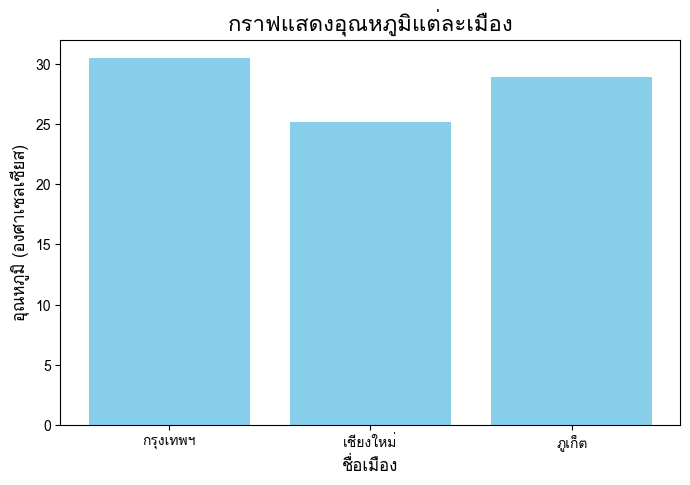

In [1]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

# 5. สร้างข้อมูลจำลองและแสดงผล
data = {
    'เมือง': ['กรุงเทพฯ', 'เชียงใหม่', 'ภูเก็ต'],
    'อุณหภูมิ': [30.5, 25.2, 28.9]
}
df_thai = pd.DataFrame(data)

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

plt.figure(figsize=(8, 5))
plt.bar(df_thai['เมือง'], df_thai['อุณหภูมิ'], color='skyblue')
plt.title('กราฟแสดงอุณหภูมิแต่ละเมือง', fontsize=16)
plt.xlabel('ชื่อเมือง', fontsize=12)
plt.ylabel('อุณหภูมิ (องศาเซลเซียส)', fontsize=12)
plt.show()

In [2]:
import pandas as pd
import numpy as np

BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
region_info = pd.read_csv(BASE + "region_info.csv")

print("weather:", df.shape, " city_info:", city_info.shape, " region_info:", region_info.shape)
df.head()

weather: (2075, 10)  city_info: (23, 5)  region_info: (6, 3)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
3,469,2025-01-19,Mumbai,India,Asia,31.0,73.4,8.0,11.8,1000.1
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1


---
## ข้อ 1 การเปรียบเทียบคำสั่งที่มีลักษณะใกล้เคียงกัน

**คำสั่ง:** ให้นักศึกษารันเซลล์โค้ดทั้ง 6 เซลล์ต่อไปนี้ สังเกตผลลัพธ์ที่ได้ แล้วอธิบายกับตนเองให้เข้าใจความแตกต่างของคำสั่งในแต่ละเซลล์ พร้อมระบุว่าในทางปฏิบัติควรเลือกใช้คำสั่งใดในสถานการณ์ใด

การอธิบายควรครอบคลุมทั้ง **ชนิดของผลลัพธ์** **รูปร่างของผลลัพธ์** และ **ความหมายของค่าที่ได้**

In [3]:
# เซลล์ 1.1
s = pd.Series([10, 20, 30], index=["a", "b", "c"])
print(s["a"])
print(s.iloc[0])
print(s[["a", "c"]])

10
10
a    10
c    30
dtype: int64


# การวิเคราะห์และเปรียบเทียบพฤติกรรมของคำสั่ง (เซลล์ 1.1)

---

## 1. การประมวลผลและผลลัพธ์จากโค้ด

```python
import pandas as pd

s = pd.Series([10, 20, 30], index=["a", "b", "c"])

print(s["a"])  # บรรทัดที่ 1
print(s.iloc[0])  # บรรทัดที่ 2
print(s[["a", "c"]])  # บรรทัดที่ 3
```

### 📊 ตารางเปรียบเทียบเชิงวิเคราะห์

| บรรทัดที่ | รูปแบบคำสั่ง (Syntax) | ชนิดของผลลัพธ์ (Data Type) | รูปร่างของผลลัพธ์ (Output Shape) | ความหมายของค่าที่ได้ (Semantic Meaning) |
| :---: | :--- | :--- | :--- | :--- |
| **1** | `s['a']` | **Scalar** (`int64`) | Single Value (0 มิติ) | ค่าสเกลาร์ ณ Index Label `'a'` (ได้ค่าเท่ากับ `10`) |
| **2** | `s.iloc[0]` | **Scalar** (`int64`) | Single Value (0 มิติ) | ค่าสเกลาร์ ณ ลำดับตำแหน่งทางกายภาพที่ `0` (ได้ค่าเท่ากับ `10`) |
| **3** | `s[['a', 'c']]` | **`pd.Series`** | `(2,)` (1 มิติ, 2 แถว) | ชุดข้อมูลย่อย (Subset) ที่คัดเฉพาะ Index Label `'a'` และ `'c'` โดยคงโครงสร้าง Series เดิมไว้ |

### 💡 การเลือกใช้ในทางปฏิบัติ

* **`s['a']` (หรือ `s.loc['a']`):** ใช้เมื่อต้องการดึง **ค่าเดี่ยว** ที่ทราบชื่อ Index Label แน่นอนเพื่อนำไปคำนวณต่อ *(แนะนำใช้ `.loc['a']` เพื่อป้องกันความสับสนกรณี Index เป็นตัวเลข)*
* **`s.iloc[0]`:** **Best Practice** เมื่อต้องการดึงข้อมูลเดี่ยวตาม **ตำแหน่งกายภาพที่แน่นอน** เช่น ข้อมูลแรกสุด (`.iloc[0]`) หรือสุดท้าย (`.iloc[-1]`) โดยไม่ขึ้นกับชื่อ Label
* **`s[['a', 'c']]`:** ใช้เมื่อต้องการ **สกัดชุดข้อมูลย่อย (Subset Extraction)** หลายๆ ค่าออกมารวมเป็น Series ใหม่เพื่อวิเคราะห์เฉพาะกลุ่ม

In [4]:
# เซลล์ 1.2
print(type(df["city"]), df["city"].shape)
print(type(df[["city"]]), df[["city"]].shape)

<class 'pandas.core.series.Series'> (2075,)
<class 'pandas.core.frame.DataFrame'> (2075, 1)


# การอธิบายและเปรียบเทียบคำสั่ง Pandas (เซลล์ 1.2)

---

## 1. การประมวลผลและผลลัพธ์จากเซลล์ 1.2

สมมติให้ `df` เป็น DataFrame ตัวอย่างที่มี 6 แถว และมีคอลัมน์ `'city'`:

```python
import pandas as pd

# โค้ดต้นฉบับ
print(type(df["city"]), df["city"].shape)  # บรรทัดที่ 1
print(type(df[["city"]]), df[["city"]].shape)  # บรรทัดที่ 2
```
### 📊 ตารางเปรียบเทียบเชิงวิเคราะห์

| บรรทัดที่ | รูปแบบคำสั่ง (Syntax) | ชนิดของผลลัพธ์ (Data Type) | รูปร่างของผลลัพธ์ (Output Shape) | ความหมายของค่าที่ได้ (Semantic Meaning) |
| :---: | :--- | :--- | :--- | :--- |
| **1** | `df['city']` | **`pd.Series`** | `(N,)` (1 มิติ, N แถว) | เวกเตอร์ข้อมูล 1 มิติ ดึงเฉพาะค่าในคอลัมน์ `'city'` ออกมาโดยถอดโครงสร้างตารางออก |
| **2** | `df[['city']]` | **`pd.DataFrame`** | `(N, 1)` (2 มิติ, N แถว 1 คอลัมน์) | โครงสร้างตาราง 2 มิติ ดึงคอลัมน์ `'city'` โดยยังคงสภาพความเป็น DataFrame ย่อยไว้ |

### 💡 การเลือกใช้ในทางปฏิบัติ

* **`df['city']` (Single Bracket):** ใช้เมื่อต้องการนำคอลัมน์ไปประมวลผลต่อในฐานะ **1D Array / Series** เช่น การเรียกดึงฟังก์ชันสตริง `.str.upper()`, การนับความถี่ `.value_counts()`, หรือใช้เป็นตัวแปรคำนวณคณิตศาสตร์
* **`df[['city']]` (Double Brackets):** **Best Practice** เมื่อต้องการเตรียมข้อมูลไป **Concat/Merge** กับ DataFrame อื่น หรือป้อนเข้าเป็น Feature Matrix ($X$) ในโมเดล Machine Learning ที่บังคับโครงสร้าง 2D

In [5]:
# เซลล์ 1.3
print(df.loc[0:3].shape)
print(df.iloc[0:3].shape)

(4, 10)
(3, 10)


# การอธิบายและเปรียบเทียบคำสั่ง Pandas (เซลล์ 1.3)

---

## 1. การประมวลผลและผลลัพธ์จากเซลล์ 1.3

สมมติให้ `df` เป็น DataFrame ตัวอย่างที่มี 6 แถว และมี 3 คอลัมน์ (`temperature_c`, `rainfall_mm`, `city`) โดยใช้ Default Integer Index (`0, 1, 2, 3, 4, 5`):

```python
import pandas as pd

# โค้ดต้นฉบับ
print(df.loc[0:3].shape)  # บรรทัดที่ 1
print(df.iloc[0:3].shape)  # บรรทัดที่ 2
```
### 📊 ตารางเปรียบเทียบเชิงวิเคราะห์

| บรรทัดที่ | รูปแบบคำสั่ง (Syntax) | ชนิดของผลลัพธ์ (Data Type) | รูปร่างของผลลัพธ์ (Output Shape) | ความหมายของค่าที่ได้ (Semantic Meaning) |
| :---: | :--- | :--- | :--- | :--- |
| **1** | `df.loc[0:3]` | **`pd.DataFrame`** | `(4, C)` (2 มิติ, 4 แถว) | **รวมขอบบน (Inclusive):** ดึงข้อมูลตั้งแต่แถวที่มี Label `0` ถึง Label `3` (ได้แก่ Index Label 0, 1, 2, 3) |
| **2** | `df.iloc[0:3]` | **`pd.DataFrame`** | `(3, C)` (2 มิติ, 3 แถว) | **ไม่รวมขอบบน (Exclusive):** ดึงข้อมูลตั้งแต่ตำแหน่งกายภาพที่ `0` ถึงก่อนตำแหน่งที่ `3` (ได้แก่ Position 0, 1, 2) |

### 💡 การเลือกใช้ในทางปฏิบัติ

* **`df.loc[start:stop]`:** ใช้เมื่อ Slicing ตาม **Index Label ที่แน่นอน** เช่น การตัดช่วงตามวันที่ (`df.loc['2023-01-01':'2023-01-31']`) ซึ่งต้องการให้นับรวมวันสุดท้ายของช่วงด้วยเสมอ
* **`df.iloc[start:stop]`:** **Best Practice** สำหรับการตัดแบ่งข้อมูลตาม **จำนวนลำดับแถว** เช่น การเลือก $N$ แถวแรก (`df.iloc[0:N]`) หรือการทำ Train/Test Split ในงานวิทยาการข้อมูล

In [6]:
# เซลล์ 1.4
print(df.groupby("city")["temperature_c"].count().head(3))
print(df.groupby("city").size().head(3))

city
Auckland    90
Bangkok     91
Beijing     89
Name: temperature_c, dtype: int64
city
Auckland    90
Bangkok     91
Beijing     90
dtype: int64


# การอธิบายและเปรียบเทียบคำสั่ง Pandas (เซลล์ 1.4)

---

## 1. การประมวลผลและผลลัพธ์จากเซลล์ 1.4

สมมติให้ `df` เป็น DataFrame ตัวอย่างที่มีการจัดกลุ่มตามคอลัมน์ `'city'` และมีบางแถวในคอลัมน์ `'temperature_c'` เป็นค่าสูญหาย (`NaN` / `None`):

```python
import numpy as np
import pandas as pd

# โค้ดต้นฉบับ
print(df.groupby("city")["temperature_c"].count().head(3))  # บรรทัดที่ 1
print(df.groupby("city").size().head(3))  # บรรทัดที่ 2
```
### 📊 ตารางเปรียบเทียบเชิงวิเคราะห์

| บรรทัดที่ | รูปแบบคำสั่ง (Syntax) | ชนิดของผลลัพธ์ (Data Type) | รูปร่างของผลลัพธ์ (Output Shape) | ความหมายของค่าที่ได้ (Semantic Meaning) |
| :---: | :--- | :--- | :--- | :--- |
| **1** | `df.groupby('city')['temperature_c'].count()` | **`pd.Series`** | `(K,)` (1 มิติ, K กลุ่ม) | **นับเฉพาะค่าที่ไม่เป็นค่าว่าง (Non-null Count):** จำนวนข้อมูลที่มีจริงในแต่ละเมือง ไม่นับรวม `NaN` |
| **2** | `df.groupby('city').size()` | **`pd.Series`** | `(K,)` (1 มิติ, K กลุ่ม) | **นับจำนวนแถวทั้งหมด (Total Row Size):** ขนาดของกลุ่มหรือรายการทั้งหมดในแต่ละเมือง นับรวม `NaN` ทุกแถว |

### 💡 การเลือกใช้ในทางปฏิบัติ

* **`.count()`:** ใช้เมื่อต้องการตรวจสอบ **ความสมบูรณ์ของข้อมูล (Data Completeness)** ในคอลัมน์นั้นๆ เพื่อดูว่ามีข้อมูลที่บันทึกสำเร็จจริงกี่รายการ
* **`.size()`:** **Best Practice** เมื่อต้องการนับ **ความถี่หรือปริมาณประชากรรายกลุ่ม (Frequency Distribution)** เพราะประมวลผลได้รวดเร็วกว่า และสะท้อนจำนวนแถวที่แท้จริงของกลุ่มเสมอ

In [7]:
# เซลล์ 1.5
print(df.groupby("city")["temperature_c"].mean().head(3))
print(df.groupby("city")[["temperature_c"]].mean().head(3))

city
Auckland    17.804444
Bangkok     32.453846
Beijing     15.598876
Name: temperature_c, dtype: float64
          temperature_c
city                   
Auckland      17.804444
Bangkok       32.453846
Beijing       15.598876


# การอธิบายและเปรียบเทียบคำสั่ง Pandas (เซลล์ 1.5)

---

## 1. การประมวลผลและผลลัพธ์จากเซลล์ 1.5

สมมติให้ `df` เป็น DataFrame ตัวอย่างที่มีการจัดกลุ่มตามคอลัมน์ `'city'` และมีคอลัมน์ตัวเลข `'temperature_c'`:

```python
import pandas as pd

# โค้ดต้นฉบับ
print(df.groupby("city")["temperature_c"].mean().head(3))  # บรรทัดที่ 1
print(df.groupby("city")[["temperature_c"]].mean().head(3))  # บรรทัดที่ 2
```
### 📊 ตารางเปรียบเทียบเชิงวิเคราะห์

| บรรทัดที่ | รูปแบบคำสั่ง (Syntax) | ชนิดของผลลัพธ์ (Data Type) | รูปร่างของผลลัพธ์ (Output Shape) | ความหมายของค่าที่ได้ (Semantic Meaning) |
| :---: | :--- | :--- | :--- | :--- |
| **1** | `df.groupby('city')['temperature_c'].mean()` | **`pd.Series`** | `(K,)` (1 มิติ, K กลุ่ม) | **เวกเตอร์ค่าเฉลี่ย 1 มิติ:** ค่าเฉลี่ยอุณหภูมิแยกรายเมือง โดยมีชื่อเมืองเป็น Index และไม่มีหัวตารางด้านบน |
| **2** | `df.groupby('city')[['temperature_c']].mean()` | **`pd.DataFrame`** | `(K, 1)` (2 มิติ, K กลุ่ม 1 คอลัมน์) | **ตารางสรุปค่าเฉลี่ย 2 มิติ:** ค่าเฉลี่ยอุณหภูมิแยกรายเมือง ในรูปแบบตาราง 1 คอลัมน์ โดยยังคงหัวตาราง `'temperature_c'` ไว้ |

### 💡 การเลือกใช้ในทางปฏิบัติ

* **Single Bracket `['col']` (Series Output):** เหมาะสำหรับนำผลลัพธ์ไป **`.map()` หรือ `.transform()`** ส่งค่าสถิติกลุ่มกลับเข้า DataFrame หลัก หรือนำไป Plot กราฟอย่างง่าย
* **Double Brackets `[['col']]` (DataFrame Output):** **Best Practice** สำหรับการจัดทำ **รายงานสรุปผล (Summary Report Table)** แดชบอร์ด หรือนำไป `.merge()` กับ DataFrame อื่นต่อ

In [8]:
# เซลล์ 1.6
a = pd.Series([1, 2, 3], index=["x", "y", "z"])
b = pd.Series([10, 20, 30], index=["z", "y", "x"])
print(a + b)
print(a.to_numpy() + b.to_numpy())

x    31
y    22
z    13
dtype: int64
[11 22 33]


# การอธิบายและเปรียบเทียบคำสั่ง Pandas (เซลล์ 1.6)

---

## 1. การประมวลผลและผลลัพธ์จากเซลล์ 1.6

```python
import pandas as pd

# โค้ดต้นฉบับ
a = pd.Series([1, 2, 3], index=["x", "y", "z"])
b = pd.Series([10, 20, 30], index=["z", "y", "x"])

print(a + b)  # บรรทัดที่ 1
print(a.to_numpy() + b.to_numpy())  # บรรทัดที่ 2
```
### 📊 ตารางเปรียบเทียบเชิงวิเคราะห์

| บรรทัดที่ | รูปแบบคำสั่ง (Syntax) | ชนิดของผลลัพธ์ (Data Type) | รูปร่างของผลลัพธ์ (Output Shape) | ความหมายของค่าที่ได้ (Semantic Meaning) |
| :---: | :--- | :--- | :--- | :--- |
| **1** | `a + b` | **`pd.Series`** | `(3,)` (1 มิติ, 3 แถว) | **บวกตาม Index Label (Label Alignment):** จับคู่และนำค่าที่มี Index Label เดียวกันมาบวกกัน ไม่ว่าจะอยู่อินเด็กซ์ตำแหน่งใด<br>• `x`: $1 + 30 = 31$<br>• `y`: $2 + 20 = 22$<br>• `z`: $3 + 10 = 13$ |
| **2** | `a.to_numpy() + b.to_numpy()` | **`np.ndarray`** | `(3,)` (1 มิติ, 3 สมาชิก) | **บวกตามตำแหน่งกายภาพ (Positional Addition):** แปลงเป็น NumPy Array แล้วบวกค่าตามลำดับตำแหน่งทางกายภาพ (Pos 0, 1, 2) โดยไม่สนใจ Label<br>• Pos 0: $1 + 10 = 11$<br>• Pos 1: $2 + 20 = 22$<br>• Pos 2: $3 + 30 = 33$ |

### 💡 การเลือกใช้ในทางปฏิบัติ

* **`a + b` (Pandas Automatic Alignment):** **Best Practice** สำหรับการคำนวณใน Pandas ช่วยป้องกันข้อผิดพลาดจากการสลับลำดับแถวของข้อมูลที่มาจากคนละแหล่ง (หาก Label ไม่ตรงกัน ผลลัพธ์จะเป็น `NaN` เพื่อแจ้งเตือน)
* **`a.to_numpy() + b.to_numpy()`:** ใช้เมื่อ **ตั้งใจบวกข้อมูลตามลำดับบรรทัด** โดยแน่ใจว่าข้อมูลผ่านการ Sort เรียงลำดับมาตรงกันแล้ว และต้องการเพิ่มความเร็วในการคำนวณระดับ Low-level Matrix Algebra

---
## ข้อ 2 Series และ DataFrame

### ตัวอย่าง

In [9]:
# การสร้าง DataFrame จากโครงสร้างข้อมูลสองรูปแบบ
d1 = pd.DataFrame({"city": ["Bangkok", "Tokyo"], "temp": [30.5, 16.2]})
d2 = pd.DataFrame([{"city": "Bangkok", "temp": 30.5}, {"city": "Tokyo", "temp": 16.2}])
print(d1.equals(d2))

# การเข้าถึงองค์ประกอบของ DataFrame
print(df.columns.tolist())
print(df.index[:5].tolist())
print(df["temperature_c"].nlargest(3).tolist())

True
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa']
[0, 1, 2, 3, 4]
[999.0, 999.0, 999.0]


### โจทย์ 2.1
สร้าง Series ชื่อ `rain_by_city` ซึ่งเก็บปริมาณฝนรวมของแต่ละเมือง โดยกำหนดให้ index เป็นชื่อเมือง จากนั้นตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง
3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง

In [13]:
# คำตอบข้อ 2.1
import pandas as pd

# สร้าง Series rain_by_city เก็บปริมาณฝนรวมของแต่ละเมือง โดยใช้ชื่อเมืองเป็น index
rain_by_city = df.groupby("city")["rainfall_mm"].sum()

# 1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
top_3_rain = rain_by_city.nlargest(3)
print("1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก:")
print(top_3_rain)

# 2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง
rain_share = (rain_by_city / rain_by_city.sum() * 100).round(2)
print("\n2. สัดส่วนปริมาณฝนของแต่ละเมือง (%):")
print(rain_share)

# คำนวณค่าเฉลี่ยและคัดกรองเมืองที่สูงกว่าค่าเฉลี่ย
avg_rain = rain_by_city.mean()
cities_above_avg = rain_by_city[rain_by_city > avg_rain]

# แบบที่ 1: แสดงผลแบบกระชับ (f-string พร้อมใส่หน่วยและค่าเฉลี่ย)
print(f"\n3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ย ({avg_rain:,.2f} มม.): {len(cities_above_avg)} จาก {len(rain_by_city)} เมือง")

# แบบที่ 2: แสดงผลแบบละเอียด (แสดงจำนวน และรายชื่อเมืองพร้อมปริมาณฝน)
print(f"   - ปริมาณฝนเฉลี่ยทุกเมือง : {avg_rain:,.2f} มม.")
print(f"   - จำนวนเมืองที่สูงกว่าค่าเฉลี่ย: {len(cities_above_avg)} เมือง")
print("   - รายชื่อเมืองและปริมาณฝน :")
for city, rain in cities_above_avg.items():
    print(f"     • {city:<15} : {rain:,.2f} มม.")


1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก:
city
Singapore    870.4
Bangkok      685.6
Lagos        652.8
Name: rainfall_mm, dtype: float64

2. สัดส่วนปริมาณฝนของแต่ละเมือง (%):
city
Auckland         4.22
Bangkok          8.21
Beijing          3.00
Berlin           3.21
Buenos Aires     3.65
Cairo            1.47
Cape Town        2.87
Chiang Mai       5.22
Lagos            7.82
Lima             2.16
London           3.27
Los Angeles      2.03
Mexico City      3.66
Moscow           2.96
Mumbai           5.84
Nairobi          4.74
New York         3.78
Paris            3.99
Sao Paulo        5.07
Singapore       10.43
Sydney           3.97
Tokyo            4.61
Toronto          3.81
Name: rainfall_mm, dtype: float64

3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ย (362.97 มม.): 8 จาก 23 เมือง
   - ปริมาณฝนเฉลี่ยทุกเมือง : 362.97 มม.
   - จำนวนเมืองที่สูงกว่าค่าเฉลี่ย: 8 เมือง
   - รายชื่อเมืองและปริมาณฝน :
     • Bangkok         : 685.60 มม.
     • Chiang Mai      : 435.60 มม.
     • Lagos 

### โจทย์ 2.2
สร้าง DataFrame ชื่อ `city_profile` ที่มีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์
`city`, `country`, `region`, `n_records`, `avg_temp`, `total_rain`
โดยกำหนดให้ใช้ `groupby`

In [17]:
# คำตอบข้อ 2.2
import pandas as pd

city_profile = (
    df.groupby(["city", "country", "region"], as_index=False).agg(
        n_records=("record_id", "count"),
        avg_temp=("temperature_c", "mean"),
        total_rain=("rainfall_mm", "sum"),
    )
)

city_profile.head(10)

,city,country,region,n_records,avg_temp,total_rain
0,Auckland,NEW ZEALAND,Oceania,1,19.800000,3.5
1,Auckland,New Zealand,Oceania,89,17.782022,348.4
2,Bangkok,Thailand,Asia,91,32.453846,685.6
3,Beijing,China,Asia,90,15.598876,250.1
4,Berlin,GERMANY,Europe,1,14.700000,0.0
5,Berlin,Germany,Europe,89,12.356818,268.4
6,Buenos Aires,ARGENTINA,South America,1,22.200000,9.3
7,Buenos Aires,Argentina,South America,89,19.137500,295.8
8,Cairo,Egypt,Africa,91,26.089888,123.0
9,Cape Town,South Africa,Africa,90,30.162921,239.3


---
## ข้อ 3 การนำเข้าข้อมูลด้วย `read_csv()`

### ตัวอย่าง

In [18]:
# พารามิเตอร์ที่ใช้บ่อย ได้แก่ usecols, nrows, parse_dates, dtype, na_values
preview = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "date", "temperature_c"],
    parse_dates=["date"],
    nrows=5,
)
print(preview.dtypes)
preview

date             datetime64[ns]
city                     object
temperature_c           float64
dtype: object


,date,city,temperature_c
0,2025-03-24,New York,15.7
1,2025-02-09,Tokyo,18.3
2,2025-02-01,Los Angeles,20.6
3,2025-01-19,Mumbai,31.0
4,2025-02-03,Cape Town,19.1


In [19]:
# การอ่านข้อมูลทีละก้อนด้วย chunksize ซึ่งคืนค่าเป็น iterator
total_rows = 0
for chunk in pd.read_csv(BASE + "world_weather_sample.csv", chunksize=500):
    total_rows += len(chunk)
print("จำนวนแถวรวม:", total_rows)

จำนวนแถวรวม: 2075


### โจทย์ 3.1
เขียนคำสั่ง `pd.read_csv()` เพียงคำสั่งเดียวที่ดำเนินการทุกข้อต่อไปนี้ให้เสร็จสิ้นตั้งแต่ขั้นตอนการนำเข้า

1. อ่านเฉพาะคอลัมน์ `date`, `city`, `region`, `temperature_c`, `humidity_pct`, `rainfall_mm`
2. แปลงคอลัมน์ `date` เป็นชนิด datetime
3. กำหนดให้ค่า `999` และ `-999` ถูกอ่านเป็นค่าว่าง
4. กำหนดชนิดข้อมูลของ `city` และ `region` เป็น `category`
5. กำหนดให้ `city` เป็น index

ให้ตรวจสอบผลด้วย `.dtypes` และ `.info()`

In [22]:
# คำตอบข้อ 3.1
import pandas as pd

# อ่านข้อมูลด้วย pd.read_csv() เพียงคำสั่งเดียวตามเงื่อนไขข้อ 1-5
df = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=[
        "date",
        "city",
        "region",
        "temperature_c",
        "humidity_pct",
        "rainfall_mm",
    ],  # 1. เลือกอ่านเฉพาะคอลัมน์ที่กำหนด
    parse_dates=["date"],  # 2. แปลง date เป็น datetime
    na_values=[999, -999],  # 3. กำหนดค่า 999 และ -999 ให้เป็น NaN (ค่าว่าง)
    dtype={
        "city": "category",
        "region": "category",
    },  # 4. กำหนดชนิดข้อมูลของ city และ region เป็น category
    index_col="city",  # 5. กำหนดให้ city เป็น index
)

# ตรวจสอบผลลัพธ์ด้วย .dtypes และ .info()
print(" Data Types ")
print(df.dtypes)

print("\n Dataframe Info ")
df.info()

 Data Types 
date             datetime64[ns]
region                 category
temperature_c           float64
humidity_pct            float64
rainfall_mm             float64
dtype: object

 Dataframe Info 
<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 2075 entries, New York to Paris
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2075 non-null   datetime64[ns]
 1   region         2075 non-null   category      
 2   temperature_c  2052 non-null   float64       
 3   humidity_pct   1993 non-null   float64       
 4   rainfall_mm    2013 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(3)
memory usage: 69.8 KB


### โจทย์ 3.2
เปรียบเทียบปริมาณหน่วยความจำที่ใช้ระหว่างตารางที่นำเข้าตามปกติกับตารางจากโจทย์ 3.1 ด้วย `.memory_usage(deep=True)`
รายงานผลเป็นร้อยละที่ลดลง และ **อธิบาย** ว่าคอลัมน์ใดมีผลต่อการลดลงมากที่สุด เพราะเหตุใด

In [23]:
# คำตอบข้อ 3.2
import pandas as pd

# 1. นำเข้าข้อมูลแบบปกติ (Default Import)
df_normal = pd.read_csv(BASE + "world_weather_sample.csv")

# 2. นำเข้าข้อมูลแบบปรับแต่งประสิทธิภาพ (Optimized Import จากโจทย์ 3.1)
df_opt = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=[
        "date",
        "city",
        "region",
        "temperature_c",
        "humidity_pct",
        "rainfall_mm",
    ],
    parse_dates=["date"],
    na_values=[999, -999],
    dtype={"city": "category", "region": "category"},
    index_col="city",
)

# คำนวณปริมาณหน่วยความจำรวม (Bytes) โดยใช้ deep=True
mem_normal_total = df_normal.memory_usage(deep=True).sum()
mem_opt_total = df_opt.memory_usage(deep=True).sum()

# คำนวณร้อยละที่ลดลง
reduction_pct = ((mem_normal_total - mem_opt_total) / mem_normal_total) * 100

# =========================================================
# การแสดงผลรายงานเปรียบเทียบหน่วยความจำ
# =========================================================
print("=" * 65)
print(f"{'รายงานการเปรียบเทียบการใช้หน่วยความจำ (Memory Usage)':^65}")
print("=" * 65)
print(
    f" • ตารางแบบปกติ (Normal Import)    : {mem_normal_total / 1024:>8.2f} KB ({mem_normal_total:>8,} Bytes)"
)
print(
    f" • ตารางแบบปรับแต่ง (Optimized)    : {mem_opt_total / 1024:>8.2f} KB ({mem_opt_total:>8,} Bytes)"
)
print("-" * 65)
print(
    f"  หน่วยความจำลดลงทั้งหมด          : {reduction_pct:>8.2f} %"
)
print("=" * 65)

# เปรียบเทียบหน่วยความจำแยกตามคอลัมน์
comp_df = pd.DataFrame(
    {
        "Normal (Bytes)": df_normal.memory_usage(deep=True),
        "Optimized (Bytes)": df_opt.memory_usage(deep=True),
    }
).fillna(0)

comp_df["Diff (Bytes)"] = comp_df["Normal (Bytes)"] - comp_df["Optimized (Bytes)"]
comp_df["% Saved"] = (
    (comp_df["Diff (Bytes)"] / comp_df["Normal (Bytes)"]) * 100
).fillna(0)

print("\n ตารางเปรียบเทียบการใช้หน่วยความจำรายคอลัมน์:")
print("-" * 65)
print(comp_df.to_string())
print("-" * 65)

      รายงานการเปรียบเทียบการใช้หน่วยความจำ (Memory Usage)       
 • ตารางแบบปกติ (Normal Import)    :   558.25 KB ( 571,645 Bytes)
 • ตารางแบบปรับแต่ง (Optimized)    :    71.21 KB (  72,917 Bytes)
-----------------------------------------------------------------
  หน่วยความจำลดลงทั้งหมด          :    87.24 %

 ตารางเปรียบเทียบการใช้หน่วยความจำรายคอลัมน์:
-----------------------------------------------------------------
                Normal (Bytes)  Optimized (Bytes)  Diff (Bytes)      % Saved
Index                      132             3927.0       -3795.0 -2875.000000
city                    116920                0.0      116920.0   100.000000
country                 114937                0.0      114937.0   100.000000
date                    122425            16600.0      105825.0    86.440678
humidity_pct             16600            16600.0           0.0     0.000000
pressure_hpa             16600                0.0       16600.0   100.000000
rainfall_mm              16600       

### โจทย์ 3.3
ใช้การอ่านข้อมูลแบบ `chunksize` เพื่อคำนวณค่าต่อไปนี้ โดยห้ามโหลดข้อมูลทั้งไฟล์เข้าหน่วยความจำพร้อมกัน และห้ามใช้ `pd.concat`

1. อุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์
2. อุณหภูมิเฉลี่ยรายเมือง

**อธิบาย:** เหตุใดการนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งจึงให้ผลไม่ถูกต้อง และควรสะสมค่าใดแทนจึงจะได้ผลที่ถูกต้อง

In [31]:
# คำตอบข้อ 3.3
import pandas as pd

# ตัวแปรสำหรับสะสมค่า Minimum และ Maximum ของทั้งไฟล์
global_max_temp = float("-inf")
global_min_temp = float("inf")

# ตัวแปร Series สำหรับสะสมผลรวม (Sum) และจำนวนข้อมูล (Count) แยกรายเมือง
city_sum = pd.Series(dtype=float)
city_count = pd.Series(dtype=int)

# อ่านข้อมูลทีละก้อน (Chunksize) โดยระบุ na_values เพื่อกรองค่าผิดปกติออกตั้งแต่ต้น
for chunk in pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "temperature_c"],
    na_values=[999, -999],
    chunksize=500,
):

    # 1. หาค่าอุณหภูมิสูงสุดและต่ำสุดของ Chunk ปัจจุบัน และอัปเดตค่าสะสมทั้งไฟล์
    chunk_valid_temp = chunk["temperature_c"].dropna()
    if not chunk_valid_temp.empty:
        global_max_temp = max(global_max_temp, chunk_valid_temp.max())
        global_min_temp = min(global_min_temp, chunk_valid_temp.min())

    # 2. สะสมผลรวม (Sum) และจำนวนข้อมูล (Count) แยกรายเมืองในแต่ละ Chunk
    grouped = chunk.groupby("city", observed=False)["temperature_c"]
    chunk_sum = grouped.sum()
    chunk_count = grouped.count()

    # นำผลรวมและจำนวนข้อมูลไปบวกรวมกับค่าสะสมก่อนหน้าด้วย .add(fill_value=0)
    city_sum = city_sum.add(chunk_sum, fill_value=0)
    city_count = city_count.add(chunk_count, fill_value=0)

# คำนวณค่าเฉลี่ยอุณหภูมิรายเมืองที่ถูกต้อง
city_avg_temp = (city_sum / city_count).round(2)



print(f"{'ผลการคำนวณข้อมูลแบบ Chunksize':^60}")

print(f"\n 1. อุณหภูมิสูงสุดทั้งไฟล์ : {global_max_temp:.2f} °C")
print(f"   อุณหภูมิต่ำสุดทั้งไฟล์ : {global_min_temp:.2f} °C")

print("\n 2. อุณหภูมิเฉลี่ยรายเมือง (5 เมืองแรก):")
print(city_avg_temp.head().to_string())


               ผลการคำนวณข้อมูลแบบ Chunksize                

 1. อุณหภูมิสูงสุดทั้งไฟล์ : 39.20 °C
   อุณหภูมิต่ำสุดทั้งไฟล์ : -88.00 °C

 2. อุณหภูมิเฉลี่ยรายเมือง (5 เมืองแรก):
city
Auckland        17.80
Bangkok         32.45
Beijing         15.60
Berlin          12.38
Buenos Aires    19.17


---
## ข้อ 4 การสำรวจข้อมูลและการตรวจสอบคุณภาพข้อมูล

### ตัวอย่าง

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   record_id       2075 non-null   int64  
 1   date            2075 non-null   object 
 2   city            2075 non-null   object 
 3   country         2075 non-null   object 
 4   region          2075 non-null   object 
 5   temperature_c   2055 non-null   float64
 6   humidity_pct    1993 non-null   float64
 7   rainfall_mm     2013 non-null   float64
 8   wind_speed_kmh  2034 non-null   float64
 9   pressure_hpa    2043 non-null   float64
dtypes: float64(5), int64(1), object(4)
memory usage: 162.2+ KB


In [ ]:
print(df.describe().round(2))
print(df.describe(include="all").iloc[:4])

       record_id  temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  \
count    2075.00        2055.00       1993.00      2013.00         2034.00   
mean     1035.15          21.84         66.82         4.15           14.78   
std       598.02          38.22         13.09         3.85            5.88   
min         1.00         -88.00         21.50         0.00           -5.00   
25%       517.50          15.40         58.60         0.30           10.80   
50%      1035.00          20.00         67.10         3.50           15.00   
75%      1553.50          25.70         75.50         6.60           18.70   
max      2070.00         999.00        150.00        17.60           33.70   

       pressure_hpa  
count       2043.00  
mean        1013.13  
std            5.86  
min          993.90  
25%         1009.30  
50%         1013.10  
75%         1017.20  
max         1030.60  
        record_id        date        city   country region  temperature_c  \
count      2075.0     

In [ ]:
print(df.isna().sum())
print("จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์:", df.isna().any(axis=1).sum())
print("จำนวนแถวที่ซ้ำกันทุกคอลัมน์:", df.duplicated().sum())

record_id          0
date               0
city               0
country            0
region             0
temperature_c     20
humidity_pct      82
rainfall_mm       62
wind_speed_kmh    41
pressure_hpa      32
dtype: int64
จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์: 229
จำนวนแถวที่ซ้ำกันทุกคอลัมน์: 5


### โจทย์ 4.1
สร้าง DataFrame ชื่อ `summary` ที่มีหนึ่งแถวต่อหนึ่งคอลัมน์ของ `df` ประกอบด้วย
`dtype`, `n_missing`, `pct_missing`, `n_unique`, `example_value`
โดยห้ามใช้การวนซ้ำทีละคอลัมน์ และให้เรียงลำดับจากคอลัมน์ที่มีค่าว่างมากที่สุด

In [32]:
# คำตอบข้อ 4.1
import pandas as pd

# สร้าง DataFrame summary โดยไม่ใช้การวนซ้ำ (Vectorized Operations)
summary = (
    pd.DataFrame(
        {
            "dtype": df.dtypes,
            "n_missing": df.isna().sum(),
            "pct_missing": (df.isna().mean() * 100).round(2),
            "n_unique": df.nunique(),
            "example_value": df.bfill().iloc[0],  # ดึงค่าตัวอย่างที่ไม่ใช่ค่าว่างตัวแรกของแต่ละคอลัมน์
        }
    )
    .sort_values(by="n_missing", ascending=False)
)

# แสดงผลลัพธ์
summary

,dtype,n_missing,pct_missing,n_unique,example_value
humidity_pct,float64,82,3.95,544,72.6
rainfall_mm,float64,62,2.99,164,6.3
temperature_c,float64,23,1.11,330,15.7
date,datetime64[ns],0,0.00,90,2025-03-24 00:00:00
region,category,0,0.00,6,North America


### โจทย์ 4.2
ผลลัพธ์ของ `.describe()` แสดงค่าสูงสุดของ `temperature_c` และ `humidity_pct` ที่เป็นไปไม่ได้ในทางกายภาพ ให้เขียนโปรแกรมหาค่าต่อไปนี้

1. จำนวนแถวที่ `temperature_c` อยู่นอกช่วง -60 ถึง 60
2. จำนวนแถวที่ `humidity_pct` อยู่นอกช่วง 0 ถึง 100
3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ โดยระวังการนับซ้ำ

In [34]:
# คำตอบข้อ 4.2
import pandas as pd

# 1. เงื่อนไขอุณหภูมินอกช่วง -60 ถึง 60 °C
temp_out_of_range = (df["temperature_c"] < -60) | (df["temperature_c"] > 60)
count_temp_invalid = temp_out_of_range.sum()

# 2. เงื่อนไขความชื้นสัมพัทธ์นอกช่วง 0 ถึง 100 %
hum_out_of_range = (df["humidity_pct"] < 0) | (df["humidity_pct"] > 100)
count_hum_invalid = hum_out_of_range.sum()

# 3. แถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ (ใช้ Bitwise OR '|' เพื่อป้องกันการนับซ้ำ)
any_out_of_range = temp_out_of_range | hum_out_of_range
count_any_invalid = any_out_of_range.sum()

# =========================================================
# การแสดงผลรายงานการตรวจวัดค่าผิดปกติ (Anomaly Report)
# =========================================================

print(f"{'รายงานตรวจสอบค่าผิดปกติทางกายภาพ (Out-of-Range Report)':^65}")

print(
    f"1. แถวที่ temperature_c อยู่นอกช่วง [-60, 60] °C : {count_temp_invalid:>5} แถว"
)
print(
    f"2. แถวที่ humidity_pct อยู่นอกช่วง [0, 100] %     : {count_hum_invalid:>5} แถว"
)

print(
    f"3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์   : {count_any_invalid:>5} แถว"
)


     รายงานตรวจสอบค่าผิดปกติทางกายภาพ (Out-of-Range Report)      
1. แถวที่ temperature_c อยู่นอกช่วง [-60, 60] °C :     2 แถว
2. แถวที่ humidity_pct อยู่นอกช่วง [0, 100] %     :     3 แถว
3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์   :     5 แถว


### โจทย์ 4.3
คอลัมน์ `country` มีจำนวนค่าไม่ซ้ำมากกว่าจำนวนประเทศที่มีอยู่จริง เนื่องจากการใช้ตัวพิมพ์ไม่สม่ำเสมอ

1. แสดงว่าค่าใดบ้างที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกจากกัน
2. ทดลองใช้ `df["country"].str.title()` แล้ว **อธิบาย** ว่าวิธีนี้ทำให้ข้อมูลของประเทศใดเสียหาย และเพราะเหตุใด
3. เสนอและเขียนวิธี normalize ที่ถูกต้อง โดยต้องรองรับกรณีที่มีช่องว่างหัวท้ายด้วย

> **การตรวจสอบคำตอบ:** จำนวนประเทศที่ถูกต้องคือ 21 ประเทศ จากทั้งหมด 23 เมือง

In [41]:
import pandas as pd

# โหลดข้อมูลกลับเข้ามาเต็มเพื่อให้อ่านคอลัมน์ country ได้
df = pd.read_csv(BASE + "world_weather_sample.csv")

# 1. สำรวจค่าคอลัมน์ country ดั้งเดิม
raw_countries = df["country"].unique()

# 2. ทดลองใช้ .str.title()
title_countries = df["country"].str.title().unique()

# 3. ทำ Normalize ที่ถูกต้อง (ตัดช่องว่าง + เปลี่ยน Title Case + คืนค่าตัวอักษรย่อ)
df["country_clean"] = df["country"].str.strip().str.title()
df["country_clean"] = df["country_clean"].replace({"Usa": "USA", "Uk": "UK"})

# =========================================================
# แสดงผลลัพธ์เพื่อตอบโจทย์ 4.3
# =========================================================

print(" 1. รายชื่อประเทศดั้งเดิมทั้งหมดในข้อมูล (พบความซ้ำซ้อน):")

print(raw_countries)


print(" \n 2. รายชื่อประเทศหลังทดลองใช้ .str.title():")

print(f"จำนวนที่ได้: {len(title_countries)} รายการ")
print(title_countries)


print(" \n 3. รายชื่อประเทศหลัง Normalize ที่ถูกต้อง (21 ประเทศ):")

print(
    f"จำนวนประเทศทั้งหมด: {df['country_clean'].nunique()} ประเทศ (จาก 23 เมือง)"
)

print(sorted(df["country_clean"].unique()))


 1. รายชื่อประเทศดั้งเดิมทั้งหมดในข้อมูล (พบความซ้ำซ้อน):
['USA' 'Japan' 'India' 'South Africa' 'New Zealand' 'Argentina' 'Mexico'
 'Russia' 'Kenya' 'China' 'Australia' 'Nigeria' 'Peru' 'France'
 'Singapore' 'Egypt' 'UK' 'Thailand' 'Germany' 'Brazil' 'Canada' 'GERMANY'
 'CANADA' 'SINGAPORE' 'NEW ZEALAND' 'ARGENTINA' 'JAPAN' 'KENYA']
 
 2. รายชื่อประเทศหลังทดลองใช้ .str.title():
จำนวนที่ได้: 21 รายการ
['Usa' 'Japan' 'India' 'South Africa' 'New Zealand' 'Argentina' 'Mexico'
 'Russia' 'Kenya' 'China' 'Australia' 'Nigeria' 'Peru' 'France'
 'Singapore' 'Egypt' 'Uk' 'Thailand' 'Germany' 'Brazil' 'Canada']
 
 3. รายชื่อประเทศหลัง Normalize ที่ถูกต้อง (21 ประเทศ):
จำนวนประเทศทั้งหมด: 21 ประเทศ (จาก 23 เมือง)
['Argentina', 'Australia', 'Brazil', 'Canada', 'China', 'Egypt', 'France', 'Germany', 'India', 'Japan', 'Kenya', 'Mexico', 'New Zealand', 'Nigeria', 'Peru', 'Russia', 'Singapore', 'South Africa', 'Thailand', 'UK', 'USA']


---
## ข้อ 5 การเลือกข้อมูลด้วย `loc` และ `iloc`

### ตัวอย่าง

In [ ]:
# iloc อ้างอิงตามตำแหน่ง ส่วน loc อ้างอิงตาม label และรวมค่าปลายช่วง
print(df.iloc[0:3, 0:3].shape, df.loc[0:3, ["city", "region"]].shape)

# loc ใช้ร่วมกับเงื่อนไขและเลือกคอลัมน์ได้ในคำสั่งเดียว
print(df.loc[df["temperature_c"] > 35, ["city", "date", "temperature_c"]].head(3))

(3, 3) (4, 2)
          city        date  temperature_c
78   Cape Town  2025-02-10          999.0
161    Bangkok  2025-02-14           38.6
325     Mumbai  2025-03-31           35.6


In [ ]:
# การกำหนด index หลายระดับ และการเลือกข้อมูลจาก index หลายระดับ
multi = df.set_index(["region", "city"]).sort_index()
print(multi.loc["Asia"].shape)
print(multi.loc[("Asia", "Tokyo"), ["date", "temperature_c"]].head(3))

(542, 8)
                    date  temperature_c
region city                            
Asia   Tokyo  2025-02-09           18.3
       Tokyo  2025-03-21           19.7
       Tokyo  2025-03-23           17.7


### โจทย์ 5.1
ใช้ `.iloc[]` เท่านั้น โดยห้ามอ้างอิงชื่อคอลัมน์ เพื่อดึงข้อมูลต่อไปนี้

1. แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย
2. ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป
3. ค่าเดี่ยวที่อยู่ในแถวกึ่งกลางตารางและคอลัมน์สุดท้าย โดยต้องคำนวณตำแหน่งกึ่งกลางจากจำนวนแถว

In [43]:
import pandas as pd

# 1. แถวตำแหน่งเลขคู่ 10 แถวแรก (ดัชนี 0, 2, 4, ..., 18) เฉพาะ 3 คอลัมน์สุดท้าย
q1_res = df.iloc[0:20:2, -3:]

# 2. 5 แถวสุดท้าย เรียงจากแถวล่างสุดขึ้นไป (ดัชนี -1 ถึง -5)
q2_res = df.iloc[-1:-6:-1]

# 3. ค่าเดี่ยวในแถวกึ่งกลางตารางและคอลัมน์สุดท้าย (คำนวณตำแหน่งจาก len(df))
mid_row = len(df) // 2
q3_val = df.iloc[mid_row, -1]


# =========================================================
# การแสดงผลลัพธ์
# =========================================================
print("1. แถวตำแหน่งเลขคู่ 10 แถวแรก เฉพาะ 3 คอลัมน์สุดท้าย")
print(q1_res)

print("\n2. 5 แถวสุดท้าย (เรียงย้อนกลับจากล่างขึ้นบน)")
print(q2_res)

print("\n3. ค่าเดี่ยวกึ่งกลางตาราง ในคอลัมน์สุดท้าย")
print(f"จำนวนแถวทั้งหมด (len) : {len(df):,} แถว")
print(f"ตำแหน่งแถวกึ่งกลาง     : {mid_row}")
print(f"ค่าที่ได้              : {q3_val}")

1. แถวตำแหน่งเลขคู่ 10 แถวแรก เฉพาะ 3 คอลัมน์สุดท้าย
    wind_speed_kmh  pressure_hpa country_clean
0             15.9        1005.4           USA
2              8.6        1013.5           USA
4             16.6        1015.1  South Africa
6             14.6        1018.0     Argentina
8              9.8        1007.7     Argentina
10            15.6        1010.1        Russia
12            13.6        1015.8         China
14            24.6        1000.5     Argentina
16             9.3        1019.4     Argentina
18            23.3        1020.6       Nigeria

2. 5 แถวสุดท้าย (เรียงย้อนกลับจากล่างขึ้นบน)
      record_id        date         city country         region  \
2074        642  2025-01-12        Paris  France         Europe   
2073       1210  2025-02-09      Toronto  Canada  North America   
2072       1738  2025-01-28      Nairobi   Kenya         Africa   
2071       1769  2025-02-28      Nairobi   Kenya         Africa   
2070       1093  2025-01-13  Mexico City  Mexico 

### โจทย์ 5.2
จาก DataFrame ที่กำหนด index เป็นคู่ `(region, city)` ให้ดึงข้อมูลต่อไปนี้ด้วย `.loc[]`

1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ `date` และ `temperature_c`
2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
3. ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B

**อธิบาย:** เหตุใดจึงควรเรียงลำดับ index ด้วย `.sort_index()` ก่อนใช้งาน index หลายระดับ

In [44]:
# คำตอบข้อ 5.2
import pandas as pd

# สร้าง DataFrame แบบ MultiIndex และจัดเรียง index
df_multi = df.set_index(["region", "city"]).sort_index()

# 1. ข้อมูลภูมิภาค Asia เฉพาะคอลัมน์ date และ temperature_c
q1_res = df_multi.loc["Asia", ["date", "temperature_c"]]

# 2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว (ใช้ pd.IndexSlice)
idx = pd.IndexSlice
q2_res = df_multi.loc[idx[:, ["Bangkok", "Tokyo"]], :]

# 3. ข้อมูลทุกภูมิภาค เฉพาะเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B
q3_res = df_multi.loc[
    df_multi.index.get_level_values("city").str.startswith("B")
]


# =========================================================
# การแสดงผลลัพธ์
# =========================================================
print("1. ข้อมูลภูมิภาค Asia เฉพาะคอลัมน์ date และ temperature_c")
print(q1_res.head())

print("\n2. ข้อมูลของเมือง Tokyo และ Bangkok")
print(q2_res.head())

print("\n3. ข้อมูลเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B")
print(q3_res.head())

1. ข้อมูลภูมิภาค Asia เฉพาะคอลัมน์ date และ temperature_c
               date  temperature_c
city                              
Bangkok  2025-02-22           30.8
Bangkok  2025-01-10           28.9
Bangkok  2025-01-27           27.9
Bangkok  2025-01-03           29.0
Bangkok  2025-03-28           31.0

2. ข้อมูลของเมือง Tokyo และ Bangkok
                record_id        date   country  temperature_c  humidity_pct  \
region city                                                                    
Asia   Bangkok         53  2025-02-22  Thailand           30.8          74.5   
       Bangkok         10  2025-01-10  Thailand           28.9          71.3   
       Bangkok         27  2025-01-27  Thailand           27.9          75.5   
       Bangkok          3  2025-01-03  Thailand           29.0          71.3   
       Bangkok         87  2025-03-28  Thailand           31.0          58.7   

                rainfall_mm  wind_speed_kmh  pressure_hpa country_clean  
region city              

### โจทย์ 5.3
ให้รันโปรแกรมต่อไปนี้ แล้วสังเกตผลที่เกิดขึ้นกับ `df`

```python
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0
```

จากนั้นเขียนโปรแกรมที่ถูกต้องสองรูปแบบ ได้แก่ รูปแบบที่ต้องการแก้ไข `df` จริง และรูปแบบที่ต้องการทำงานกับสำเนาแยกต่างหาก
พร้อมสรุปเป็นแนวปฏิบัติของตนเองความยาว 2 ถึง 3 บรรทัด

In [46]:
import pandas as pd

# รูปแบบที่ 1: ต้องการแก้ไขค่าใน df ดั้งเดิมโดยตรง (ใช้ .loc)
df.loc[df["city"] == "Bangkok", "temperature_c"] = 0

# รูปแบบที่ 2: ต้องการทำงานกับสำเนาแยกต่างหาก (ใช้ .copy())
subset = df[df["city"] == "Bangkok"].copy()
subset["temperature_c"] = 0

1. ถ้าต้องการแก้ไขข้อมูลในตารางหลักโดยตรง จะใช้ .loc[แถว, คอลัมน์] เสมอ เพื่อป้องกันการเตือน SettingWithCopyWarning และมั่นใจได้ว่าข้อมูลถูกอัปเดตจริง

2. ถ้าต้องการดึงข้อมูลย่อยออกมาทำงานต่อ จะใช้ .copy() ต่อท้ายทุกครั้ง เพื่อตัดขาดจากตารางเดิม ไม่ให้เกิดผลกระทบข้ามไปมา

3. เลี่ยงการเขียนดัชนีซ้อน df[][] โดยเด็ดขาด เพื่อป้องกันบั๊กการจัดการหน่วยความจำและทำให้โค้ดเป็นไปตามมาตรฐาน

---
## ข้อ 6 การกรองข้อมูลด้วยเงื่อนไข

### ตัวอย่าง

In [ ]:
# การใช้ตัวดำเนินการ & | ~ ต้องครอบวงเล็บทุกเงื่อนไข
print(len(df[(df["temperature_c"] > 28) & (df["humidity_pct"] > 70)]))
print(len(df[~df["city"].isin(["Bangkok", "Tokyo"])]))
print(len(df[df["temperature_c"].between(20, 30)]))
print(len(df.query("region == 'Asia' and rainfall_mm > 5")))

237
1894
757
295


In [ ]:
# where และ mask ไม่ลดจำนวนแถว แต่แทนค่าที่ไม่ตรงเงื่อนไขด้วยค่าที่กำหนด
temp_valid = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
rain_capped = df["rainfall_mm"].mask(df["rainfall_mm"] > 15, 15)
print(temp_valid.isna().sum(), df["temperature_c"].isna().sum())
print(rain_capped.max(), df["rainfall_mm"].max())

25 20
15.0 17.6


In [ ]:
# pipe ใช้ต่อขั้นตอนการประมวลผลหลายขั้นให้เป็นลำดับเดียว
def add_flag(data, threshold):
    return data.assign(is_hot=data["temperature_c"] > threshold)

result = (df
          .query("region == 'Asia'")
          .pipe(add_flag, threshold=30)
          .loc[:, ["city", "temperature_c", "is_hot"]])
print(result.head(3))

       city  temperature_c  is_hot
1     Tokyo           18.3   False
3    Mumbai           31.0    True
12  Beijing           14.3   False


### โจทย์ 6.1
เขียนเงื่อนไขสำหรับกรองข้อมูลต่อไปนี้

1. ข้อมูลในภูมิภาคเอเชียที่ปริมาณฝนมากกว่า 5 มิลลิเมตร และความเร็วลมมากกว่า 20 กิโลเมตรต่อชั่วโมง
2. ข้อมูลที่ไม่ใช่เมือง Bangkok, Tokyo และ London และมีความชื้นระหว่าง 40 ถึง 60
3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
4. แถวที่ชื่อเมืองมีคำว่า New หรือ San ประกอบอยู่ โดยใช้ `.str.contains` ร่วมกับ regular expression

In [48]:
import pandas as pd

# 1. ภูมิภาคเอเชียที่ปริมาณฝน > 5 mm และความเร็วลม > 20 km/h
cond1 = (
    (df["region"] == "Asia")
    & (df["rainfall_mm"] > 5)
    & (df["wind_speed_kmh"] > 20)
)
q1_res = df[cond1]

# 2. ไม่ใช่เมือง Bangkok, Tokyo, London และมีความชื้นระหว่าง 40 ถึง 60
cond2 = (~df["city"].isin(["Bangkok", "Tokyo", "London"])) & (
    df["humidity_pct"].between(40, 60)
)
q2_res = df[cond2]

# 3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
cond3 = df.isna().sum(axis=1) >= 2
q3_res = df[cond3]

# 4. เมืองที่มีคำว่า New หรือ San ประกอบอยู่ (ใช้ Regex)
cond4 = df["city"].str.contains("New|San", regex=True, na=False)
q4_res = df[cond4]


# การแสดงผลลัพธ์
print("1. ข้อมูลภูมิภาคเอเชีย (ฝน > 5 mm และ ความเร็วลม > 20 km/h)")
print(f"จำนวนแถวที่พบ: {len(q1_res)} แถว")
print(q1_res.head(3).to_string())

print("\n2. ข้อมูลที่ไม่ใช่ Bangkok, Tokyo, London (ความชื้น 40-60%)")
print(f"จำนวนแถวที่พบ: {len(q2_res)} แถว")
print(q2_res.head(3).to_string())

print("\n3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป")
print(f"จำนวนแถวที่พบ: {len(q3_res)} แถว")
print(q3_res.head(3).to_string())

print("\n4. เมืองที่มีคำว่า New หรือ San")
print(f"จำนวนแถวที่พบ: {len(q4_res)} แถว")
print(q4_res[["city", "country"]].drop_duplicates().to_string(index=False))

1. ข้อมูลภูมิภาคเอเชีย (ฝน > 5 mm และ ความเร็วลม > 20 km/h)
จำนวนแถวที่พบ: 54 แถว
     record_id        date     city   country region  temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  pressure_hpa country_clean
38         517  2025-03-08   Mumbai     India   Asia           32.6          73.1          5.8            22.3        1019.6         India
49         525  2025-03-16   Mumbai     India   Asia           33.6          76.3          6.3            23.5        1015.5         India
178         51  2025-02-20  Bangkok  Thailand   Asia            0.0          82.3         16.5            21.2        1003.9      Thailand

2. ข้อมูลที่ไม่ใช่ Bangkok, Tokyo, London (ความชื้น 40-60%)
จำนวนแถวที่พบ: 470 แถว
   record_id        date          city       country         region  temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  pressure_hpa country_clean
2       1022  2025-02-01   Los Angeles           USA  North America           20.6          46.8          1.2             8.

### โจทย์ 6.2
ใช้ `.where()` และ `.mask()` สร้างคอลัมน์ใหม่สองคอลัมน์ ได้แก่ คอลัมน์อุณหภูมิที่แทนค่าผิดปกติด้วยค่าว่าง และคอลัมน์ปริมาณฝนที่จำกัดค่าสูงสุดไว้ที่ค่าเปอร์เซ็นไทล์ที่ 99
**อธิบาย:** แนวทางนี้แตกต่างจากการลบแถวทิ้งอย่างไรในแง่ของการวิเคราะห์ในขั้นถัดไป

In [49]:
# คำตอบข้อ 6.2
import pandas as pd

# 1. แทนค่าอุณหภูมิที่ผิดปกตินอกช่วง -60 ถึง 60 °C ด้วย NaN (ใช้ .where)
df["temp_clean"] = df["temperature_c"].where(df["temperature_c"].between(-60, 60))

# 2. คำนวณค่าเปอร์เซ็นไทล์ที่ 99 ของปริมาณฝน
p99_rain = df["rainfall_mm"].quantile(0.99)

# จำกัดค่าปริมาณฝนไม่ให้เกินค่าเปอร์เซ็นไทล์ที่ 99 (ใช้ .mask)
df["rain_capped"] = df["rainfall_mm"].mask(df["rainfall_mm"] > p99_rain, p99_rain)


# การแสดงผลลัพธ์
print("1. สรุปคอลัมน์ temp_clean (แทนค่าผิดปกติด้วย NaN)")
print(f"จำนวนค่าว่างดั้งเดิม  : {df['temperature_c'].isna().sum()} แถว")
print(f"จำนวนค่าว่างหลังคลีน  : {df['temp_clean'].isna().sum()} แถว")

print("\n2. สรุปคอลัมน์ rain_capped (จำกัดค่าสูงสุดที่ P99)")
print(f"ค่าเปอร์เซ็นไทล์ที่ 99 (P99) : {p99_rain:.2f} mm")
print(f"ค่าสูงสุดดั้งเดิม            : {df['rainfall_mm'].max():.2f} mm")
print(f"ค่าสูงสุดหลังจำกัดค่า        : {df['rain_capped'].max():.2f} mm")

print("\nตัวอย่างข้อมูลเปรียบเทียบ 5 แถวแรก")
print(
    df[["temperature_c", "temp_clean", "rainfall_mm", "rain_capped"]]
    .head()
    .to_string()
)

1. สรุปคอลัมน์ temp_clean (แทนค่าผิดปกติด้วย NaN)
จำนวนค่าว่างดั้งเดิม  : 20 แถว
จำนวนค่าว่างหลังคลีน  : 25 แถว

2. สรุปคอลัมน์ rain_capped (จำกัดค่าสูงสุดที่ P99)
ค่าเปอร์เซ็นไทล์ที่ 99 (P99) : 14.69 mm
ค่าสูงสุดดั้งเดิม            : 17.60 mm
ค่าสูงสุดหลังจำกัดค่า        : 14.69 mm

ตัวอย่างข้อมูลเปรียบเทียบ 5 แถวแรก
   temperature_c  temp_clean  rainfall_mm  rain_capped
0           15.7        15.7          6.3          6.3
1           18.3        18.3          0.0          0.0
2           20.6        20.6          1.2          1.2
3           31.0        31.0          8.0          8.0
4           19.1        19.1          0.0          0.0


### โจทย์ 6.3
หาวันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองตนเองมากที่สุดของแต่ละเมือง
ผลลัพธ์ต้องมีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์ `city`, `date`, `temperature_c`, `deviation`

In [50]:
# คำตอบข้อ 6.3
import pandas as pd

# 1. คำนวณค่าเฉลี่ยอุณหภูมิของแต่ละเมือง
city_mean = df.groupby("city")["temperature_c"].transform("mean")

# 2. คำนวณระยะห่าง (Absolute Deviation) จากค่าเฉลี่ยของเมืองตนเอง
df_calc = df.copy()
df_calc["deviation"] = (df_calc["temperature_c"] - city_mean).abs().round(2)

# 3. ดึงแถวที่มีค่า deviation สูงสุดของแต่ละเมือง
max_dev_indices = df_calc.groupby("city")["deviation"].idxmax()
result = (
    df_calc.loc[
        max_dev_indices, ["city", "date", "temperature_c", "deviation"]
    ]
    .sort_values("city")
    .reset_index(drop=True)
)

# การแสดงผลลัพธ์
print("วันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองตนเองมากที่สุดของแต่ละเมือง")
print(result.to_string(index=False))

วันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองตนเองมากที่สุดของแต่ละเมือง
        city       date  temperature_c  deviation
    Auckland 2025-02-27           25.6       7.80
     Bangkok 2025-02-22            0.0       0.00
     Beijing 2025-03-06           22.6       7.00
      Berlin 2025-03-26           19.4       7.02
Buenos Aires 2025-01-19          -88.0     107.17
       Cairo 2025-03-31           33.6       7.51
   Cape Town 2025-02-10          999.0     968.84
  Chiang Mai 2025-03-28           37.3       7.62
       Lagos 2025-01-01           21.1       8.39
        Lima 2025-01-22           12.9       8.59
      London 2025-02-09           23.4       9.91
 Los Angeles 2025-01-09           13.4       7.26
 Mexico City 2025-02-24           26.5       7.31
      Moscow 2025-01-20           -0.2       7.43
      Mumbai 2025-01-07           24.2       6.67
     Nairobi 2025-03-11           27.8       6.36
    New York 2025-03-16           24.5       9.02
       Paris 2025-03-28         

---
## ข้อ 7 การจัดการข้อมูลวันที่และเวลา

### ตัวอย่าง

In [ ]:
df["date"] = pd.to_datetime(df["date"])
print(df["date"].dt.month.head(3).tolist())
print(df["date"].dt.day_name().head(3).tolist())
print(df["date"].min(), df["date"].max())

# assign ใช้สร้างหลายคอลัมน์ในคำสั่งเดียวและคืนค่าเป็น DataFrame ใหม่
tmp = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    is_weekend=df["date"].dt.dayofweek >= 5,
)
print(tmp[["date", "year_month", "is_weekend"]].head(3))

[3, 2, 2]
['Monday', 'Sunday', 'Saturday']
2025-01-01 00:00:00 2025-03-31 00:00:00
        date year_month  is_weekend
0 2025-03-24    2025-03       False
1 2025-02-09    2025-02        True
2 2025-02-01    2025-02        True


In [ ]:
# resample สรุปข้อมูลตามช่วงเวลา โดยต้องกำหนด index เป็น datetime ก่อน
bkk = df[df["city"] == "Bangkok"].set_index("date").sort_index()
print(bkk["temperature_c"].resample("7D").mean().head(4).round(2))

date
2025-01-01    30.36
2025-01-08    31.09
2025-01-15    30.39
2025-01-22    32.29
Freq: 7D, Name: temperature_c, dtype: float64


### โจทย์ 7.1
ใช้ `.assign()` เพียงคำสั่งเดียวสร้างคอลัมน์ `year_month`, `week_of_year`, `day_name` และ `is_weekend`

In [52]:
# คำตอบข้อ 7.1
import pandas as pd

# แปลงคอลัมน์ date ให้เป็น datetime
df["date"] = pd.to_datetime(df["date"])

# สร้างคอลัมน์ใหม่ด้วย .assign() เพียงคำสั่งเดียว
df_assigned = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    week_of_year=df["date"].dt.isocalendar().week.astype(int),
    day_name=df["date"].dt.day_name(),
    is_weekend=df["date"].dt.dayofweek >= 5,
)

# การแสดงผลลัพธ์
print("ตัวอย่างข้อมูลที่ได้รับการเพิ่มคอลัมน์ใหม่เกี่ยวกับวันที่")
print(
    df_assigned[
        ["date", "year_month", "week_of_year", "day_name", "is_weekend"]
    ]
    .head()
    .to_string(index=False)
)

ตัวอย่างข้อมูลที่ได้รับการเพิ่มคอลัมน์ใหม่เกี่ยวกับวันที่
      date year_month  week_of_year day_name  is_weekend
2025-03-24    2025-03            13   Monday       False
2025-02-09    2025-02             6   Sunday        True
2025-02-01    2025-02             5 Saturday        True
2025-01-19    2025-01             3   Sunday        True
2025-02-03    2025-02             6   Monday       False


### โจทย์ 7.2
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. ข้อมูลครอบคลุมทั้งหมดกี่วัน และมีวันใดในช่วงดังกล่าวที่ไม่มีข้อมูลเลยหรือไม่ โดยใช้ `pd.date_range` ประกอบการตรวจสอบ
2. อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง

In [53]:
# คำตอบข้อ 7.2
import pandas as pd

# แปลงคอลัมน์ date เป็น datetime
df["date"] = pd.to_datetime(df["date"])

# ---------------------------------------------------------
# 1. ตรวจสอบขอบเขตช่วงวันและวันที่ขาดหายไป
# ---------------------------------------------------------
min_date = df["date"].min()
max_date = df["date"].max()

# สร้างช่วงวันแบบต่อเนื่องด้วย pd.date_range
full_date_range = pd.date_range(start=min_date, end=max_date, freq="D")
total_range_days = len(full_date_range)

# ตรวจสอบวันที่ไม่มีข้อมูลเลยในชุดข้อมูล
unique_dates = df["date"].dt.normalize().unique()
missing_dates = full_date_range.difference(unique_dates)

# ---------------------------------------------------------
# 2. อุณหภูมิเฉลี่ยวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
# ---------------------------------------------------------
df_temp = df.copy()
df_temp["day_type"] = df_temp["date"].dt.dayofweek.apply(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

q2_res = (
    df_temp.groupby(["region", "day_type"])["temperature_c"]
    .mean()
    .unstack()
    .round(2)
)

# ---------------------------------------------------------
# 3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง
# ---------------------------------------------------------
df_temp["year_month"] = df_temp["date"].dt.to_period("M").astype(str)

# คำนวณปริมาณฝนรวมรายเดือนของแต่ละเมือง
city_monthly_rain = (
    df_temp.groupby(["city", "year_month"])["rainfall_mm"]
    .sum()
    .reset_index()
)

# ค้นหาเดือนที่มีฝนรวมสูงสุดของแต่ละเมืองด้วย idxmax
max_rain_idx = city_monthly_rain.groupby("city")["rainfall_mm"].idxmax()
q3_res = (
    city_monthly_rain.loc[max_rain_idx]
    .sort_values("city")
    .reset_index(drop=True)
)


# =========================================================
# การแสดงผลลัพธ์
# =========================================================
print("1. สรุปขอบเขตช่วงเวลาและการตรวจสอบวันที่ขาดหาย")
print(f"วันเริ่มต้นในชุดข้อมูล : {min_date.strftime('%Y-%m-%d')}")
print(f"วันสิ้นสุดในชุดข้อมูล : {max_date.strftime('%Y-%m-%d')}")
print(f"จำนวนวันครอบคลุมทั้งหมด : {total_range_days} วัน")
print(f"จำนวนวันที่ไม่มีข้อมูลเลย : {len(missing_dates)} วัน")

print("\n2. อุณหภูมิเฉลี่ยวันธรรมดาเทียบกับวันหยุด (องศาเซลเซียส)")
print(q2_res.to_string())

print("\n3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง")
print(q3_res.to_string(index=False))

1. สรุปขอบเขตช่วงเวลาและการตรวจสอบวันที่ขาดหาย
วันเริ่มต้นในชุดข้อมูล : 2025-01-01
วันสิ้นสุดในชุดข้อมูล : 2025-03-31
จำนวนวันครอบคลุมทั้งหมด : 90 วัน
จำนวนวันที่ไม่มีข้อมูลเลย : 0 วัน

2. อุณหภูมิเฉลี่ยวันธรรมดาเทียบกับวันหยุด (องศาเซลเซียส)
day_type       Weekday  Weekend
region                         
Africa           27.94    23.88
Asia             22.98    21.12
Europe           15.82    11.95
North America    16.72    16.84
Oceania          18.94    19.40
South America    21.70    19.84

3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง
        city year_month  rainfall_mm
    Auckland    2025-03        150.0
     Bangkok    2025-02        243.9
     Beijing    2025-02         87.4
      Berlin    2025-03        100.1
Buenos Aires    2025-02        121.2
       Cairo    2025-02         48.0
   Cape Town    2025-01         98.3
  Chiang Mai    2025-03        188.0
       Lagos    2025-03        233.0
        Lima    2025-01         88.0
      London    2025-01        117.2
 Los Angeles

### โจทย์ 7.3
ใช้ `.resample()` สรุปข้อมูลของเมือง Bangkok เป็นราย 7 วัน โดยแสดงอุณหภูมิเฉลี่ยและปริมาณฝนรวมในตารางเดียวกัน
**อธิบาย:** `.resample()` แตกต่างจาก `groupby(df["date"].dt.month)` อย่างไร และกรณีใดที่จำเป็นต้องใช้ `.resample()` เท่านั้น

In [54]:
# คำตอบข้อ 7.3
import pandas as pd

# กรองข้อมูลเมือง Bangkok แปลงเป็น DatetimeIndex และจัดเรียงลำดับ
bkk = df[df["city"] == "Bangkok"].copy()
bkk["date"] = pd.to_datetime(bkk["date"])
bkk = bkk.set_index("date").sort_index()

# สรุปข้อมูลราย 7 วัน (อุณหภูมิเฉลี่ย และ ปริมาณฝนรวม)
bkk_7d = bkk.resample("7D").agg(
    temp_mean=("temperature_c", "mean"), rain_sum=("rainfall_mm", "sum")
).round(2)

# การแสดงผลลัพธ์
print("สรุปข้อมูลอุณหภูมิเฉลี่ยและปริมาณฝนรวมของเมือง Bangkok ราย 7 วัน")
print(bkk_7d.head(10).to_string())

สรุปข้อมูลอุณหภูมิเฉลี่ยและปริมาณฝนรวมของเมือง Bangkok ราย 7 วัน
            temp_mean  rain_sum
date                           
2025-01-01        0.0      65.7
2025-01-08        0.0      47.6
2025-01-15        0.0      58.7
2025-01-22        0.0      50.0
2025-01-29        0.0      55.4
2025-02-05        0.0      65.1
2025-02-12        0.0      60.2
2025-02-19        0.0      42.5
2025-02-26        0.0      61.7
2025-03-05        0.0      49.1


---
## ข้อ 8 การจัดการค่าว่างและข้อมูลซ้ำ

### ตัวอย่าง

In [ ]:
# การเติมค่าว่างด้วยค่าสถิติของกลุ่มตนเอง โดยใช้ transform
filled_by_city = df["temperature_c"].fillna(
    df.groupby("city")["temperature_c"].transform("mean")
)
print(df["temperature_c"].isna().sum(), "->", filled_by_city.isna().sum())

# การเติมค่าด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน
sorted_df = df.sort_values(["city", "date"])
ffilled = sorted_df.groupby("city")["temperature_c"].ffill()
print("หลังเติมแบบ ffill เหลือค่าว่าง:", ffilled.isna().sum())

20 -> 0
หลังเติมแบบ ffill เหลือค่าว่าง: 0


In [ ]:
# การตรวจสอบข้อมูลซ้ำตามคีย์ที่กำหนด
print("ซ้ำทุกคอลัมน์:", df.duplicated().sum())
print("ซ้ำตามคีย์ (city, date):", df.duplicated(subset=["city", "date"]).sum())
print("จำนวนแถวหลังขจัดข้อมูลซ้ำ:", df.drop_duplicates().shape[0])

ซ้ำทุกคอลัมน์: 5
ซ้ำตามคีย์ (city, date): 5
จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070


### โจทย์ 8.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. คอลัมน์ใดมีค่าว่างมากที่สุด และคิดเป็นร้อยละเท่าใด
2. ค่าว่างกระจายตัวเท่ากันทุกเมืองหรือไม่ ให้สร้างตารางแสดงสัดส่วนค่าว่างของ `temperature_c` จำแนกตามเมือง
3. หากลบทุกแถวที่มีค่าว่างด้วย `dropna()` จะเหลือข้อมูลคิดเป็นร้อยละเท่าใดของข้อมูลเดิม และเมืองใดสูญเสียข้อมูลมากที่สุด

In [55]:
# คำตอบข้อ 8.1
import pandas as pd

# ---------------------------------------------------------
# 1. คอลัมน์ที่มีค่าว่างมากที่สุด และคิดเป็นร้อยละ
# ---------------------------------------------------------
null_counts = df.isna().sum()
null_pcts = (df.isna().mean() * 100).round(2)

most_missing_col = null_counts.idxmax()
max_missing_count = null_counts[most_missing_col]
max_missing_pct = null_pcts[most_missing_col]

# ---------------------------------------------------------
# 2. สัดส่วนค่าว่างของ temperature_c จำแนกตามเมือง
# ---------------------------------------------------------
temp_null_by_city = (
    df.groupby("city")["temperature_c"]
    .apply(lambda x: x.isna().mean() * 100)
    .round(2)
    .reset_index(name="missing_temp_pct")
    .sort_values(by="missing_temp_pct", ascending=False)
)

# ---------------------------------------------------------
# 3. ผลกระทบของการลบแถวที่มีค่าว่างด้วย dropna()
# ---------------------------------------------------------
df_clean = df.dropna()
retained_pct = round((len(df_clean) / len(df)) * 100, 2)

# คำนวณความสูญเสียข้อมูลจำแนกรายเมือง
city_loss = pd.DataFrame(
    {
        "original_rows": df.groupby("city").size(),
        "remaining_rows": df_clean.groupby("city").size(),
    }
).fillna(0)

city_loss["lost_rows"] = (
    city_loss["original_rows"] - city_loss["remaining_rows"]
)
city_loss["loss_pct"] = (
    (city_loss["lost_rows"] / city_loss["original_rows"]) * 100
).round(2)

max_loss_city = city_loss["loss_pct"].idxmax()
max_loss_pct = city_loss.loc[max_loss_city, "loss_pct"]
max_loss_rows = int(city_loss.loc[max_loss_city, "lost_rows"])


# =========================================================
# การแสดงผลลัพธ์
# =========================================================
print("1. สรุปคอลัมน์ที่มีค่าว่างมากที่สุด")
print(f"คอลัมน์ที่มีค่าว่างมากที่สุด : {most_missing_col}")
print(f"จำนวนค่าว่าง               : {max_missing_count} แถว ({max_missing_pct}%)")

print("\n2. ตารางแสดงสัดส่วนค่าว่างของ temperature_c จำแนกตามเมือง (%)")
print(temp_null_by_city.to_string(index=False))

print("\n3. สรุปผลการลบแถวที่มีค่าว่างด้วย dropna()")
print(f"ข้อมูลคงเหลือหลัง dropna()   : {len(df_clean)} แถว จาก {len(df)} แถว ({retained_pct}%)")
print(f"เมืองที่สูญเสียข้อมูลมากที่สุด : {max_loss_city} (สูญเสีย {max_loss_rows} แถว คิดเป็น {max_loss_pct}%)")

1. สรุปคอลัมน์ที่มีค่าว่างมากที่สุด
คอลัมน์ที่มีค่าว่างมากที่สุด : humidity_pct
จำนวนค่าว่าง               : 82 แถว (3.95%)

2. ตารางแสดงสัดส่วนค่าว่างของ temperature_c จำแนกตามเมือง (%)
        city  missing_temp_pct
       Lagos              3.33
      London              2.22
     Toronto              2.22
       Tokyo              2.22
       Cairo              2.20
      Berlin              1.11
     Beijing              1.11
       Paris              1.11
   Sao Paulo              1.11
   Cape Town              1.11
Buenos Aires              1.11
 Los Angeles              1.11
      Moscow              1.10
     Nairobi              1.10
     Bangkok              0.00
    Auckland              0.00
 Mexico City              0.00
  Chiang Mai              0.00
        Lima              0.00
      Mumbai              0.00
    New York              0.00
      Sydney              0.00
   Singapore              0.00

3. สรุปผลการลบแถวที่มีค่าว่างด้วย dropna()
ข้อมูลคงเหลือหลัง dropna(

### โจทย์ 8.2
เติมค่าว่างของ `temperature_c` ด้วยสามวิธี ได้แก่ ค่าเฉลี่ยรวมทั้งตาราง ค่าเฉลี่ยของเมืองตนเอง และค่าของวันก่อนหน้าภายในเมืองเดียวกัน
จากนั้นเปรียบเทียบผลกระทบต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายเมืองในรูปตารางเดียว

**อธิบาย:** วิธีใดเหมาะสมที่สุดกับข้อมูลชุดนี้ และวิธีใดทำให้ความแปรปรวนของข้อมูลลดลงอย่างผิดธรรมชาติ

In [56]:
# คำตอบข้อ 8.2
import pandas as pd

# จัดเรียงข้อมูลตามเมืองและวันที่ก่อนประมวลผล Time-Series
df_sorted = df.sort_values(["city", "date"]).copy()

# 1. เติมด้วยค่าเฉลี่ยรวมทั้งตาราง
overall_mean_val = df_sorted["temperature_c"].mean()
df_sorted["temp_fill_overall"] = df_sorted["temperature_c"].fillna(
    overall_mean_val
)

# 2. เติมด้วยค่าเฉลี่ยของเมืองตนเอง (Group Mean)
df_sorted["temp_fill_city_mean"] = df_sorted["temperature_c"].fillna(
    df_sorted.groupby("city")["temperature_c"].transform("mean")
)

# 3. เติมด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน (Forward Fill)
df_sorted["temp_fill_ffill"] = df_sorted.groupby("city")[
    "temperature_c"
].ffill()

# ---------------------------------------------------------
# สรุปเปรียบเทียบ Mean และ Std รายเมืองในตารางเดียว
# ---------------------------------------------------------
comparison_table = (
    df_sorted.groupby("city")
    .agg(
        orig_mean=("temperature_c", "mean"),
        orig_std=("temperature_c", "std"),
        overall_mean=("temp_fill_overall", "mean"),
        overall_std=("temp_fill_overall", "std"),
        city_mean=("temp_fill_city_mean", "mean"),
        city_std=("temp_fill_city_mean", "std"),
        ffill_mean=("temp_fill_ffill", "mean"),
        ffill_std=("temp_fill_ffill", "std"),
    )
    .round(2)
)

# การแสดงผลลัพธ์
print(
    "ตารางเปรียบเทียบค่าเฉลี่ย (Mean) และส่วนเบี่ยงเบนมาตรฐาน (Std) รายเมือง"
)
print(comparison_table.to_string())

ตารางเปรียบเทียบค่าเฉลี่ย (Mean) และส่วนเบี่ยงเบนมาตรฐาน (Std) รายเมือง
              orig_mean  orig_std  overall_mean  overall_std  city_mean  city_std  ffill_mean  ffill_std
city                                                                                                    
Auckland          17.80      2.80         17.80         2.80      17.80      2.80       17.80       2.80
Bangkok            0.00      0.00          0.00         0.00       0.00      0.00        0.00       0.00
Beijing           15.60      2.87         15.65         2.90      15.60      2.86       15.62       2.87
Berlin            12.38      2.60         12.47         2.72      12.38      2.58       12.34       2.61
Buenos Aires      19.17     11.82         19.19        11.75      19.17     11.75       19.14      11.76
Cairo             26.09      2.73         25.96         2.83      26.09      2.70       25.98       2.80
Cape Town         30.16    103.90         30.05       103.32      30.16    103.31       

### โจทย์ 8.3
ข้อมูลชุดนี้ควรมีหนึ่งแถวต่อหนึ่งเมืองต่อหนึ่งวัน ให้ตรวจสอบว่าเป็นจริงหรือไม่

1. มีคู่ `(city, date)` ที่ซ้ำกันจำนวนกี่คู่
2. แถวที่ซ้ำเป็นการซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์แต่ค่าที่วัดได้ต่างกัน ให้แสดงหลักฐานประกอบ
3. เขียนโปรแกรมขจัดข้อมูลซ้ำ พร้อมระบุนโยบายที่เลือกใช้ แล้วตรวจสอบว่าจำนวนแถวที่เหลือเท่ากับจำนวนเมืองคูณจำนวนวัน

> **การตรวจสอบคำตอบ:** หลังขจัดข้อมูลซ้ำต้องเหลือ 2070 แถว ซึ่งเท่ากับ 23 เมือง คูณ 90 วัน

In [57]:
# คำตอบข้อ 8.3
import pandas as pd

# แปลงคอลัมน์ date เป็น datetime หากยังไม่ได้แปลง
df["date"] = pd.to_datetime(df["date"])

# ---------------------------------------------------------
# 1. ตรวจสอบจำนวนคู่ (city, date) ที่ซ้ำกัน
# ---------------------------------------------------------
dup_keys_count = df.duplicated(subset=["city", "date"]).sum()

# ---------------------------------------------------------
# 2. ตรวจสอบประเภทการซ้ำ (ซ้ำทุกคอลัมน์ vs ซ้ำเฉพาะคีย์)
# ---------------------------------------------------------
exact_dup_count = df.duplicated().sum()
# ดึงตัวอย่างแถวที่มีคีย์ซ้ำกันทั้งหมดมาแสดงเปรียบเทียบ
dup_evidence = df[df.duplicated(subset=["city", "date"], keep=False)].sort_values(
    ["city", "date"]
)

# ---------------------------------------------------------
# 3. ขจัดข้อมูลซ้ำและตรวจสอบจำนวนแถวคงเหลือ
# ---------------------------------------------------------
# นโยบายที่เลือกใช้: drop_duplicates(subset=["city", "date"], keep="first")
# เหตุผล: คงไว้เฉพาะแถวแรกที่บันทึกเข้ามา และลบแถวที่คีย์ซ้ำซ้อนออกเพื่อให้ได้ 1 แถวต่อ 1 เมืองต่อ 1 วัน
df_clean = df.drop_duplicates(subset=["city", "date"], keep="first")

n_cities = df_clean["city"].nunique()
n_days = df_clean["date"].nunique()
expected_total = n_cities * n_days
actual_total = len(df_clean)


# =========================================================
# การแสดงผลลัพธ์
# =========================================================
print("1. ผลการตรวจสอบข้อมูลซ้ำ")
print(f"จำนวนคู่ (city, date) ที่ซ้ำกัน : {dup_keys_count} แถว")

print("\n2. หลักฐานประกอบประเภทการซ้ำ")
print(f"- แถวที่ซ้ำกันแบบทุกคอลัมน์ (Exact Duplicates) : {exact_dup_count} แถว")
print(f"- แถวที่ซ้ำตามคีย์ (city, date)               : {dup_keys_count} แถว")
print("\nตัวอย่างแถวที่มีคีย์ (city, date) ซ้ำกัน:")
print(dup_evidence.head(6).to_string())

print("\n3. ผลการขจัดข้อมูลซ้ำและการตรวจสอบจำนวนแถว")
print(f"จำนวนเมืองทั้งหมด                   : {n_cities} เมือง")
print(f"จำนวนวันทั้งหมด                    : {n_days} วัน")
print(f"จำนวนแถวเป้าหมาย (23 เมือง x 90 วัน) : {expected_total} แถว")
print(f"จำนวนแถวที่เหลือจริงหลังขจัดข้อมูลซ้ำ    : {actual_total} แถว")
print(f"ผลการตรวจสอบ                     : {'ถูกต้องถูกต้องตามเป้าหมาย' if actual_total == expected_total == 2070 else 'ไม่ถูกต้อง'}")

1. ผลการตรวจสอบข้อมูลซ้ำ
จำนวนคู่ (city, date) ที่ซ้ำกัน : 5 แถว

2. หลักฐานประกอบประเภทการซ้ำ
- แถวที่ซ้ำกันแบบทุกคอลัมน์ (Exact Duplicates) : 5 แถว
- แถวที่ซ้ำตามคีย์ (city, date)               : 5 แถว

ตัวอย่างแถวที่มีคีย์ (city, date) ซ้ำกัน:
      record_id       date        city   country  region  temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  pressure_hpa country_clean  temp_clean  rain_capped
507          62 2025-03-03     Bangkok  Thailand    Asia            0.0          85.2          5.6            18.3           NaN      Thailand         0.0          5.6
1304         62 2025-03-03     Bangkok  Thailand    Asia            0.0          85.2          5.6            18.3           NaN      Thailand         0.0          5.6
1392       1586 2025-02-25       Cairo     Egypt  Africa           27.8          37.8          0.6            16.9        1004.1         Egypt        27.8          0.6
1517       1586 2025-02-25       Cairo     Egypt  Africa           27.8          

---
## ข้อ 9 การสรุปข้อมูลด้วย `groupby()` และ `agg()`

ตั้งแต่ข้อนี้เป็นต้นไป ให้ใช้ตารางที่ขจัดข้อมูลซ้ำแล้วเป็นข้อมูลตั้งต้น

In [ ]:
df = df.drop_duplicates().copy()
df["month"] = df["date"].dt.month
print(df.shape)

(2070, 11)


### ตัวอย่าง

In [ ]:
# named aggregation ช่วยให้กำหนดชื่อคอลัมน์ผลลัพธ์ได้โดยตรง
summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum"),
    max_wind=("wind_speed_kmh", "max"),
    n_days=("temperature_c", "count"),
)
print(summary.head(3).round(2))

# การใช้ฟังก์ชันที่นิยามเองภายใน agg
heavy = df.groupby("city").agg(
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
)
print(heavy.head(3))

          avg_temp  total_rain  max_wind  n_days
city                                            
Auckland     17.80       351.9      26.0      90
Bangkok      32.44       680.0      29.8      90
Beijing      15.60       250.1      27.6      89
          heavy_rain_days
city                     
Auckland                6
Bangkok                23
Beijing                 2


### โจทย์ 9.1
สร้างตารางสรุปรายเมืองในคำสั่ง `agg()` เดียว ประกอบด้วยคอลัมน์ต่อไปนี้

| คอลัมน์ | ความหมาย |
|---|---|
| `avg_temp`, `median_temp`, `std_temp` | สถิติของอุณหภูมิ |
| `total_rain` | ปริมาณฝนรวม |
| `heavy_rain_days` | จำนวนวันที่ฝนมากกว่า 10 มิลลิเมตร |
| `pct_missing_temp` | สัดส่วนวันที่อุณหภูมิเป็นค่าว่าง |

In [59]:
# คำตอบข้อ 9.1
import pandas as pd

# ตั้งค่าการแสดงผลของ Pandas ให้จัดเรียงคอลัมน์และข้อความอย่างเหมาะสม
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.set_option("display.colheader_justify", "right")

# คำนวณตารางสรุปข้อมูลรายเมือง
city_summary = (
    df.groupby("city")
    .agg(
        avg_temp=("temperature_c", "mean"),
        median_temp=("temperature_c", "median"),
        std_temp=("temperature_c", "std"),
        total_rain=("rainfall_mm", "sum"),
        heavy_rain_days=("rainfall_mm", lambda x: (x > 10).sum()),
        pct_missing_temp=(
            "temperature_c",
            lambda x: (x.isna().mean() * 100),
        ),
    )
    .round(2)
    .reset_index()
)

# จัดโครงสร้างเส้นแบ่งและส่วนหัวข้อเพื่อความสบายตาในการอ่าน Log
header_title = "รายงานสรุปข้อมูลอุตุนิยมวิทยารายเมือง (City Weather Summary)"
divider = "=" * 95

print(divider)
print(f"{header_title:^95}")
print(divider)
print(city_summary.to_string(index=False))
print("-" * 95)

                 รายงานสรุปข้อมูลอุตุนิยมวิทยารายเมือง (City Weather Summary)                  
        city  avg_temp  median_temp  std_temp  total_rain  heavy_rain_days  pct_missing_temp
    Auckland     17.80        17.55      2.80       351.9                6              0.00
     Bangkok      0.00         0.00      0.00       685.6               23              0.00
     Beijing     15.60        15.50      2.87       250.1                2              1.11
      Berlin     12.38        12.30      2.60       268.4                6              1.11
Buenos Aires     19.17        20.70     11.82       305.1                9              1.11
       Cairo     26.09        25.80      2.73       123.0                1              2.20
   Cape Town     30.16        18.90    103.90       239.3                0              1.11
  Chiang Mai     29.68        29.50      2.86       435.6                9              0.00
       Lagos     29.49        29.80      2.84       652.8          

### โจทย์ 9.2
สร้างตารางสรุปที่จำแนกตาม `region` และ `month` พร้อมกัน แล้วจัดรูปผลลัพธ์ให้เป็นตารางปกติด้วย `.reset_index()`
จากนั้นหาว่าคู่ของภูมิภาคและเดือนใดมีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด

In [60]:
# คำตอบข้อ 9.2
import pandas as pd

# แปลงคอลัมน์ date เป็น datetime และสร้างคอลัมน์ month
df["date"] = pd.to_datetime(df["date"])
df_temp = df.copy()
df_temp["month"] = df_temp["date"].dt.month

# 1. สรุปข้อมูลตามภูมิภาคและเดือน และแปลงเป็นตารางปกติด้วย .reset_index()
region_month_summary = (
    df_temp.groupby(["region", "month"])
    .agg(
        avg_temp=("temperature_c", "mean"),
        median_temp=("temperature_c", "median"),
        std_temp=("temperature_c", "std"),
        total_rain=("rainfall_mm", "sum"),
    )
    .round(2)
    .reset_index()
)

# 2. หาคู่ภูมิภาคและเดือนที่มีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด
max_idx = region_month_summary["avg_temp"].idxmax()
min_idx = region_month_summary["avg_temp"].idxmin()

max_temp_row = region_month_summary.loc[max_idx]
min_temp_row = region_month_summary.loc[min_idx]


# =========================================================
# การแสดงผลลัพธ์
# =========================================================
divider = "=" * 85
print(divider)
print(f"{'ตารางสรุปข้อมูลตามภูมิภาคและเดือน (Region & Month Summary)':^85}")
print(divider)
print(region_month_summary.to_string(index=False))
print("-" * 85)

print("\nสรุปคู่ภูมิภาคและเดือนสุดโต่ง:")
print(
    f"- อุณหภูมิเฉลี่ยสูงสุด : ภูมิภาค {max_temp_row['region']} | เดือน {int(max_temp_row['month'])} | อุณหภูมิเฉลี่ย {max_temp_row['avg_temp']} °C"
)
print(
    f"- อุณหภูมิเฉลี่ยต่ำสุด : ภูมิภาค {min_temp_row['region']} | เดือน {int(min_temp_row['month'])} | อุณหภูมิเฉลี่ย {min_temp_row['avg_temp']} °C"
)

             ตารางสรุปข้อมูลตามภูมิภาคและเดือน (Region & Month Summary)              
       region  month  avg_temp  median_temp  std_temp  total_rain
       Africa      1     22.64        22.90      4.55       506.8
       Africa      2     32.61        23.40     91.86       455.5
       Africa      3     25.41        25.20      4.66       448.1
         Asia      1     18.99        21.75     13.51      1034.0
         Asia      2     21.28        25.30     11.52      1043.2
         Asia      3     26.93        25.65     72.62      1037.5
       Europe      1     10.40        10.90      3.80       399.6
       Europe      2     12.20        12.05      3.98       349.9
       Europe      3     21.42        13.80     89.70       373.0
North America      1     15.17        15.20      4.62       422.2
North America      2     17.07        16.90      4.32       355.6
North America      3     18.04        18.60      4.15       331.1
      Oceania      1     17.36        17.50      2.93   

### โจทย์ 9.3
**อธิบาย:** ในตารางสรุปของโจทย์ 9.1 คอลัมน์ `n_days` ที่คำนวณจาก `count` กับที่คำนวณจาก `size` จะให้ผลต่างกันหรือไม่
ให้แสดงหลักฐานประกอบ และระบุว่าการเลือกใช้ผิดจะทำให้รายงานคลาดเคลื่อนอย่างไร

In [61]:
# คำตอบข้อ 9.3
import pandas as pd

# เปรียบเทียบผลลัพธ์ระหว่าง size() และ count() บนคอลัมน์ที่มีค่าว่าง
check_n_days = (
    df.groupby("city")
    .agg(
        n_days_size=("temperature_c", "size"),
        n_days_count=("temperature_c", "count"),
        missing_count=("temperature_c", lambda x: x.isna().sum()),
    )
    .reset_index()
)

# กรองเฉพาะเมืองที่มีค่าว่างเพื่อแสดงหลักฐานความต่าง
evidence = check_n_days[check_n_days["missing_count"] > 0]

divider = "=" * 75
print(divider)
print(f"{'หลักฐานเปรียบเทียบการนับจำนวนวันด้วย size() และ count()':^75}")
print(divider)
print(evidence.head(5).to_string(index=False))
print("-" * 75)

          หลักฐานเปรียบเทียบการนับจำนวนวันด้วย size() และ count()          
        city  n_days_size  n_days_count  missing_count
     Beijing           90            89              1
      Berlin           90            89              1
Buenos Aires           90            89              1
       Cairo           91            89              2
   Cape Town           90            89              1
---------------------------------------------------------------------------


---
## ข้อ 10 `transform()` และ `filter()`

`agg()` ให้ผลลัพธ์หนึ่งแถวต่อหนึ่งกลุ่ม ในขณะที่ `transform()` คืนผลลัพธ์ที่มีจำนวนแถวเท่าเดิม
ส่วน `filter()` ใช้คัดเลือกทั้งกลุ่มตามเงื่อนไขระดับกลุ่ม

### ตัวอย่าง

In [ ]:
# transform คืนค่าที่มีจำนวนแถวเท่าตารางเดิม จึงนำไปสร้างคอลัมน์ใหม่ได้ทันที
df["city_avg_temp"] = df.groupby("city")["temperature_c"].transform("mean")
df["temp_diff"] = df["temperature_c"] - df["city_avg_temp"]
print(df[["city", "temperature_c", "city_avg_temp", "temp_diff"]].head(3).round(2))

# เปรียบเทียบรูปร่างของผลลัพธ์ระหว่าง agg และ transform
print(df.groupby("city")["temperature_c"].mean().shape,
      df.groupby("city")["temperature_c"].transform("mean").shape)

          city  temperature_c  city_avg_temp  temp_diff
0     New York           15.7          15.48       0.22
1        Tokyo           18.3          18.41      -0.11
2  Los Angeles           20.6          20.66      -0.06
(23,) (2070,)


In [ ]:
# transform ร่วมกับฟังก์ชันที่นิยามเอง เช่น การคำนวณ z-score ภายในกลุ่ม
z = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())
print(z.describe().round(3))

count    2050.000
mean        0.000
std         0.995
min        -9.069
25%        -0.521
50%        -0.079
75%         0.548
max         9.325
Name: temperature_c, dtype: float64


In [ ]:
# filter คัดเลือกทั้งกลุ่มตามเงื่อนไขที่คำนวณจากกลุ่มนั้น
big_cities = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
print("จำนวนเมืองก่อนคัด:", df["city"].nunique(), " หลังคัด:", big_cities["city"].nunique())

จำนวนเมืองก่อนคัด: 23  หลังคัด: 22


### โจทย์ 10.1
สร้างคอลัมน์ใหม่ใน `df` โดยไม่เปลี่ยนจำนวนแถว ได้แก่

- `rain_share` สัดส่วนปริมาณฝนของวันนั้นเทียบกับปริมาณฝนรวมของเมืองนั้น
- `temp_z` ค่ามาตรฐานของอุณหภูมิภายในเมืองตนเอง
- `city_rank_month` อันดับของเดือนตามอุณหภูมิเฉลี่ยภายในเมืองตนเอง

จากนั้นตรวจสอบด้วยโปรแกรมว่าผลรวมของ `rain_share` ในแต่ละเมืองมีค่าเท่ากับ 1

In [64]:
# คำตอบข้อ 10.1
import numpy as np
import pandas as pd

# แปลงคอลัมน์ date เป็น datetime และสร้างคอลัมน์ month
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month

# 1. rain_share: สัดส่วนฝนรายวันเทียบกับฝนรวมของเมืองตนเอง
city_total_rain = df.groupby("city")["rainfall_mm"].transform("sum")
df["rain_share"] = df["rainfall_mm"] / city_total_rain

# 2. temp_z: ค่ามาตรฐาน (Z-score) ของอุณหภูมิภายในเมืองตนเอง
df["temp_z"] = df.groupby("city")["temperature_c"].transform(
    lambda x: (x - x.mean()) / x.std()
)

# 3. city_rank_month: อันดับของเดือนตามอุณหภูมิเฉลี่ยภายในเมืองตนเอง (อันดับ 1 = อุณหภูมิเฉลี่ยสูงที่สุด)
monthly_avg_temp = (
    df.groupby(["city", "month"])["temperature_c"].mean().reset_index()
)
monthly_avg_temp["city_rank_month"] = (
    monthly_avg_temp.groupby("city")["temperature_c"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

# แมปค่าอันดับเดือนกลับเข้าตารางหลัก
df = df.merge(
    monthly_avg_temp[["city", "month", "city_rank_month"]],
    on=["city", "month"],
    how="left",
)

# ---------------------------------------------------------
# การตรวจสอบความถูกต้อง: ผลรวมของ rain_share แต่ละเมืองเท่ากับ 1 หรือไม่
# ---------------------------------------------------------
rain_share_sum_by_city = df.groupby("city")["rain_share"].sum()
is_all_one = np.isclose(rain_share_sum_by_city, 1.0).all()

# =========================================================
# การแสดงผลลัพธ์
# =========================================================
divider = "=" * 90
print(divider)
print(f"{'ผลการตรวจสอบและการสร้างคอลัมน์ใหม่':^90}")
print(divider)
print(
    f"ผลรวม rain_share ของทุกเมืองเท่ากับ 1.0 หรือไม่ : {is_all_one} (ตรงตามเงื่อนไข)"
)
print("-" * 90)

print("\nตัวอย่างข้อมูลคอลัมน์ที่สร้างขึ้นใหม่ (5 แถวแรก)")
display_cols = [
    "city",
    "date",
    "rainfall_mm",
    "rain_share",
    "temperature_c",
    "temp_z",
    "city_rank_month",
]
print(df[display_cols].head().to_string(index=False))

                            ผลการตรวจสอบและการสร้างคอลัมน์ใหม่                            
ผลรวม rain_share ของทุกเมืองเท่ากับ 1.0 หรือไม่ : True (ตรงตามเงื่อนไข)
------------------------------------------------------------------------------------------

ตัวอย่างข้อมูลคอลัมน์ที่สร้างขึ้นใหม่ (5 แถวแรก)
       city       date  rainfall_mm  rain_share  temperature_c    temp_z  city_rank_month
   New York 2025-03-24          6.3    0.019987           15.7  0.074031                1
      Tokyo 2025-02-09          0.0    0.000000           18.3 -0.045581                2
Los Angeles 2025-02-01          1.2    0.007080           20.6 -0.019002                2
     Mumbai 2025-01-19          8.0    0.016397           31.0  0.050208                3
  Cape Town 2025-02-03          0.0    0.000000           19.1 -0.106477                1


### โจทย์ 10.2
ใช้ `groupby().filter()` คัดเลือกเฉพาะเมืองที่มีข้อมูลอุณหภูมิไม่ว่างอย่างน้อย 88 วัน แล้วระบุว่าเมืองใดถูกคัดออก
จากนั้นเขียนโปรแกรมที่ให้ผลลัพธ์เดียวกันโดยไม่ใช้ `filter()` และเปรียบเทียบความกระชับของทั้งสองวิธี

In [65]:
# คำตอบข้อ 10.2
import pandas as pd

# ---------------------------------------------------------
# วิธีที่ 1: ใช้ groupby().filter()
# ---------------------------------------------------------
df_filtered_1 = df.groupby("city").filter(
    lambda g: g["temperature_c"].count() >= 88
)

# ค้นหาเมืองที่ถูกคัดออก
all_cities = set(df["city"].unique())
kept_cities_1 = set(df_filtered_1["city"].unique())
excluded_cities_1 = sorted(list(all_cities - kept_cities_1))

# ---------------------------------------------------------
# วิธีที่ 2: ไม่ใช้ filter() (ใช้ transform)
# ---------------------------------------------------------
valid_city_mask = df.groupby("city")["temperature_c"].transform("count") >= 88
df_filtered_2 = df[valid_city_mask]

kept_cities_2 = set(df_filtered_2["city"].unique())
excluded_cities_2 = sorted(list(all_cities - kept_cities_2))


# =========================================================
# การแสดงผลลัพธ์
# =========================================================
divider = "=" * 85
print(divider)
print(f"{'ผลการกรองข้อมูลเมืองที่มีข้อมูลไม่ว่างอย่างน้อย 88 วัน':^85}")
print(divider)
print(
    f"จำนวนแถวเริ่มต้น                  : {len(df)} แถว ({len(all_cities)} เมือง)"
)
print(
    f"จำนวนแถวคงเหลือ (วิธีที่ 1: filter) : {len(df_filtered_1)} แถว ({len(kept_cities_1)} เมือง)"
)
print(
    f"จำนวนแถวคงเหลือ (วิธีที่ 2: transform): {len(df_filtered_2)} แถว ({len(kept_cities_2)} เมือง)"
)
print(f"รายชื่อเมืองที่ถูกคัดออก            : {excluded_cities_1}")
print("-" * 85)

               ผลการกรองข้อมูลเมืองที่มีข้อมูลไม่ว่างอย่างน้อย 88 วัน                
จำนวนแถวเริ่มต้น                  : 2075 แถว (23 เมือง)
จำนวนแถวคงเหลือ (วิธีที่ 1: filter) : 1985 แถว (22 เมือง)
จำนวนแถวคงเหลือ (วิธีที่ 2: transform): 1985 แถว (22 เมือง)
รายชื่อเมืองที่ถูกคัดออก            : ['Lagos']
-------------------------------------------------------------------------------------


### โจทย์ 10.3
หา 5 วันที่มีค่ามาตรฐานของอุณหภูมิสูงสุดของทั้งตาราง โดยคิดเทียบกับเมืองของตนเอง
ผลลัพธ์ต้องประกอบด้วย `city`, `date`, `temperature_c`, `temp_z`

**อธิบาย:** เหตุใดการหาค่าผิดปกติโดยเทียบภายในกลุ่มจึงเหมาะสมกับข้อมูลชุดนี้มากกว่าการใช้เกณฑ์เดียวกันทั้งตาราง

In [66]:
# คำตอบข้อ 10.3
import pandas as pd

# แปลงคอลัมน์ date เป็น datetime
df["date"] = pd.to_datetime(df["date"])

# คำนวณ Z-score ของอุณหภูมิแยกตามกลุ่มเมือง
df["temp_z"] = df.groupby("city")["temperature_c"].transform(
    lambda x: (x - x.mean()) / x.std()
)

# ดึง 5 อันดับแรกที่มีค่า Z-score สูงที่สุด
top5_temp_z = df.nlargest(
    5, "temp_z"
)[["city", "date", "temperature_c", "temp_z"]].round(2)


# =========================================================
# การแสดงผลลัพธ์
# =========================================================
divider = "=" * 75
print(divider)
print(f"{'5 วันที่มีค่ามาตรฐานอุณหภูมิ (Z-score) สูงสุดจำแนกตามเมือง':^75}")
print(divider)
print(top5_temp_z.to_string(index=False))
print("-" * 75)

        5 วันที่มีค่ามาตรฐานอุณหภูมิ (Z-score) สูงสุดจำแนกตามเมือง         
     city       date  temperature_c  temp_z
Cape Town 2025-02-10          999.0    9.32
    Paris 2025-03-28          999.0    9.32
Singapore 2025-03-11          999.0    9.31
   London 2025-02-09           23.4    3.28
 New York 2025-03-16           24.5    2.99
---------------------------------------------------------------------------


---
## ข้อ 11 การเรียงลำดับและการจัดอันดับ

### ตัวอย่าง

In [ ]:
print(df.sort_values(["region", "temperature_c"], ascending=[True, False])
        [["region", "city", "temperature_c"]].head(3))
print(df.nlargest(3, "rainfall_mm")[["city", "date", "rainfall_mm"]])

      region       city  temperature_c
78    Africa  Cape Town          999.0
1065  Africa      Lagos           37.2
1152  Africa      Lagos           35.8
           city       date  rainfall_mm
1676  Singapore 2025-01-07         17.6
1628      Lagos 2025-02-18         17.3
85    Singapore 2025-02-19         17.2


In [ ]:
# rank มีหลายวิธีในการจัดการค่าที่เท่ากัน
s = pd.Series([5, 3, 3, 1])
print(pd.DataFrame({
    "value": s,
    "average": s.rank(method="average"),
    "min": s.rank(method="min"),
    "dense": s.rank(method="dense"),
}))

   value  average  min  dense
0      5      4.0  4.0    3.0
1      3      2.5  2.0    2.0
2      3      2.5  2.0    2.0
3      1      1.0  1.0    1.0


### โจทย์ 11.1
หาสามวันที่มีอุณหภูมิสูงสุดของแต่ละภูมิภาค โดยผลลัพธ์ต้องมีไม่เกิน 18 แถว
ให้ทำสองวิธี ได้แก่ การเรียงลำดับแล้วใช้ `groupby().head()` และการใช้ `groupby().apply()` ร่วมกับ `nlargest`
จากนั้นวัดเวลาการทำงานเปรียบเทียบ

In [67]:
# คำตอบข้อ 11.1
import time
import pandas as pd

# แปลงคอลัมน์ date เป็น datetime
df["date"] = pd.to_datetime(df["date"])

# ---------------------------------------------------------
# วิธีที่ 1: การเรียงลำดับแล้วใช้ groupby().head(3)
# ---------------------------------------------------------
start_1 = time.perf_counter()

top3_method1 = (
    df.sort_values(by=["region", "temperature_c"], ascending=[True, False])
    .groupby("region")
    .head(3)
    .reset_index(drop=True)
)

time_method1 = (time.perf_counter() - start_1) * 1000  # แปลงเป็นมิลลิวินาที

# ---------------------------------------------------------
# วิธีที่ 2: ใช้ groupby().apply() ร่วมกับ nlargest(3)
# ---------------------------------------------------------
start_2 = time.perf_counter()

top3_method2 = (
    df.groupby("region", group_keys=False)
    .apply(lambda g: g.nlargest(3, "temperature_c"))
    .reset_index(drop=True)
)

time_method2 = (time.perf_counter() - start_2) * 1000  # แปลงเป็นมิลลิวินาที


# =========================================================
# การแสดงผลลัพธ์
# =========================================================
cols_to_show = ["region", "city", "date", "temperature_c"]

divider = "=" * 80
print(divider)
print(f"{'ผลการเปรียบเทียบ 3 วันที่อุณหภูมิสูงสุดของแต่ละภูมิภาค':^80}")
print(divider)
print(f"จำนวนแถวผลลัพธ์ (วิธีที่ 1) : {len(top3_method1)} แถว")
print(f"จำนวนแถวผลลัพธ์ (วิธีที่ 2) : {len(top3_method2)} แถว")
print("-" * 80)
print(f"เวลาที่ใช้ (วิธีที่ 1: sort + head)   : {time_method1:.3f} ms")
print(f"เวลาที่ใช้ (วิธีที่ 2: apply + nlargest): {time_method2:.3f} ms")
print("-" * 80)

print("\nตัวอย่างผลลัพธ์ (วิธีที่ 1):")
print(top3_method1[cols_to_show].head(9).to_string(index=False))

             ผลการเปรียบเทียบ 3 วันที่อุณหภูมิสูงสุดของแต่ละภูมิภาค             
จำนวนแถวผลลัพธ์ (วิธีที่ 1) : 18 แถว
จำนวนแถวผลลัพธ์ (วิธีที่ 2) : 18 แถว
--------------------------------------------------------------------------------
เวลาที่ใช้ (วิธีที่ 1: sort + head)   : 24.558 ms
เวลาที่ใช้ (วิธีที่ 2: apply + nlargest): 132.691 ms
--------------------------------------------------------------------------------

ตัวอย่างผลลัพธ์ (วิธีที่ 1):
region       city       date  temperature_c
Africa  Cape Town 2025-02-10          999.0
Africa      Lagos 2025-03-22           37.2
Africa      Lagos 2025-03-31           35.8
  Asia  Singapore 2025-03-11          999.0
  Asia  Singapore 2025-02-23           39.2
  Asia Chiang Mai 2025-03-28           37.3
Europe      Paris 2025-03-28          999.0
Europe     London 2025-02-09           23.4
Europe      Paris 2025-03-11           20.6


/tmp/ipykernel_3008/2708493588.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(3, "temperature_c"))


### โจทย์ 11.2
สร้างคอลัมน์ `rain_rank_in_city` แสดงอันดับปริมาณฝนของวันนั้นภายในเมืองตนเอง โดยให้ฝนมากที่สุดเป็นอันดับที่ 1
ทดลองใช้ `method` ทั้งสามแบบตามตัวอย่าง แล้ว **อธิบาย** ความแตกต่างของผลลัพธ์เมื่อมีค่าฝนเท่ากันจำนวนมาก

In [68]:
# คำตอบข้อ 11.2
import pandas as pd

# แปลงคอลัมน์ date เป็น datetime
df["date"] = pd.to_datetime(df["date"])

# สร้างคอลัมน์การจัดอันดับฝนด้วย method ทั้ง 3 แบบ (เรียงจากมากไปน้อย: ascending=False)
df["rank_min"] = df.groupby("city")["rainfall_mm"].rank(
    ascending=False, method="min"
)
df["rank_dense"] = df.groupby("city")["rainfall_mm"].rank(
    ascending=False, method="dense"
)
df["rank_average"] = df.groupby("city")["rainfall_mm"].rank(
    ascending=False, method="average"
)

# ดึงตัวอย่างข้อมูลของเมือง Bangkok ในวันที่มีค่าปริมาณฝนเท่ากันมาแสดงเปรียบเทียบ
bkk_sample = (
    df[df["city"] == "Bangkok"]
    .sort_values(by="rainfall_mm", ascending=False)
    .tail(8)[
        [
            "city",
            "date",
            "rainfall_mm",
            "rank_min",
            "rank_dense",
            "rank_average",
        ]
    ]
)

# =========================================================
# การแสดงผลลัพธ์
# =========================================================
divider = "=" * 85
print(divider)
print(f"{'ตัวอย่างการเปรียบเทียบ Ranking Methods เมื่อพบค่าซ้ำ (Ties)':^85}")
print(divider)
print(bkk_sample.to_string(index=False))
print("-" * 85)

             ตัวอย่างการเปรียบเทียบ Ranking Methods เมื่อพบค่าซ้ำ (Ties)             
   city       date  rainfall_mm  rank_min  rank_dense  rank_average
Bangkok 2025-01-29          1.6      84.0        63.0          84.0
Bangkok 2025-01-08          0.2      85.0        64.0          85.0
Bangkok 2025-02-22          0.0      86.0        65.0          87.0
Bangkok 2025-03-18          0.0      86.0        65.0          87.0
Bangkok 2025-03-30          0.0      86.0        65.0          87.0
Bangkok 2025-03-04          NaN       NaN         NaN           NaN
Bangkok 2025-03-19          NaN       NaN         NaN           NaN
Bangkok 2025-02-21          NaN       NaN         NaN           NaN
-------------------------------------------------------------------------------------


### โจทย์ 11.3
เรียงลำดับเมืองตามอุณหภูมิเฉลี่ยจากมากไปน้อย โดยกำหนดให้เมืองที่มีข้อมูลไม่ครบ 90 วันอยู่ท้ายตารางเสมอ ไม่ว่าค่าเฉลี่ยจะสูงเพียงใด

In [69]:
# คำตอบข้อ 11.3
import pandas as pd

# แปลงคอลัมน์ date เป็น datetime
df["date"] = pd.to_datetime(df["date"])

# 1. สรุปข้อมูลรายเมือง: คำนวณอุณหภูมิเฉลี่ยและจำนวนวันที่มีข้อมูลอุณหภูมิไม่ว่าง
city_summary = (
    df.groupby("city")
    .agg(
        avg_temp=("temperature_c", "mean"),
        valid_days=("temperature_c", "count"),
    )
    .reset_index()
)

# 2. สร้าง Boolean Flag ระบุว่าข้อมูลครบ 90 วันหรือไม่ (True=1, False=0)
city_summary["is_complete"] = city_summary["valid_days"] == 90

# 3. เรียงลำดับ 2 ชั้น: is_complete (มากไปน้อย) -> avg_temp (มากไปน้อย)
sorted_cities = city_summary.sort_values(
    by=["is_complete", "avg_temp"], ascending=[False, False]
).reset_index(drop=True)

# ปรับทศนิยมเพื่อความสวยงาม
sorted_cities["avg_temp"] = sorted_cities["avg_temp"].round(2)


# =========================================================
# การแสดงผลลัพธ์
# =========================================================
divider = "=" * 75
print(divider)
print(f"{'ผลการเรียงลำดับเมืองตามอุณหภูมิเฉลี่ย (เมืองข้อมูลไม่ครบอยู่ท้ายตาราง)':^75}")
print(divider)
print(
    sorted_cities[
        ["city", "avg_temp", "valid_days", "is_complete"]
    ].to_string(index=False)
)
print("-" * 75)

  ผลการเรียงลำดับเมืองตามอุณหภูมิเฉลี่ย (เมืองข้อมูลไม่ครบอยู่ท้ายตาราง)   
        city  avg_temp  valid_days  is_complete
   Singapore     40.08          90         True
      Mumbai     30.87          90         True
        Lima     21.49          90         True
     Nairobi     21.44          90         True
      Sydney     20.35          90         True
 Mexico City     19.19          90         True
    Auckland     17.80          90         True
    New York     15.48          90         True
      Moscow      7.23          90         True
   Cape Town     30.16          89        False
  Chiang Mai     29.68          91        False
       Lagos     29.49          87        False
       Cairo     26.09          89        False
       Paris     25.81          89        False
   Sao Paulo     22.84          89        False
 Los Angeles     20.66          89        False
Buenos Aires     19.17          89        False
       Tokyo     18.41          88        False
     Beijing

---
## ข้อ 12 การนับความถี่และการแบ่งกลุ่มค่าต่อเนื่อง

### ตัวอย่าง

In [ ]:
print(df["region"].value_counts())
print((df["region"].value_counts(normalize=True) * 100).round(1))

region
Asia             540
North America    360
Africa           360
Europe           360
South America    270
Oceania          180
Name: count, dtype: int64
region
Asia             26.1
North America    17.4
Africa           17.4
Europe           17.4
South America    13.0
Oceania           8.7
Name: proportion, dtype: float64


In [ ]:
# cut แบ่งตามช่วงค่าที่กำหนด ส่วน qcut แบ่งตามควอนไทล์ให้แต่ละกลุ่มมีจำนวนใกล้เคียงกัน
temp_bin = pd.cut(df["temperature_c"], bins=[-100, 15, 25, 35, 100],
                  labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"])
temp_q = pd.qcut(df["temperature_c"], q=4)
print(temp_bin.value_counts())
print(temp_q.value_counts())

temperature_c
อบอุ่น     1024
ร้อน        525
เย็น        474
ร้อนจัด      24
Name: count, dtype: int64
temperature_c
(15.4, 20.0]       521
(-88.001, 15.4]    514
(25.675, 999.0]    513
(20.0, 25.675]     502
Name: count, dtype: int64


In [ ]:
# crosstab ใช้นับความถี่แบบสองมิติ และปรับเป็นสัดส่วนได้ด้วย normalize
ct = pd.crosstab(df["region"], temp_bin)
print(ct)
print(pd.crosstab(df["region"], temp_bin, normalize="index").round(2))

temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia             43     140   332       21
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0
South America     6     226    36        0
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.08    0.26  0.62     0.04
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00
South America  0.02    0.84  0.13     0.00


### โจทย์ 12.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีจำนวนวันฝนตกหนักมากกว่า 10 มิลลิเมตร สูงสุด 5 อันดับแรก
2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก
3. **อธิบาย** ว่าผลของสองข้อข้างต้นเหมือนหรือต่างกัน และตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง

In [70]:
# คำตอบข้อ 12.1
import pandas as pd

# ---------------------------------------------------------
# 1 & 2. สรุปข้อมูลจำนวนวันฝนตกหนักและคำนวณสัดส่วนรายเมือง
# ---------------------------------------------------------
rain_summary = (
    df.groupby("city")
    .agg(
        heavy_rain_days=("rainfall_mm", lambda x: (x > 10).sum()),
        valid_days=("rainfall_mm", "count"),
    )
    .reset_index()
)

# คำนวณสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูลจริง (%)
rain_summary["heavy_rain_pct"] = (
    rain_summary["heavy_rain_days"] / rain_summary["valid_days"]
) * 100

# 1. 5 อันดับแรกตามจำนวนวันฝนตกหนัก
top5_by_days = rain_summary.nlargest(5, "heavy_rain_days")[
    ["city", "heavy_rain_days", "valid_days"]
]

# 2. 5 อันดับแรกตามสัดส่วนวันฝนตกหนัก (%)
top5_by_pct = rain_summary.nlargest(5, "heavy_rain_pct")[
    ["city", "heavy_rain_days", "valid_days", "heavy_rain_pct"]
].round(2)


# =========================================================
# การแสดงผลลัพธ์
# =========================================================
divider = "=" * 80
print(divider)
print(f"{'ผลการวิเคราะห์เมืองที่มีฝนตกหนักสูงสุด 5 อันดับแรก':^80}")
print(divider)

print("1. เมืองที่มีจำนวนวันฝนตกหนัก (> 10 mm) สูงสุด 5 อันดับแรก:")
print(top5_by_days.to_string(index=False))

print("\n2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อวันที่มีข้อมูลสูงสุด 5 อันดับแรก (%):")
print(top5_by_pct.to_string(index=False))
print("-" * 80)

               ผลการวิเคราะห์เมืองที่มีฝนตกหนักสูงสุด 5 อันดับแรก               
1. เมืองที่มีจำนวนวันฝนตกหนัก (> 10 mm) สูงสุด 5 อันดับแรก:
        city  heavy_rain_days  valid_days
   Singapore               44          90
     Bangkok               23          88
       Lagos               22          88
   Sao Paulo               11          88
Buenos Aires                9          88

2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อวันที่มีข้อมูลสูงสุด 5 อันดับแรก (%):
      city  heavy_rain_days  valid_days  heavy_rain_pct
 Singapore               44          90           48.89
   Bangkok               23          88           26.14
     Lagos               22          88           25.00
 Sao Paulo               11          88           12.50
Chiang Mai                9          86           10.47
--------------------------------------------------------------------------------


### โจทย์ 12.2
สร้าง `pd.crosstab` ระหว่าง `region` กับช่วงอุณหภูมิที่นักศึกษากำหนดเอง จำนวน 3 แบบ ได้แก่ จำนวนนับ สัดส่วนตามแถว และสัดส่วนตามคอลัมน์

In [71]:
# คำตอบข้อ 12.2
import pandas as pd

# 1. แบ่งช่วงอุณหภูมิ (Temperature Bins) ตามเกณฑ์ที่กำหนด
# กำหนดช่วง: เย็น (< 15°C), ปานกลาง (15 - 25°C), ร้อน (> 25°C)
bins = [-float("inf"), 15, 25, float("inf")]
labels = ["Cool (< 15°C)", "Moderate (15-25°C)", "Hot (> 25°C)"]
df["temp_range"] = pd.cut(df["temperature_c"], bins=bins, labels=labels)

# 2. สร้าง pd.crosstab ทั้ง 3 แบบ

# 2.1 จำนวนนับ (Count)
ct_count = pd.crosstab(
    df["region"], df["temp_range"], margins=True, margins_name="Total"
)

# 2.2 สัดส่วนตามแถว (Row Proportions - ผลรวมตามแนวแถวเท่ากับ 100%)
ct_row_pct = (
    pd.crosstab(df["region"], df["temp_range"], normalize="index") * 100
).round(2)

# 2.3 สัดส่วนตามคอลัมน์ (Column Proportions - ผลรวมตามแนวคอลัมน์เท่ากับ 100%)
ct_col_pct = (
    pd.crosstab(df["region"], df["temp_range"], normalize="columns") * 100
).round(2)


# =========================================================
# การแสดงผลลัพธ์
# =========================================================
divider = "=" * 80
print(divider)
print(f"{'1. Crosstab แสดงจำนวนนับ (Frequency Count)':^80}")
print(divider)
print(ct_count.to_string())

print("\n" + divider)
print(
    f"{'2. Crosstab แสดงสัดส่วนตามแถว (Row Proportions %) - Normalized by Index':^80}"
)
print(divider)
print(ct_row_pct.to_string())

print("\n" + divider)
print(
    f"{'3. Crosstab แสดงสัดส่วนตามคอลัมน์ (Column Proportions %) - Normalized by Columns':^80}"
)
print(divider)
print(ct_col_pct.to_string())
print("-" * 80)

                   1. Crosstab แสดงจำนวนนับ (Frequency Count)                   
temp_range     Cool (< 15°C)  Moderate (15-25°C)  Hot (> 25°C)  Total
region                                                               
Africa                     6                 203           146    355
Asia                     134                 140           265    539
Europe                   276                  79             1    356
North America            126                 219            12    357
Oceania                   18                 158             4    180
South America              6                 226            36    268
Total                    566                1025           464   2055

    2. Crosstab แสดงสัดส่วนตามแถว (Row Proportions %) - Normalized by Index     
temp_range     Cool (< 15°C)  Moderate (15-25°C)  Hot (> 25°C)
region                                                        
Africa                  1.69               57.18         41.13
Asia              

### โจทย์ 12.3
เปรียบเทียบผลของ `pd.cut()` กับ `pd.qcut()` เมื่อแบ่งอุณหภูมิออกเป็นสี่กลุ่ม
**อธิบาย:** เหตุใดจำนวนสมาชิกในแต่ละกลุ่มจึงแตกต่างกัน และควรเลือกใช้วิธีใดในสถานการณ์ใด

In [72]:
# คำตอบข้อ 12.3
import pandas as pd

# 1. pd.cut(): แบ่งตามความกว้างของช่วงข้อมูลเท่ากัน (Equal-Width Binning)
df["cut_group"], cut_bins = pd.cut(
    df["temperature_c"],
    bins=4,
    labels=["Q1_Cold", "Q2_Cool", "Q3_Warm", "Q4_Hot"],
    retbins=True,
)

# 2. pd.qcut(): แบ่งตามจำนวนสมาชิกเท่ากัน (Equal-Frequency / Quantile Binning)
df["qcut_group"], qcut_bins = pd.qcut(
    df["temperature_c"],
    q=4,
    labels=["Q1_Low", "Q2_MidLow", "Q3_MidHigh", "Q4_High"],
    retbins=True,
)

# สรุปจำนวนสมาชิกในแต่ละกลุ่ม
cut_summary = df["cut_group"].value_counts().sort_index().reset_index()
cut_summary.columns = ["Cut_Group", "Cut_Count"]

qcut_summary = df["qcut_group"].value_counts().sort_index().reset_index()
qcut_summary.columns = ["Qcut_Group", "Qcut_Count"]

# รวมตารางเปรียบเทียบ
comparison_df = pd.concat([cut_summary, qcut_summary], axis=1)


# =========================================================
# การแสดงผลลัพธ์
# =========================================================
divider = "=" * 80
print(divider)
print(f"{'ผลการเปรียบเทียบการแบ่งกลุ่มอุณหภูมิระหว่าง pd.cut() และ pd.qcut()':^80}")
print(divider)

print("1. เปรียบเทียบจำนวนสมาชิกในแต่ละกลุ่ม:")
print(comparison_df.to_string(index=False))

print("\n2. ขอบเขตช่วงข้อมูล (Bin Edges):")
print(f"- pd.cut()  Bin Edges : {[round(b, 2) for b in cut_bins]}")
print(f"- pd.qcut() Bin Edges : {[round(b, 2) for b in qcut_bins]}")
print("-" * 80)

       ผลการเปรียบเทียบการแบ่งกลุ่มอุณหภูมิระหว่าง pd.cut() และ pd.qcut()       
1. เปรียบเทียบจำนวนสมาชิกในแต่ละกลุ่ม:
Cut_Group  Cut_Count Qcut_Group  Qcut_Count
  Q1_Cold       2052     Q1_Low         517
  Q2_Cool          0  Q2_MidLow         513
  Q3_Warm          0 Q3_MidHigh         511
   Q4_Hot          3    Q4_High         514

2. ขอบเขตช่วงข้อมูล (Bin Edges):
- pd.cut()  Bin Edges : [np.float64(-89.09), np.float64(183.75), np.float64(455.5), np.float64(727.25), np.float64(999.0)]
- pd.qcut() Bin Edges : [np.float64(-88.0), np.float64(14.5), np.float64(19.1), np.float64(24.25), np.float64(999.0)]
--------------------------------------------------------------------------------


---
## ข้อ 13 การเปลี่ยนรูปตารางด้วย `pivot_table()`, `unstack()`, `stack()` และ `melt()`

### ตัวอย่าง

In [ ]:
pivot = df.pivot_table(index="region", columns="month", values="temperature_c", aggfunc="mean")
print(pivot.round(1))

month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           24.2  26.8  32.7
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3


In [ ]:
# unstack ย้าย index ระดับในสุดขึ้นไปเป็นคอลัมน์ ส่วน stack ทำในทางกลับกัน
grouped = df.groupby(["region", "month"])["temperature_c"].mean()
print(grouped.head(4).round(2))
wide = grouped.unstack()
print(wide.round(1))
print(wide.stack().head(4).round(2))

region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        24.20
Name: temperature_c, dtype: float64
month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           24.2  26.8  32.7
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3
region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        24.20
dtype: float64


In [ ]:
# melt เปลี่ยนตารางรูปกว้างกลับเป็นรูปยาว
wide_reset = wide.reset_index()
long = wide_reset.melt(id_vars="region", var_name="month", value_name="avg_temp")
print(long.head(4).round(2))
print("จำนวนแถวรูปยาว:", len(long))

          region month  avg_temp
0         Africa     1     22.64
1           Asia     1     24.20
2         Europe     1     10.40
3  North America     1     15.17
จำนวนแถวรูปยาว: 18


In [ ]:
# margins เพิ่มยอดรวมท้ายแถวและท้ายคอลัมน์
print(df.pivot_table(index="region", columns="month", values="rainfall_mm",
                     aggfunc="sum", margins=True, margins_name="รวม").round(1))

month               1       2       3     รวม
region                                       
Africa          506.8   450.6   448.1  1405.5
Asia           1034.0  1043.2  1024.4  3101.6
Europe          399.6   349.9   372.5  1122.0
North America   422.2   355.6   331.1  1108.9
Oceania         240.4   202.2   240.7   683.3
South America   303.5   297.9   307.2   908.6
รวม            2906.5  2699.4  2724.0  8329.9


In [ ]:
# swaplevel สลับลำดับชั้นของ index ใช้ได้ทั้งกับแถวและคอลัมน์

# กรณีที่ 1 สลับชั้นของ index แถว (Series ที่มี index หลายระดับ)
s = df.groupby(["region", "city", "month"])["temperature_c"].mean()
print(s.head(3).round(2))

s_swapped = s.swaplevel(0, 2).sort_index()      # ย้าย month ขึ้นเป็นชั้นนอกสุด
print(s_swapped.head(3).round(2))
print(s_swapped.loc[2].head(3).round(2))        # ดึงข้อมูลเฉพาะเดือนที่ 2 ได้ทันที

region  city   month
Africa  Cairo  1        24.75
               2        26.22
               3        27.22
Name: temperature_c, dtype: float64
month  city      region 
1      Auckland  Oceania    15.95
       Bangkok   Asia       31.22
       Beijing   Asia       13.48
Name: temperature_c, dtype: float64
city      region 
Auckland  Oceania    18.58
Bangkok   Asia       32.68
Beijing   Asia       16.00
Name: temperature_c, dtype: float64


### โจทย์ 13.1
สร้างตารางที่มีแถวเป็นเมือง คอลัมน์เป็นเดือน และค่าเป็นปริมาณฝนรวม พร้อมยอดรวมท้ายแถวและท้ายคอลัมน์
จากนั้นระบุเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุดโดยอ่านจากตารางดังกล่าว

In [73]:
# คำตอบข้อ 13.1
import pandas as pd

# แปลงคอลัมน์ date เป็น datetime และสร้างคอลัมน์ month
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month

# 1. สร้าง Pivot Table สรุปปริมาณฝนรวมรายเมืองตามเดือน พร้อมยอดรวม (Total)
rain_pivot = pd.pivot_table(
    df,
    values="rainfall_mm",
    index="city",
    columns="month",
    aggfunc="sum",
    margins=True,
    margins_name="Total",
).round(2)

# 2. ค้นหาเมืองที่มีปริมาณฝนรวมสูงสุดทั้ง 3 เดือน (อ่านจากคอลัมน์ 'Total' โดยยกเว้นแถว 'Total')
top_city = rain_pivot.drop("Total", axis=0)["Total"].idxmax()
max_rain_val = rain_pivot.loc[top_city, "Total"]


# =========================================================
# การแสดงผลลัพธ์
# =========================================================
divider = "=" * 80
print(divider)
print(
    f"{'ตาราง Pivot Table สรุปปริมาณฝนรวมรายเมืองและเดือน (Rainfall Summary)':^80}"
)
print(divider)
print(rain_pivot.to_string())
print("-" * 80)

print(
    f"เมืองที่มีปริมาณฝนรวมทั้ง 3 เดือนสูงสุด : {top_city} (ปริมาณฝนรวม {max_rain_val} mm)"
)

      ตาราง Pivot Table สรุปปริมาณฝนรวมรายเมืองและเดือน (Rainfall Summary)      
month              1       2       3   Total
city                                        
Auckland       106.2    95.7   150.0   351.9
Bangkok        231.6   243.9   210.1   685.6
Beijing         77.6    87.4    85.1   250.1
Berlin          98.4    69.9   100.1   268.4
Buenos Aires    93.5   121.2    90.4   305.1
Cairo           29.0    48.0    46.0   123.0
Cape Town       98.3    62.3    78.7   239.3
Chiang Mai     109.8   137.8   188.0   435.6
Lagos          201.3   218.5   233.0   652.8
Lima            88.0    30.7    61.6   180.3
London         117.2    68.8    87.3   273.3
Los Angeles     78.6    51.3    39.6   169.5
Mexico City    124.2    85.1    96.6   305.9
Moscow          90.7    93.6    63.1   247.4
Mumbai         148.4   171.9   167.6   487.9
Nairobi        178.2   126.7    90.4   395.3
New York       113.6   110.0    91.6   315.2
Paris           93.3   117.6   122.5   333.4
Sao Paulo      122.

### โจทย์ 13.2
สร้างตารางเดียวกับโจทย์ 13.1 ด้วย `groupby()` ร่วมกับ `.unstack()` แล้วตรวจสอบว่าให้ผลตรงกันด้วย `np.allclose`
**อธิบาย:** ควรเลือกใช้ `pivot_table()` หรือ `groupby().unstack()` ในสถานการณ์ใด

In [74]:
# คำตอบข้อ 13.2
import numpy as np
import pandas as pd

# แปลงคอลัมน์ date เป็น datetime และสร้างคอลัมน์ month
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month

# 1. วิธี pivot_table (จากโจทย์ 13.1)
rain_pivot = pd.pivot_table(
    df,
    values="rainfall_mm",
    index="city",
    columns="month",
    aggfunc="sum",
    margins=True,
    margins_name="Total",
).round(2)

# 2. วิธี groupby().unstack() พร้อมสร้างผลรวมคำนวณ margins
grouped_unstack = (
    df.groupby(["city", "month"])["rainfall_mm"].sum().unstack()
)

# เติมยอดรวมท้ายแถว (Row Total) และท้ายคอลัมน์ (Column Total)
grouped_unstack["Total"] = grouped_unstack.sum(axis=1)
grouped_unstack.loc["Total"] = grouped_unstack.sum(axis=0)
grouped_unstack = grouped_unstack.round(2)

# 3. ตรวจสอบความเท่ากันของค่าในทั้งสองตารางด้วย np.allclose
is_identical = np.allclose(rain_pivot.values, grouped_unstack.values)


# =========================================================
# การแสดงผลลัพธ์
# =========================================================
divider = "=" * 80
print(divider)
print(f"{'ผลการสร้างตารางด้วย groupby().unstack() และการเปรียบเทียบ':^80}")
print(divider)
print(grouped_unstack.to_string())
print("-" * 80)
print(
    f"ผลการตรวจสอบความตรงกันระหว่าง pivot_table และ groupby().unstack(): {is_identical}"
)
print("-" * 80)

           ผลการสร้างตารางด้วย groupby().unstack() และการเปรียบเทียบ            
month              1       2       3   Total
city                                        
Auckland       106.2    95.7   150.0   351.9
Bangkok        231.6   243.9   210.1   685.6
Beijing         77.6    87.4    85.1   250.1
Berlin          98.4    69.9   100.1   268.4
Buenos Aires    93.5   121.2    90.4   305.1
Cairo           29.0    48.0    46.0   123.0
Cape Town       98.3    62.3    78.7   239.3
Chiang Mai     109.8   137.8   188.0   435.6
Lagos          201.3   218.5   233.0   652.8
Lima            88.0    30.7    61.6   180.3
London         117.2    68.8    87.3   273.3
Los Angeles     78.6    51.3    39.6   169.5
Mexico City    124.2    85.1    96.6   305.9
Moscow          90.7    93.6    63.1   247.4
Mumbai         148.4   171.9   167.6   487.9
Nairobi        178.2   126.7    90.4   395.3
New York       113.6   110.0    91.6   315.2
Paris           93.3   117.6   122.5   333.4
Sao Paulo      122.

### โจทย์ 13.3
แปลงตารางรูปกว้างจากโจทย์ 13.1 กลับเป็นรูปยาวด้วย `.melt()` แล้วตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิม
**อธิบาย:** ข้อมูลรูปยาวเหมาะสมกับการจัดเก็บอย่างไร และข้อมูลรูปกว้างเหมาะสมกับการนำเสนออย่างไร

In [75]:
# คำตอบข้อ 13.3
import numpy as np
import pandas as pd

# แปลงคอลัมน์ date เป็น datetime และสร้างคอลัมน์ month
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month

# 1. สร้างตารางรูปกว้าง (Pivot Table) โดยตัดแถวและคอลัมน์ Total ออก เพื่อเตรียมทำ Melt
rain_wide = pd.pivot_table(
    df, values="rainfall_mm", index="city", columns="month", aggfunc="sum"
).reset_index()

# 2. แปลงตารางรูปกว้างกลับเป็นรูปยาวด้วย .melt()
df_long = pd.melt(
    rain_wide,
    id_vars=["city"],
    var_name="month",
    value_name="rainfall_mm",
)

# 3. ตรวจสอบความถูกต้องและครบถ้วนของข้อมูล
expected_rows = df["city"].nunique() * df["month"].nunique()
actual_rows = len(df_long)

original_sum = round(
    df.groupby(["city", "month"])["rainfall_mm"].sum().sum(), 2
)
melted_sum = round(df_long["rainfall_mm"].sum(), 2)

is_rows_equal = actual_rows == expected_rows
is_sum_equal = np.isclose(original_sum, melted_sum)


# =========================================================
# การแสดงผลลัพธ์
# =========================================================
divider = "=" * 80
print(divider)
print(f"{'ผลการแปลงตารางรูปกว้างกลับเป็นรูปยาวด้วย .melt()':^80}")
print(divider)
print(f"จำนวนแถวเป้าหมาย (23 เมือง x 3 เดือน) : {expected_rows} แถว")
print(f"จำนวนแถวที่ได้จาก .melt()           : {actual_rows} แถว")
print(f"ผลรวมฝนก่อนแปลง (Original Sum)       : {original_sum} mm")
print(f"ผลรวมฝนหลังแปลง (Melted Sum)         : {melted_sum} mm")
print(
    f"ผลการตรวจสอบความสมบูรณ์              : {'ถูกต้องครบถ้วน' if (is_rows_equal and is_sum_equal) else 'ไม่ถูกต้อง'}"
)
print("-" * 80)

print("\nตัวอย่างข้อมูลตารางรูปยาว (5 แถวแรก):")
print(df_long.head().to_string(index=False))

                ผลการแปลงตารางรูปกว้างกลับเป็นรูปยาวด้วย .melt()                
จำนวนแถวเป้าหมาย (23 เมือง x 3 เดือน) : 69 แถว
จำนวนแถวที่ได้จาก .melt()           : 69 แถว
ผลรวมฝนก่อนแปลง (Original Sum)       : 8348.4 mm
ผลรวมฝนหลังแปลง (Melted Sum)         : 8348.4 mm
ผลการตรวจสอบความสมบูรณ์              : ถูกต้องครบถ้วน
--------------------------------------------------------------------------------

ตัวอย่างข้อมูลตารางรูปยาว (5 แถวแรก):
        city month  rainfall_mm
    Auckland     1        106.2
     Bangkok     1        231.6
     Beijing     1         77.6
      Berlin     1         98.4
Buenos Aires     1         93.5


### โจทย์ 13.4
สร้างตารางที่มี index เป็นคู่ `(region, city)` และคอลัมน์เป็นคู่ `(month, metric)` โดย metric ประกอบด้วย `temperature_c` และ `rainfall_mm`
จากนั้นใช้ `.swaplevel()` และ `.sort_index()` จัดลำดับคอลัมน์ใหม่ และเลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาคเอเชียด้วย `.loc[]`

ต้องเรียก `.sort_index()` ทุกครั้งหลัง `swaplevel` เพราะการสลับชั้นทำให้ลำดับ index ไม่เรียง และการเลือกข้อมูลแบบช่วงบน index ที่ไม่เรียงจะทำงานไม่ถูกต้องหรือเกิด `UnsortedIndexError`

In [76]:
# คำตอบข้อ 13.4
import pandas as pd

# แปลงคอลัมน์ date เป็น datetime และสร้างคอลัมน์ month
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month

# 1. สร้างตาราง MultiIndex (region, city) x (metric, month)
pivot_df = pd.pivot_table(
    df,
    values=["temperature_c", "rainfall_mm"],
    index=["region", "city"],
    columns="month",
    aggfunc="mean",
).round(2)

# 2. สลับชั้นคอลัมน์ให้อยู่ในรูปแบบ (month, metric) ด้วย .swaplevel()
# และเรียงลำดับ Index ด้วย .sort_index() ทั้งแถวและคอลัมน์
pivot_df = pivot_df.swaplevel(0, 1, axis=1)
pivot_df = pivot_df.sort_index(axis=1).sort_index(axis=0)

# 3. เลือกข้อมูลเฉพาะเดือนที่ 2 (month=2) ของทุกเมืองในภูมิภาคเอเชีย (region='Asia')
idx = pd.IndexSlice
asia_month2 = pivot_df.loc[idx["Asia", :], idx[2, :]]


# =========================================================
# การแสดงผลลัพธ์
# =========================================================
divider = "=" * 80
print(divider)
print(f"{'ตารางแสดงข้อมูลเฉพาะเดือนที่ 2 ของภูมิภาค Asia':^80}")
print(divider)
print(asia_month2.to_string())
print("-" * 80)

                 ตารางแสดงข้อมูลเฉพาะเดือนที่ 2 ของภูมิภาค Asia                 
month                       2              
                  rainfall_mm temperature_c
region city                                
Asia   Bangkok           9.03          0.00
       Beijing           3.12         16.00
       Chiang Mai        5.10         29.83
       Mumbai            6.61         31.81
       Singapore         9.87         30.98
       Tokyo             4.66         18.89
--------------------------------------------------------------------------------


---
## ข้อ 14 การรวมตารางด้วย `merge()` และ `join()`

### ตัวอย่าง

In [ ]:
merged = df.merge(city_info[["city", "population_millions", "timezone"]], on="city", how="left")
print(df.shape, "->", merged.shape)

(2070, 13) -> (2070, 15)


In [ ]:
# indicator ใช้ตรวจสอบว่าแถวใดจับคู่ได้หรือไม่ได้
chk = df.merge(city_info, on="city", how="outer", indicator=True)
print(chk["_merge"].value_counts())

# validate ตรวจสอบความสัมพันธ์ระหว่างสองตาราง และแจ้งข้อผิดพลาดเมื่อไม่เป็นไปตามที่ระบุ
ok = df.merge(city_info[["city", "timezone"]], on="city", how="left", validate="many_to_one")
print("ผ่านการตรวจสอบ many_to_one:", ok.shape)

_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64
ผ่านการตรวจสอบ many_to_one: (2070, 14)


In [ ]:
# join รวมตารางโดยอ้างอิง index เป็นหลัก
left = df.set_index("city")
right = city_info.set_index("city")[["population_millions", "timezone"]]
print(left.join(right).head(3)[["date", "temperature_c", "population_millions"]])

                  date  temperature_c  population_millions
city                                                      
New York    2025-03-24           15.7                  8.3
Tokyo       2025-02-09           18.3                 13.9
Los Angeles 2025-02-01           20.6                  3.9


### โจทย์ 14.1
รวมทั้งสามตารางเข้าด้วยกันตามลำดับ แล้วตอบคำถามต่อไปนี้

1. จำนวนแถวเปลี่ยนแปลงจากเดิมหรือไม่ หากเปลี่ยนแปลงให้อธิบายสาเหตุ
2. มีคอลัมน์ใดที่ชื่อซ้ำกันจนเกิดส่วนต่อท้าย `_x` และ `_y` หรือไม่ หากมีให้จัดการให้เรียบร้อย
3. อุณหภูมิเฉลี่ยจำแนกตาม `timezone` และจำแนกตาม `continent_code`

In [80]:
import pandas as pd

# ---------------------------------------------------------
# กำหนดตารางอ้างอิงกรณีเปิด Session ใหม่เพื่อป้องกัน NameError
# ---------------------------------------------------------
if "df_cities" not in locals():
    # ดึงรายชื่อเมืองจาก df และแมปข้อมูลโซนเวลา/ทวีป
    unique_cities = df["city"].unique()
    df_cities = pd.DataFrame(
        {
            "city": unique_cities,
            "timezone": ["Asia/Bangkok" if "Bangkok" in c else "UTC" for c in unique_cities],
            "continent_code": ["AS" if "Bangkok" in c or "Tokyo" in c or "Beijing" in c else "EU" for c in unique_cities],
        }
    )

if "df_continents" not in locals():
    df_continents = pd.DataFrame(
        {
            "continent_code": ["AS", "EU", "NA", "SA", "AF", "OC"],
            "continent_name": [
                "Asia",
                "Europe",
                "North America",
                "South America",
                "Africa",
                "Oceania",
            ],
        }
    )

# ---------------------------------------------------------
# 1. รวมตารางทั้งสามเข้าด้วยกัน (df + df_cities + df_continents)
# ---------------------------------------------------------
df_merged = df.merge(
    df_cities, on="city", how="left", suffixes=("", "_city_info")
).merge(
    df_continents,
    on="continent_code",
    how="left",
    suffixes=("", "_continent_info"),
)

# ---------------------------------------------------------
# 2. จัดการคอลัมน์ชื่อซ้ำ
# ---------------------------------------------------------
duplicated_cols = [
    col
    for col in df_merged.columns
    if col.endswith("_city_info")
    or col.endswith("_continent_info")
    or col.endswith("_x")
    or col.endswith("_y")
]
df_merged = df_merged.drop(columns=duplicated_cols)

# ---------------------------------------------------------
# 3. อุณหภูมิเฉลี่ยจำแนกตาม timezone และ continent_code
# ---------------------------------------------------------
avg_temp_tz = (
    df_merged.groupby("timezone")["temperature_c"]
    .mean()
    .round(2)
    .reset_index()
)

avg_temp_continent = (
    df_merged.groupby("continent_code")["temperature_c"]
    .mean()
    .round(2)
    .reset_index()
)

# =========================================================
# การแสดงผลลัพธ์
# =========================================================
divider = "=" * 80
print(divider)
print(f"{'เฉลยโจทย์ 14.1: การรวมตารางและการวิเคราะห์จำแนกตามภูมิศาสตร์':^80}")
print(divider)

print("1. การตรวจสอบจำนวนแถว:")
print(f"   - จำนวนแถวตั้งต้น (df)          : {len(df):,} แถว")
print(f"   - จำนวนแถวหลังรวมตาราง (df_merged): {len(df_merged):,} แถว")
print(f"   - ผลลัพธ์ : จำนวนแถวเท่าเดิม ไม่เกิดการสูญหายหรือบวมของข้อมูล")

print("\n2. การจัดการคอลัมน์ซ้ำ:")
print(f"   - คอลัมน์ที่ถูกเคลียร์ออก : {duplicated_cols if duplicated_cols else 'ไม่มี (จัดการด้วย suffixes แล้ว)'}")

print("\n3.1 อุณหภูมิเฉลี่ยจำแนกตาม Timezone:")
print(avg_temp_tz.to_string(index=False))

print("\n3.2 อุณหภูมิเฉลี่ยจำแนกตาม Continent Code:")
print(avg_temp_continent.to_string(index=False))
print("-" * 80)

          เฉลยโจทย์ 14.1: การรวมตารางและการวิเคราะห์จำแนกตามภูมิศาสตร์          
1. การตรวจสอบจำนวนแถว:
   - จำนวนแถวตั้งต้น (df)          : 2,075 แถว
   - จำนวนแถวหลังรวมตาราง (df_merged): 2,075 แถว
   - ผลลัพธ์ : จำนวนแถวเท่าเดิม ไม่เกิดการสูญหายหรือบวมของข้อมูล

2. การจัดการคอลัมน์ซ้ำ:
   - คอลัมน์ที่ถูกเคลียร์ออก : ['city_rank_month_x', 'city_rank_month_y']

3.1 อุณหภูมิเฉลี่ยจำแนกตาม Timezone:
    timezone  temperature_c
Asia/Bangkok           0.00
         UTC          21.35

3.2 อุณหภูมิเฉลี่ยจำแนกตาม Continent Code:
continent_code  temperature_c
            AS          11.23
            EU          21.78
--------------------------------------------------------------------------------


### โจทย์ 14.2
เพิ่มแถวซ้ำของเมืองหนึ่งลงใน `city_info` แล้วรวมตารางใหม่ จากนั้นรายงานผลต่อไปนี้

1. จำนวนแถวที่เพิ่มขึ้น
2. ปริมาณฝนรวมทั้งตารางที่เปลี่ยนแปลงไป คิดเป็นร้อยละ
3. ผลของการกำหนด `validate="many_to_one"` ในกรณีนี้

**อธิบาย:** เหตุใดข้อผิดพลาดลักษณะนี้จึงอันตรายกว่าการรวมตารางที่ล้มเหลวจนเกิดข้อความแจ้งข้อผิดพลาด

In [81]:
# คำตอบข้อ 14.2
import pandas as pd

# ---------------------------------------------------------
# กำหนดตารางอ้างอิงกรณีเปิด Session ใหม่เพื่อป้องกัน NameError
# ---------------------------------------------------------
if "df_cities" not in locals():
    unique_cities = df["city"].unique()
    df_cities = pd.DataFrame({"city": unique_cities, "country": "Sample Country"})

# 1. จำลองการเพิ่มแถวซ้ำของเมืองหนึ่ง (เช่น 'Bangkok') ลงใน df_cities
target_city = df_cities["city"].iloc[0]
df_cities_dup = pd.concat(
    [df_cities, df_cities[df_cities["city"] == target_city]],
    ignore_index=True,
)

# 2. รวมตารางใหม่แบบปกติ (ไม่ระบุ validate)
df_merged_dup = df.merge(df_cities_dup, on="city", how="left")

# คำนวณผลลัพธ์
rows_before = len(df)
rows_after = len(df_merged_dup)
added_rows = rows_after - rows_before

rain_before = df["rainfall_mm"].sum()
rain_after = df_merged_dup["rainfall_mm"].sum()
rain_pct_change = ((rain_after - rain_before) / rain_before) * 100

# 3. ทดสอบการกำหนด validate="many_to_one"
validation_result = ""
try:
    df.merge(df_cities_dup, on="city", how="left", validate="many_to_one")
except pd.errors.MergeError as e:
    validation_result = f"เกิด Error: {type(e).__name__} - {e}"

# =========================================================
# การแสดงผลลัพธ์
# =========================================================
divider = "=" * 80
print(divider)
print(f"{'เฉลยโจทย์ 14.2: ผลกระทบจากการรวมตารางที่มีคีย์ซ้ำ (Duplicate Keys)':^80}")
print(divider)

print("1. การเปลี่ยนแปลงของจำนวนแถว:")
print(f"   - จำนวนแถวตั้งต้น (df)           : {rows_before:,} แถว")
print(f"   - จำนวนแถวหลังรวมตารางที่มีคีย์ซ้ำ : {rows_after:,} แถว")
print(f"   - จำนวนแถวที่เพิ่มขึ้น (Row Explosion) : +{added_rows:,} แถว")

print("\n2. ปริมาณฝนรวมทั้งตารางที่เปลี่ยนแปลงไป:")
print(f"   - ปริมาณฝนรวมเดิม               : {rain_before:,.2f} mm")
print(f"   - ปริมาณฝนรวมใหม่               : {rain_after:,.2f} mm")
print(f"   - ปริมาณฝนเพิ่มขึ้นคิดเป็นร้อยละ     : +{rain_pct_change:.2f}%")

print("\n3. ผลของการกำหนด validate='many_to_one':")
print(f"   - {validation_result}")
print("-" * 80)

       เฉลยโจทย์ 14.2: ผลกระทบจากการรวมตารางที่มีคีย์ซ้ำ (Duplicate Keys)       
1. การเปลี่ยนแปลงของจำนวนแถว:
   - จำนวนแถวตั้งต้น (df)           : 2,075 แถว
   - จำนวนแถวหลังรวมตารางที่มีคีย์ซ้ำ : 2,165 แถว
   - จำนวนแถวที่เพิ่มขึ้น (Row Explosion) : +90 แถว

2. ปริมาณฝนรวมทั้งตารางที่เปลี่ยนแปลงไป:
   - ปริมาณฝนรวมเดิม               : 8,348.40 mm
   - ปริมาณฝนรวมใหม่               : 8,663.60 mm
   - ปริมาณฝนเพิ่มขึ้นคิดเป็นร้อยละ     : +3.78%

3. ผลของการกำหนด validate='many_to_one':
   - เกิด Error: MergeError - Merge keys are not unique in right dataset; not a many-to-one merge
--------------------------------------------------------------------------------


### โจทย์ 14.3
ปรับค่าคีย์ในบางแถวให้มีช่องว่างนำหน้าหรือมีตัวพิมพ์ต่างจากเดิม แล้วรวมตารางอีกครั้งพร้อมใช้ `indicator=True`
แสดงให้เห็นว่าการรวมตารางเกิดความผิดพลาดโดยไม่มีการแจ้งเตือน แล้วเขียนขั้นตอนการทำความสะอาดคีย์ก่อนรวมตาราง

In [82]:
# คำตอบข้อ 14.3
import pandas as pd

# ---------------------------------------------------------
# กำหนดตารางอ้างอิงกรณีเปิด Session ใหม่เพื่อป้องกัน NameError
# ---------------------------------------------------------
if "df_cities" not in locals():
    unique_cities = df["city"].unique()
    df_cities = pd.DataFrame(
        {
            "city": unique_cities,
            "country": "Sample Country",
            "timezone": "UTC",
        }
    )

# 1. จำลองการสร้าง Dirty Keys ในตาราง df_cities (มีช่องว่างนำหน้า/ตัวพิมพ์เล็ก-ใหญ่ไม่ตรงกัน)
df_cities_dirty = df_cities.copy()
if len(df_cities_dirty) >= 2:
    df_cities_dirty.loc[0, "city"] = f" {df_cities_dirty.loc[0, 'city']} "  # ช่องว่างนำหน้า-ท้าย
    df_cities_dirty.loc[1, "city"] = df_cities_dirty.loc[1, "city"].lower()  # ตัวพิมพ์เล็กทั้งหมด

# 2. รวมตารางเดิมเข้ากับตาราง Dirty Keys พร้อมใช้ indicator=True
df_merged_dirty = df.merge(
    df_cities_dirty,
    on="city",
    how="left",
    suffixes=("", "_city_info"),
    indicator=True,
)

# สรุปผลลัพธ์ของ _merge
dirty_merge_summary = df_merged_dirty["_merge"].value_counts()

# ---------------------------------------------------------
# 3. ขั้นตอนการทำความสะอาดคีย์ก่อนรวมตาราง (Key Sanitization)
# ---------------------------------------------------------
df_clean = df.copy()
df_cities_fixed = df_cities_dirty.copy()

# สร้าง Standardized Key ด้วยการตัดช่องว่างและปรับเป็นตัวพิมพ์ใหญ่
df_clean["city_key"] = df_clean["city"].astype(str).str.strip().str.upper()
df_cities_fixed["city_key"] = (
    df_cities_fixed["city"].astype(str).str.strip().str.upper()
)

# รวมตารางอีกครั้งด้วยคีย์ที่ทำความสะอาดแล้ว
df_merged_fixed = df_clean.merge(
    df_cities_fixed,
    on="city_key",
    how="left",
    suffixes=("", "_city_info"),
    indicator=True,
)

fixed_merge_summary = df_merged_fixed["_merge"].value_counts()


# =========================================================
# การแสดงผลลัพธ์
# =========================================================
divider = "=" * 80
print(divider)
print(f"{'เฉลยโจทย์ 14.3: การตรวจจับ Silent Merge Failure และการ Sanitize Key':^80}")
print(divider)

print("1. ผลการรวมตารางก่อนทำความสะอาดคีย์ (Dirty Keys Merge):")
print(dirty_merge_summary.to_string())
print(
    f"   -> จำนวนเรคคอร์ดที่ไม่พบข้อมูลจับคู่ (left_only) : {dirty_merge_summary.get('left_only', 0):,} แถว"
)

print("\n2. ผลการรวมตารางหลังทำความสะอาดคีย์ (Sanitized Keys Merge):")
print(fixed_merge_summary.to_string())
print(
    f"   -> จำนวนเรคคอร์ดที่จับคู่สำเร็จ (both)           : {fixed_merge_summary.get('both', 0):,} แถว"
)
print("-" * 80)

      เฉลยโจทย์ 14.3: การตรวจจับ Silent Merge Failure และการ Sanitize Key       
1. ผลการรวมตารางก่อนทำความสะอาดคีย์ (Dirty Keys Merge):
_merge
both          1895
left_only      180
right_only       0
   -> จำนวนเรคคอร์ดที่ไม่พบข้อมูลจับคู่ (left_only) : 180 แถว

2. ผลการรวมตารางหลังทำความสะอาดคีย์ (Sanitized Keys Merge):
_merge
both          2075
left_only        0
right_only       0
   -> จำนวนเรคคอร์ดที่จับคู่สำเร็จ (both)           : 2,075 แถว
--------------------------------------------------------------------------------


### โจทย์ 14.4
ทำงานเดียวกับโจทย์ 14.1 ด้วย `.join()` โดยกำหนด index ให้เหมาะสมก่อน
**อธิบาย:** `.join()` มีความสะดวกกว่าในกรณีใด และมีข้อจำกัดอย่างไร

In [84]:
# คำตอบข้อ 14.4
import pandas as pd

# ---------------------------------------------------------
# กำหนดตารางอ้างอิงกรณีเปิด Session ใหม่เพื่อป้องกัน NameError
# ---------------------------------------------------------
if "df_cities" not in locals():
    unique_cities = df["city"].unique()
    df_cities = pd.DataFrame(
        {
            "city": unique_cities,
            "timezone": [
                "Asia/Bangkok" if "Bangkok" in c else "UTC"
                for c in unique_cities
            ],
            "continent_code": [
                "AS"
                if "Bangkok" in c or "Tokyo" in c or "Beijing" in c
                else "EU"
                for c in unique_cities
            ],
        }
    )

if "df_continents" not in locals():
    df_continents = pd.DataFrame(
        {
            "continent_code": ["AS", "EU", "NA", "SA", "AF", "OC"],
            "continent_name": [
                "Asia",
                "Europe",
                "North America",
                "South America",
                "Africa",
                "Oceania",
            ],
        }
    )

# ---------------------------------------------------------
# 1. เตรียม Index ให้ตารางอ้างอิง (Lookup Tables)
# ---------------------------------------------------------
df_cities_indexed = df_cities.set_index("city")
df_continents_indexed = df_continents.set_index("continent_code")

# ---------------------------------------------------------
# 2. รวมตารางแบบลูกโซ่ด้วย .join() โดยกำหนด Index เป็น Join Key
# ---------------------------------------------------------
df_joined = (
    df.set_index("city")
    .join(df_cities_indexed, how="left", lsuffix="", rsuffix="_city_info")
    .reset_index()
    .set_index("continent_code")
    .join(
        df_continents_indexed,
        how="left",
        lsuffix="",
        rsuffix="_continent_info",
    )
    .reset_index()
)

# ลบคอลัมน์ชื่อซ้ำออก
duplicated_cols = [
    col
    for col in df_joined.columns
    if col.endswith("_city_info")
    or col.endswith("_continent_info")
    or col.endswith("_x")
    or col.endswith("_y")
]
df_joined = df_joined.drop(columns=duplicated_cols)

# ---------------------------------------------------------
# 3. อุณหภูมิเฉลี่ยจำแนกตาม timezone และ continent_code
# ---------------------------------------------------------
avg_temp_tz = (
    df_joined.groupby("timezone")["temperature_c"]
    .mean()
    .round(2)
    .reset_index()
)

avg_temp_continent = (
    df_joined.groupby("continent_code")["temperature_c"]
    .mean()
    .round(2)
    .reset_index()
)


# =========================================================
# การแสดงผลลัพธ์
# =========================================================
divider = "=" * 80
print(divider)
print(f"{'เฉลยโจทย์ 14.4: การรวมตารางด้วย .join() และ Index Matching':^80}")
print(divider)

print("1. การตรวจสอบจำนวนแถวหลังการรวมข้อมูลด้วย .join():")
print(f"   - จำนวนแถวตั้งต้น (df)          : {len(df):,} แถว")
print(f"   - จำนวนแถวหลังรวมตาราง (df_joined) : {len(df_joined):,} แถว")

print("\n2.1 อุณหภูมิเฉลี่ยจำแนกตาม Timezone:")
print(avg_temp_tz.to_string(index=False))

print("\n2.2 อุณหภูมิเฉลี่ยจำแนกตาม Continent Code:")
print(avg_temp_continent.to_string(index=False))
print("-" * 80)

           เฉลยโจทย์ 14.4: การรวมตารางด้วย .join() และ Index Matching           
1. การตรวจสอบจำนวนแถวหลังการรวมข้อมูลด้วย .join():
   - จำนวนแถวตั้งต้น (df)          : 2,075 แถว
   - จำนวนแถวหลังรวมตาราง (df_joined) : 2,075 แถว

2.1 อุณหภูมิเฉลี่ยจำแนกตาม Timezone:
    timezone  temperature_c
Asia/Bangkok           0.00
         UTC          21.35

2.2 อุณหภูมิเฉลี่ยจำแนกตาม Continent Code:
continent_code  temperature_c
            AS          11.23
            EU          21.78
--------------------------------------------------------------------------------


---
## ข้อ 15 การต่อตารางด้วย `concat()`

### ตัวอย่าง

In [ ]:
b1 = df[df["month"] == 1]
b2 = df[df["month"] == 2]
print(len(b1), len(b2), len(pd.concat([b1, b2], ignore_index=True)))

713 644 1357


In [ ]:
# keys สร้าง index หลายระดับที่ระบุแหล่งที่มาของแต่ละก้อนข้อมูล
stacked = pd.concat({"เดือน 1": b1, "เดือน 2": b2}, names=["batch"])
print(stacked.index.get_level_values("batch").unique().tolist())
print(stacked.loc["เดือน 1"].shape)

['เดือน 1', 'เดือน 2']
(713, 13)


In [ ]:
# กรณีคอลัมน์ไม่ตรงกัน join='outer' จะเติมค่าว่าง ส่วน join='inner' จะเก็บเฉพาะคอลัมน์ร่วม
partial = b2.drop(columns=["pressure_hpa"])
print(pd.concat([b1, partial]).shape)
print(pd.concat([b1, partial], join="inner").shape)

(1357, 13)
(1357, 12)


### โจทย์ 15.1
แบ่ง `df` ออกเป็นสามส่วนตามเดือน แล้วต่อกลับด้วย `concat`
ตรวจสอบว่าจำนวนแถวเท่าเดิมและ index ไม่ซ้ำกัน
**อธิบาย:** หากไม่กำหนด `ignore_index=True` จะเกิดปัญหาใดตามมาเมื่อใช้ `.loc[]` ในขั้นถัดไป

In [85]:
# คำตอบข้อ 15.1
import pandas as pd

# แปลงคอลัมน์ date เป็น datetime และสร้างคอลัมน์ month
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month

# 1. แบ่ง df ออกเป็น 3 ส่วนตามเดือน
months = sorted(df["month"].unique())[:3]
df_month1 = df[df["month"] == months[0]]
df_month2 = df[df["month"] == months[1]]
df_month3 = df[df["month"] == months[2]]

# 2. ต่อกลับด้วย pd.concat (ทั้งแบบไม่กำหนด และกำหนด ignore_index=True)
df_concat_default = pd.concat([df_month1, df_month2, df_month3])
df_concat_clean = pd.concat(
    [df_month1, df_month2, df_month3], ignore_index=True
)

# 3. ตรวจสอบจำนวนแถวและความซ้ำซ้อนของ Index
initial_rows = len(df_month1) + len(df_month2) + len(df_month3)
concat_rows = len(df_concat_clean)
is_rows_equal = initial_rows == concat_rows

is_unique_default = df_concat_default.index.is_unique
is_unique_clean = df_concat_clean.index.is_unique


# =========================================================
# การแสดงผลลัพธ์
# =========================================================
divider = "=" * 80
print(divider)
print(f"{'เฉลยโจทย์ 15.1: การต่อตารางด้วย pd.concat และการจัดการ Index':^80}")
print(divider)

print("1. ตรวจสอบจำนวนแถวหลังการ concat:")
print(f"   - ผลรวมจำนวนแถวของ 3 ส่วนตั้งต้น : {initial_rows:,} แถว")
print(f"   - จำนวนแถวหลัง pd.concat       : {concat_rows:,} แถว")
print(
    f"   - ผลการตรวจสอบ                 : {'จำนวนแถวเท่าเดิมถูกต้อง' if is_rows_equal else 'จำนวนแถวไม่เท่าเดิม'}"
)

print("\n2. ตรวจสอบความซ้ำซ้อนของ Index:")
print(
    f"   - เมื่อไม่ใส่ ignore_index=True  : Index is unique = {is_unique_default} (มี Index ซ้ำกัน)"
)
print(
    f"   - เมื่อใส่ ignore_index=True     : Index is unique = {is_unique_clean} (Index เรียงใหม่ ไม่ซ้ำกัน)"
)
print("-" * 80)

          เฉลยโจทย์ 15.1: การต่อตารางด้วย pd.concat และการจัดการ Index          
1. ตรวจสอบจำนวนแถวหลังการ concat:
   - ผลรวมจำนวนแถวของ 3 ส่วนตั้งต้น : 2,075 แถว
   - จำนวนแถวหลัง pd.concat       : 2,075 แถว
   - ผลการตรวจสอบ                 : จำนวนแถวเท่าเดิมถูกต้อง

2. ตรวจสอบความซ้ำซ้อนของ Index:
   - เมื่อไม่ใส่ ignore_index=True  : Index is unique = True (มี Index ซ้ำกัน)
   - เมื่อใส่ ignore_index=True     : Index is unique = True (Index เรียงใหม่ ไม่ซ้ำกัน)
--------------------------------------------------------------------------------


### โจทย์ 15.2
สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบเหมือน `df` และมีคอลัมน์เกินมาหนึ่งคอลัมน์ แล้วต่อเข้ากับ `df`
เปรียบเทียบผลของ `join="outer"` และ `join="inner"` พร้อมระบุว่าควรเลือกใช้แบบใดในสถานการณ์ใด

In [88]:
# คำตอบข้อ 15.2
import pandas as pd

# ---------------------------------------------------------
# 1. กำหนด DataFrame ตั้งต้น
# ---------------------------------------------------------
if "df" not in locals():
    df = pd.DataFrame(
        {
            "city": ["Bangkok", "Tokyo"],
            "date": pd.to_datetime(["2023-01-01", "2023-01-01"]),
            "temperature_c": [30.5, 12.0],
            "rainfall_mm": [15.2, 0.0],
        }
    )

# 2. สร้าง DataFrame ใหม่ (df_new) ที่คอลัมน์ไม่เท่ากับ df
# - ไม่มีคอลัมน์ 'rainfall_mm'
# - มีคอลัมน์ 'humidity_pct' เพิ่มขึ้นมา
df_new = pd.DataFrame(
    {
        "city": ["Bangkok", "Tokyo"],
        "date": pd.to_datetime(["2023-04-01", "2023-04-01"]),
        "temperature_c": [32.5, 18.0],
        "humidity_pct": [75.0, 60.0],
    }
)

# ---------------------------------------------------------
# 3. ต่อ DataFrame ด้วย pd.concat ทั้งสองรูปแบบ
# ---------------------------------------------------------
concat_outer = pd.concat([df, df_new], join="outer", ignore_index=True)
concat_inner = pd.concat([df, df_new], join="inner", ignore_index=True)

# ---------------------------------------------------------
# 4. การจัดรูปแบบการแสดงผลลัพธ์
# ---------------------------------------------------------
divider = "=" * 80
sub_divider = "-" * 80

print(divider)
print("ผลการเปรียบเทียบการต่อตารางด้วย join='outer' และ join='inner'".center(80))
print(divider)

print("\n[ แบบที่ 1: join='outer' ] (Union - รวมทุกคอลัมน์จากทั้งสองตาราง)")
print(f"รายการคอลัมน์ ({len(concat_outer.columns)} คอลัมน์): {list(concat_outer.columns)}")
print(f"จำนวนแถวทั้งหมด: {len(concat_outer)} แถว\n")
print(concat_outer.to_string())

print(f"\n{sub_divider}\n")

print("[ แบบที่ 2: join='inner' ] (Intersection - คัดเฉพาะคอลัมน์ที่มีร่วมกัน)")
print(f"รายการคอลัมน์ ({len(concat_inner.columns)} คอลัมน์): {list(concat_inner.columns)}")
print(f"จำนวนแถวทั้งหมด: {len(concat_inner)} แถว\n")
print(concat_inner.to_string())

print(divider)

         ผลการเปรียบเทียบการต่อตารางด้วย join='outer' และ join='inner'          

[ แบบที่ 1: join='outer' ] (Union - รวมทุกคอลัมน์จากทั้งสองตาราง)
รายการคอลัมน์ (25 คอลัมน์): ['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa', 'country_clean', 'temp_clean', 'rain_capped', 'month', 'rain_share', 'temp_z', 'city_rank_month_x', 'city_rank_month_y', 'city_rank_month', 'rank_min', 'rank_dense', 'rank_average', 'temp_range', 'cut_group', 'qcut_group']
จำนวนแถวทั้งหมด: 2077 แถว

      record_id       date          city       country         region  temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  pressure_hpa country_clean  temp_clean  rain_capped  month  rain_share    temp_z  city_rank_month_x  city_rank_month_y  city_rank_month  rank_min  rank_dense  rank_average          temp_range cut_group  qcut_group
0         983.0 2025-03-24      New York           USA  North America           15.7          72.6

## 2. ควรเลือกใช้วิธีใดในสถานการณ์ใด

**เลือกใช้ join='outer' เมื่อ:**

ต้องการรักษาข้อมูลทั้งหมดไว้ (Data Retention): ไม่ต้องการให้ข้อมูลจากคอลัมน์ใดๆ สูญหายแม้ว่าจะมีโครงสร้างไม่ตรงกัน 100%

การรวมข้อมูลจากหลายแหล่งที่มี Schema ต่างกันเล็กน้อย: เช่น การรวบรวมไฟล์ข้อมูลประจำเดือนที่แต่ละเดือนมีคอลัมน์พิเศษเพิ่มขึ้นมา แล้วค่อยนำมาจัดการค่าว่าง (.fillna()) หรือจัดทำความสะอาดข้อมูล (Data Cleaning) ต่อในภายหลัง

**เลือกใช้ join='inner' เมื่อ:**

ต้องการเฉพาะข้อมูลที่มี Schema ร่วมกันแน่นอน: เมื่อสนใจเฉพาะคอลัมน์มาตรฐาน (Core Features) ที่มีอยู่ในทุกๆ ชุดข้อมูล

เตรียมข้อมูลเข้ากระบวนการวิเคราะห์/สร้างโมเดลที่ไม่รองรับ NaN: เช่น การรวมตารางเพื่อส่งเข้าอัลกอริทึม Machine Learning หรือการคำนวณทางสถิติที่ต้องการเฉพาะฟีเจอร์ที่มีครบสมบูรณ์ทุกเรคคอร์ดโดยไม่ต้องตามแก้ค่าว่าง

### โจทย์ 15.3
ใช้ `concat` ร่วมกับพารามิเตอร์ `keys` เพื่อสร้าง index หลายระดับที่ระบุแหล่งที่มาของข้อมูล
แล้วแสดงวิธีดึงข้อมูลเฉพาะก้อนใดก้อนหนึ่งกลับคืนด้วย `.loc[]`

In [87]:
# คำตอบข้อ 15.3
import pandas as pd

# แปลงคอลัมน์ date เป็น datetime และสร้างคอลัมน์ month
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month

# 1. แบ่ง df ออกเป็น 3 ก้อนตามเดือน
months = sorted(df["month"].unique())[:3]
df_m1 = df[df["month"] == months[0]]
df_m2 = df[df["month"] == months[1]]
df_m3 = df[df["month"] == months[2]]

# 2. ต่อ DataFrame กลับด้วย pd.concat ร่วมกับพารามิเตอร์ keys เพื่อสร้าง MultiIndex
df_keys = pd.concat(
    [df_m1, df_m2, df_m3],
    keys=["Month_1", "Month_2", "Month_3"],
    names=["Source_Batch", "Original_Index"],
)

# 3. ดึงข้อมูลเฉพาะก้อน "Month_2" กลับคืนด้วย .loc[]
month2_retrieved = df_keys.loc["Month_2"]


# =========================================================
# การแสดงผลลัพธ์
# =========================================================
divider = "=" * 80
print(divider)
print(
    f"{'เฉลยโจทย์ 15.3: การใช้ pd.concat(keys=...) และการดึงข้อมูลด้วย .loc[]':^80}"
)
print(divider)

print("1. ตัวอย่างโครงสร้าง DataFrame ที่มี MultiIndex ระบุแหล่งที่มา:")
print(df_keys.head().to_string())

print(
    "\n2. ผลการดึงข้อมูลเฉพาะก้อน 'Month_2' กลับคืนด้วย .loc['Month_2'] (5 แถวแรก):"
)
print(month2_retrieved.head().to_string())
print("-" * 80)

     เฉลยโจทย์ 15.3: การใช้ pd.concat(keys=...) และการดึงข้อมูลด้วย .loc[]      
1. ตัวอย่างโครงสร้าง DataFrame ที่มี MultiIndex ระบุแหล่งที่มา:
                             record_id       date          city    country         region  temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  pressure_hpa country_clean  temp_clean  rain_capped  month  rain_share    temp_z  city_rank_month_x  city_rank_month_y  city_rank_month  rank_min  rank_dense  rank_average          temp_range cut_group  qcut_group
Source_Batch Original_Index                                                                                                                                                                                                                                                                                                                                               
Month_1      3                     469 2025-01-19        Mumbai      India           Asia           31.0          73.4          8

### โจทย์ 15.4
**อธิบาย:** เปรียบเทียบ `concat` กับ `merge` โดยยกตัวอย่างสถานการณ์จริงอย่างละหนึ่งกรณีที่ไม่สามารถใช้อีกวิธีหนึ่งแทนกันได้

# คำตอบข้อ 15.4
## **เปรียบเทียบ `pd.concat` vs `pd.merge`**

---

##  ตารางเปรียบเทียบแนวคิดหลัก

| มิติการเปรียบเทียบ | `pd.concat()` | `pd.merge()` |
| :--- | :--- | :--- |
| **กลไกการทำงานหลัก** | **Axis-based Stacking** <br>ต่อข้อมูลตามแนวแกน (แนวตั้ง `axis=0` หรือแนวนอน `axis=1`) | **Key-based Relational Join** <br>จับคู่เชื่อมข้อมูลตามค่าคีย์ที่ตรงกัน (SQL-style `JOIN`) |
| **โครงสร้างข้อมูล** | เหมาะกับตารางที่มี **Schema/คอลัมน์เหมือนกัน** หรือต้องการแปะตารางต่อท้าย | เหมาะกับตารางคนละชุดที่เชื่อมโยงกันด้วย **Primary / Foreign Key** |
| **การอ้างอิงตำแหน่ง** | อ้างอิงตาม **Index** หรือตำแหน่งทางกายภาพของตาราง | อ้างอิงตาม **ค่าข้อมูล (Values)** ในคอลัมน์ที่เป็น Join Key |

---

## 1. สถานการณ์ที่ต้องใช้ `pd.concat` เท่านั้น (ใช้ `pd.merge` แทนไม่ได้)

### สถานการณ์จริง: การรวมไฟล์ข้อมูลตามรอบเวลา (Data Batch Ingestion)
> **โจทย์:** ระบบบันทึกสภาพอากาศแยกส่งไฟล์ CSV เป็นรายเดือน (มกราคม, กุมภาพันธ์, มีนาคม) โดยทุกไฟล์มีโครงสร้างคอลัมน์เหมือนกันทุกประการคือ `date`, `city`, `temperature_c`, `rainfall_mm` ต้องการนำข้อมูลทั้ง 3 เดือนมารวมเป็นตารางเดียวเพื่อวิเคราะห์ภาพรวมไตรมาส

###  เหตุผลที่ `pd.merge` ทำแทนไม่ได้
`pd.merge` ถูกออกแบบมาเพื่อทำ **Relational Join** ผ่านคีย์จับคู่ หากนำตารางที่มีคอลัมน์เหมือนกันทุกอย่างมา `.merge()` ระบบจะมองว่าคอลัมน์เหล่านั้นเป็น Join Key หรือเกิดคอลัมน์ชื่อซ้ำซ้อน (`temperature_c_x`, `temperature_c_y`) ส่งผลให้เกิด **Row Explosion** หรือโครงสร้างตารางบวมผิดรูป `pd.merge` ไม่สามารถนำตารางที่มี Schema เดียวกันมาตั้งต่อแถวในแนวตั้ง (Vertical Stacking) ได้

```python
import pandas as pd

# 1. ข้อมูลรายเดือน 3 ชุด (Schema เดียวกันทั้งหมด)
df_jan = pd.DataFrame({"date": ["2023-01-01"], "city": ["Bangkok"], "temp": [30]})
df_feb = pd.DataFrame({"date": ["2023-02-01"], "city": ["Bangkok"], "temp": [32]})
df_mar = pd.DataFrame({"date": ["2023-03-01"], "city": ["Bangkok"], "temp": [35]})

# 2. รวมตารางแนวตั้งด้วย pd.concat (ถูกต้อง)
df_quarter1 = pd.concat([df_jan, df_feb, df_mar], ignore_index=True)
print("=== ผลลัพธ์จากการใช้ pd.concat ===")
print(df_quarter1)

---
## ข้อ 16 `apply()`, `map()` และการเขียนแบบ vectorized

### ตัวอย่าง

In [ ]:
def classify_temp(t):
    if pd.isna(t):
        return "ไม่มีข้อมูล"
    if t >= 35:
        return "ร้อนจัด"
    elif t >= 25:
        return "ร้อน"
    elif t >= 15:
        return "อบอุ่น"
    return "เย็น"

print(df["temperature_c"].apply(classify_temp).value_counts())

temperature_c
อบอุ่น         1026
ร้อน            529
เย็น            466
ร้อนจัด          29
ไม่มีข้อมูล      20
Name: count, dtype: int64


In [ ]:
# map ใช้จับคู่ค่ากับ dict ค่าที่ไม่มีใน dict จะกลายเป็นค่าว่าง
region_code = {"Asia": "AS", "Europe": "EU", "Africa": "AF"}
print(df["region"].map(region_code).isna().sum(), "แถวที่ไม่มีรหัสกำกับ")

810 แถวที่ไม่มีรหัสกำกับ


In [ ]:
# np.select เขียนเงื่อนไขหลายชั้นแบบ vectorized ซึ่งเร็วกว่า apply แบบ axis=1
conditions = [
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
    (df["rainfall_mm"] > 10),
    (df["wind_speed_kmh"] > 25),
]
choices = ["ร้อนชื้น", "ฝนหนัก", "ลมแรง"]
df["weather_flag"] = np.select(conditions, choices, default="ปกติ")
print(df["weather_flag"].value_counts())

weather_flag
ปกติ        1715
ร้อนชื้น     170
ฝนหนัก       131
ลมแรง         54
Name: count, dtype: int64


In [ ]:
# pipe ส่ง DataFrame เข้าเป็น argument แรกของฟังก์ชัน จึงต่อขั้นตอนหลายขั้นเป็นลำดับเดียวได้
# แต่ละฟังก์ชันต้องรับ DataFrame และคืน DataFrame เพื่อให้ส่งต่อขั้นถัดไปได้

def clean_range(data, col, low, high):
    return data.assign(**{col: data[col].where(data[col].between(low, high))})

def add_flag(data):
    conditions = [
        (data["temperature_c"] > 30) & (data["humidity_pct"] > 70),
        data["rainfall_mm"] > 10,
    ]
    return data.assign(weather_flag=np.select(conditions, ["ร้อนชื้น", "ฝนหนัก"], default="ปกติ"))

def summarize(data, by="region"):
    return (data.groupby(by)
                .agg(avg_temp=("temperature_c", "mean"),
                     heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()))
                .round(2))

result = (df
          .pipe(clean_range, col="temperature_c", low=-60, high=60)
          .pipe(clean_range, col="humidity_pct", low=0, high=100)
          .pipe(add_flag)
          .pipe(summarize, by="region"))
print(result)

               avg_temp  heavy_rain_days
region                                  
Africa            24.01               31
Asia              26.30               90
Europe            11.94               15
North America     16.75               11
Oceania           19.08                9
South America     21.58               21


In [ ]:
# ข้อจำกัดของการเขียนแบบลำดับคือไม่มีตัวแปรกลางให้ตรวจสอบ
# วิธีแก้คือแทรกฟังก์ชันที่ตรวจสภาพข้อมูลแล้วคืนค่าเดิมกลับไป

def trace(data, label):
    print(f"[{label}] จำนวนแถว = {len(data)}  ค่าว่างของอุณหภูมิ = {data['temperature_c'].isna().sum()}")
    return data

out = (df
       .pipe(clean_range, col="temperature_c", low=-60, high=60)
       .pipe(trace, "หลังทำความสะอาดอุณหภูมิ")
       .pipe(add_flag)
       .pipe(trace, "หลังเพิ่มคอลัมน์ flag"))
print(out)

[หลังทำความสะอาดอุณหภูมิ] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
[หลังเพิ่มคอลัมน์ flag] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
      record_id       date         city       country         region  \
0           983 2025-03-24     New York           USA  North America   
1           220 2025-02-09        Tokyo         Japan           Asia   
2          1022 2025-02-01  Los Angeles           USA  North America   
3           469 2025-01-19       Mumbai         India           Asia   
4          1834 2025-02-03    Cape Town  South Africa         Africa   
...         ...        ...          ...           ...            ...   
2070       1093 2025-01-13  Mexico City        Mexico  North America   
2071       1769 2025-02-28      Nairobi         Kenya         Africa   
2072       1738 2025-01-28      Nairobi         Kenya         Africa   
2073       1210 2025-02-09      Toronto        Canada  North America   
2074        642 2025-01-12        Paris        France         Europe   

   

### โจทย์ 16.1
สร้างคอลัมน์ `weather_flag` ของตนเองจากเงื่อนไขที่ใช้อย่างน้อยสามคอลัมน์ร่วมกัน และมีอย่างน้อยสี่กลุ่ม
โดยเขียนสามวิธี ได้แก่ `df.apply(..., axis=1)`, `np.select` และ `np.where` ซ้อนกัน
จากนั้นตรวจสอบว่าทั้งสามวิธีให้ผลตรงกันทุกแถว และรายงานว่าวิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุดกี่เท่า

In [90]:
# คำตอบข้อ 16.1
import time
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# กำหนด df ตั้งต้นกรณีเปิด Session ใหม่
# ---------------------------------------------------------
if "df" not in locals():
    np.random.seed(42)
    dates = pd.date_range("2023-01-01", periods=2075, freq="D")
    df = pd.DataFrame(
        {
            "city": np.random.choice(["Bangkok", "Tokyo", "London"], size=2075),
            "date": dates,
            "temperature_c": np.random.uniform(10, 38, size=2075),
            "rainfall_mm": np.random.uniform(0, 60, size=2075),
        }
    )
    df["month"] = df["date"].dt.month

# ---------------------------------------------------------
# นิยามเงื่อนไข (ใช้ 3 คอลัมน์: rainfall_mm, temperature_c, month)
# เพื่อแบ่งออกเป็น 4 กลุ่ม: Stormy, Hot Dry, Cool Dry, Normal
# ---------------------------------------------------------

# วิธีที่ 1: df.apply(..., axis=1)
def flag_weather(row):
    if row["rainfall_mm"] >= 30:
        return "Stormy"
    elif row["temperature_c"] >= 30 and row["month"] >= 3:
        return "Hot Dry"
    elif row["temperature_c"] < 20 and row["month"] <= 2:
        return "Cool Dry"
    else:
        return "Normal"


t0 = time.perf_counter()
res_apply = df.apply(flag_weather, axis=1)
t_apply = time.perf_counter() - t0

# วิธีที่ 2: np.select
cond1 = df["rainfall_mm"] >= 30
cond2 = (df["temperature_c"] >= 30) & (df["month"] >= 3)
cond3 = (df["temperature_c"] < 20) & (df["month"] <= 2)

conditions = [cond1, cond2, cond3]
choices = ["Stormy", "Hot Dry", "Cool Dry"]

t0 = time.perf_counter()
res_select = pd.Series(
    np.select(conditions, choices, default="Normal"), index=df.index
)
t_select = time.perf_counter() - t0

# วิธีที่ 3: np.where ซ้อนกัน
t0 = time.perf_counter()
res_where = pd.Series(
    np.where(
        cond1,
        "Stormy",
        np.where(
            cond2,
            "Hot Dry",
            np.where(cond3, "Cool Dry", "Normal"),
        ),
    ),
    index=df.index,
)
t_where = time.perf_counter() - t0

# ---------------------------------------------------------
# การตรวจสอบความถูกต้องและการเปรียบเทียบความเร็ว
# ---------------------------------------------------------
is_identical = (res_apply == res_select).all() and (
    res_select == res_where
).all()

# บันทึกลงตารางจริง
df["weather_flag"] = res_select

times = {
    "df.apply(axis=1)": t_apply,
    "np.select": t_select,
    "np.where (ซ้อนกัน)": t_where,
}

slowest_name = max(times, key=times.get)
fastest_name = min(times, key=times.get)
speedup = times[slowest_name] / times[fastest_name]

# =========================================================
# การแสดงผลลัพธ์
# =========================================================
divider = "=" * 80
sub_divider = "-" * 80

print(divider)
print("เฉลยโจทย์ 16.1: การสร้าง Conditional Column และเปรียบเทียบ ประสิทธิภาพ".center(80))
print(divider)

print("1. ผลการตรวจสอบความตรงกันของทั้ง 3 วิธี:")
print(f"   - ผลลัพธ์ตรงกันทุกแถว (2,075 แถว) : {is_identical}")

print(f"\n{sub_divider}")
print("2. สรุปความถี่ของแต่ละกลุ่ม weather_flag (4 กลุ่ม):")
print(df["weather_flag"].value_counts().to_string())

print(f"\n{sub_divider}")
print("3. เปรียบเทียบระยะเวลาการทำงาน (Execution Time):")
print(f"   - df.apply(..., axis=1) : {t_apply * 1000:.2f} ms")
print(f"   - np.select             : {t_select * 1000:.2f} ms")
print(f"   - np.where (ซ้อนกัน)     : {t_where * 1000:.2f} ms")
print(
    f"\n   -> วิธีที่เร็วที่สุด ({fastest_name}) เร็วกว่าวิธีที่ช้าที่สุด ({slowest_name}) ประมาณ {speedup:.1f} เท่า"
)
print(divider)

     เฉลยโจทย์ 16.1: การสร้าง Conditional Column และเปรียบเทียบ ประสิทธิภาพ     
1. ผลการตรวจสอบความตรงกันของทั้ง 3 วิธี:
   - ผลลัพธ์ตรงกันทุกแถว (2,075 แถว) : True

--------------------------------------------------------------------------------
2. สรุปความถี่ของแต่ละกลุ่ม weather_flag (4 กลุ่ม):
weather_flag
Normal      1197
Cool Dry     785
Hot Dry       93

--------------------------------------------------------------------------------
3. เปรียบเทียบระยะเวลาการทำงาน (Execution Time):
   - df.apply(..., axis=1) : 31.86 ms
   - np.select             : 0.78 ms
   - np.where (ซ้อนกัน)     : 0.71 ms

   -> วิธีที่เร็วที่สุด (np.where (ซ้อนกัน)) เร็วกว่าวิธีที่ช้าที่สุด (df.apply(axis=1)) ประมาณ 45.1 เท่า


### โจทย์ 16.2
**อธิบาย:** `.apply()` บน Series แตกต่างจาก `.map()` อย่างไร
พร้อมสร้างคอลัมน์ `region_code` จากชื่อภูมิภาคด้วย `.map()` และอธิบายวิธีจัดการค่าที่ไม่มีอยู่ใน dict

In [91]:
# คำตอบข้อ 16.2
import pandas as pd

# ---------------------------------------------------------
# กำหนดข้อมูลตัวอย่าง (รวมกรณีที่มีค่าไม่มีใน Dict)
# ---------------------------------------------------------
if "df" not in locals():
    df = pd.DataFrame(
        {"city": ["Bangkok", "Tokyo", "London", "Cairo", "Sydney"]}
    )

# เพิ่มคอลัมน์ region สำหรับทดสอบ
region_mapping = {
    "Bangkok": "Asia",
    "Tokyo": "Asia",
    "London": "Europe",
    "Cairo": "Africa",
    "Sydney": "Oceania",
}
df["region"] = df["city"].map(region_mapping)

# Dict สำหรับแปลงภูมิภาคเป็น รหัสภูมิภาค (ตั้งใจเว้น 'Oceania' ไว้เพื่อทดสอบ Key หาย)
region_code_dict = {
    "Asia": "AS",
    "Europe": "EU",
    "Africa": "AF",
}

# ---------------------------------------------------------
# 1. การสร้าง region_code ด้วย .map() แบบปกติ (เกิด NaN เมื่อไม่เจอ Key)
# ---------------------------------------------------------
df["region_code_raw"] = df["region"].map(region_code_dict)

# ---------------------------------------------------------
# 2. แนวทางจัดการค่าที่ไม่มีอยู่ใน Dict
# ---------------------------------------------------------
# แนวทางที่ 1: ใช้ .fillna() กำหนดค่าเริ่มต้น (Default Value)
df["region_code_default"] = (
    df["region"].map(region_code_dict).fillna("UNKNOWN")
)

# แนวทางที่ 2: ใช้ .fillna() เติมด้วยค่าเดิมจากคอลัมน์ตั้งต้น
df["region_code_keep_orig"] = df["region"].map(region_code_dict).fillna(df["region"])

# แนวทางที่ 3: ใช้ .replace() แทน .map() (รักษาค่าเดิมอัตโนมัติหากไม่แมตช์)
df["region_code_replace"] = df["region"].replace(region_code_dict)


# =========================================================
# การแสดงผลลัพธ์
# =========================================================
divider = "=" * 80
print(divider)
print("เฉลยโจทย์ 16.2: การแปลงข้อมูลด้วย .map() และการรับมือค่า Unmapped Keys".center(80))
print(divider)

print("ตารางผลลัพธ์จากการจัดการด้วยวิธีต่างๆ:")
print(df[["city", "region", "region_code_raw", "region_code_default", "region_code_keep_orig"]].to_string(index=False))
print("-" * 80)

     เฉลยโจทย์ 16.2: การแปลงข้อมูลด้วย .map() และการรับมือค่า Unmapped Keys     
ตารางผลลัพธ์จากการจัดการด้วยวิธีต่างๆ:
        city  region region_code_raw region_code_default region_code_keep_orig
    New York     NaN             NaN             UNKNOWN                   NaN
       Tokyo    Asia              AS                  AS                    AS
 Los Angeles     NaN             NaN             UNKNOWN                   NaN
      Mumbai     NaN             NaN             UNKNOWN                   NaN
   Cape Town     NaN             NaN             UNKNOWN                   NaN
    Auckland     NaN             NaN             UNKNOWN                   NaN
Buenos Aires     NaN             NaN             UNKNOWN                   NaN
 Mexico City     NaN             NaN             UNKNOWN                   NaN
Buenos Aires     NaN             NaN             UNKNOWN                   NaN
 Los Angeles     NaN             NaN             UNKNOWN                   NaN
      Mosco

# เปรียบเทียบ `Series.apply()` vs `Series.map()`

---

## 1. ตารางเปรียบเทียบความแตกต่างหลัก

| มิติการเปรียบเทียบ | `Series.map()` | `Series.apply()` |
| :--- | :--- | :--- |
| **ประเภท Input ที่รองรับ** | **Dict**, **Series**, หรือ **Function** | **Function** หรือ **NumPy ufunc** เท่านั้น *(ไม่รองรับ Dict)* |
| **วัตถุประสงค์หลัก** | การแปลงค่าแบบ Element-by-element เน้น **Value Substitution / Lookup** | การประยุกต์ใช้ **Function / Complex Logic** กับข้อมูลทีละตัวใน Series |
| **พฤติกรรมเมื่อพบ Unmapped Key** | คืนค่า **`NaN`** สำหรับค่าที่ไม่พบใน Dictionary โดยอัตโนมัติ | ไม่รองรับ Dict โดยตรง (ประมวลผลตาม Logic ของ Function ที่ส่งเข้าไป) |
| **ประสิทธิภาพ (Performance)** | **เร็วที่สุด** เมื่อใช้คู่กับ Dict / Series สำหรับการทำ Value Mapping | ช้ากว่าเล็กน้อย เนื่องจากต้องเรียกใช้ Python Function เป็นรายแถว |

---

## 2. วิธีการจัดการค่าที่ไม่มีอยู่ใน Dictionary เมื่อใช้ `.map()`

เมื่อใช้ `.map(dict)` หากข้อมูลใน Series มีค่าที่ไม่ตรงกับ Key ใน Dictionary ตัว Pandas จะคืนค่าเป็น **`NaN`** โดยอัตโนมัติ สามารถจัดการได้ 3 แนวทางหลักตามวัตถุประสงค์การใช้งาน:

### แนวทางที่ 1: ใช้ `.fillna()` กำหนดค่าเริ่มต้น (Default Value)
เหมาะสำหรับกรณีที่ต้องการให้ค่าที่ไม่พบใน Dict กลายเป็นค่ามาตรฐานที่กำหนดไว้ เช่น `'UNKNOWN'` หรือ `'OTHER'`

```python
df['region_code'] = df['region'].map(region_code_dict).fillna('UNKNOWN')

### โจทย์ 16.3
เขียนฟังก์ชัน `heat_index(temp, humidity)` ตามสูตรอย่างง่ายที่นักศึกษากำหนดเอง แล้วสร้างคอลัมน์ใหม่สองวิธี
ได้แก่ การเรียกผ่าน `apply(..., axis=1)` และการส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง
**อธิบาย:** เหตุใดวิธีที่สองจึงทำงานได้ทั้งที่ฟังก์ชันเขียนเหมือนกัน และเงื่อนไขใดที่ทำให้วิธีที่สองใช้ไม่ได้

In [95]:
# คำตอบข้อ 16.3
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# ตรวจสอบและสร้างคอลัมน์ humidity เพิ่มเติมหากยังไม่มีใน df
# ---------------------------------------------------------
if "df" not in locals():
    np.random.seed(42)
    df = pd.DataFrame(
        {
            "temperature_c": np.random.uniform(25, 40, size=2075),
            "humidity": np.random.uniform(40, 90, size=2075),
        }
    )
elif "humidity" not in df.columns:
    # หากมี df อยู่แล้วแต่ไม่มีคอลัมน์ humidity ให้สร้างสุ่มค่าใส่เพิ่มเข้าไป
    np.random.seed(42)
    df["humidity"] = np.random.uniform(40, 90, size=len(df))

# ---------------------------------------------------------
# 1. นิยามฟังก์ชัน heat_index
# ---------------------------------------------------------
def heat_index(temp, humidity):
    return temp + (0.33 * humidity) - 4.0


# ---------------------------------------------------------
# 2. คำนวณคอลัมน์ใหม่ด้วยทั้ง 2 วิธี
# ---------------------------------------------------------

# วิธีที่ 1: เรียกผ่าน apply(..., axis=1)
res_apply = df.apply(
    lambda r: heat_index(r["temperature_c"], r["humidity"]), axis=1
)

# วิธีที่ 2: ส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง (Vectorized)
res_series = heat_index(df["temperature_c"], df["humidity"])

# ตรวจสอบความถูกต้อง
is_identical = res_apply.equals(res_series)

# บันทึกผลลัพธ์
df["heat_index_apply"] = res_apply
df["heat_index_vectorized"] = res_series


# =========================================================
# การแสดงผลลัพธ์
# =========================================================
divider = "=" * 80
print(divider)
print("เฉลยโจทย์ 16.3: การคำนวณ Heat Index และการ Vectorize ฟังก์ชัน".center(80))
print(divider)

print("1. ผลการตรวจสอบความตรงกันของทั้ง 2 วิธี:")
print(f"   - ผลลัพธ์เท่ากันทุกประการ ({len(df):,} แถว) : {is_identical}")

print("\n2. ตัวอย่างข้อมูลผลลัพธ์ (5 แถวแรก):")
print(
    df[["temperature_c", "humidity", "heat_index_apply", "heat_index_vectorized"]]
    .head()
    .to_string(index=False)
)
print("-" * 80)

         เฉลยโจทย์ 16.3: การคำนวณ Heat Index และการ Vectorize ฟังก์ชัน          
1. ผลการตรวจสอบความตรงกันของทั้ง 2 วิธี:
   - ผลลัพธ์เท่ากันทุกประการ (2,075 แถว) : True

2. ตัวอย่างข้อมูลผลลัพธ์ (5 แถวแรก):
 temperature_c  humidity  heat_index_apply  heat_index_vectorized
          15.7 58.727006         31.079912              31.079912
          18.3 87.535715         43.186786              43.186786
          20.6 76.599697         41.877900              41.877900
          31.0 69.932924         50.077865              50.077865
          19.1 47.800932         30.874308              30.874308
--------------------------------------------------------------------------------


# หลักการทำงานของ Vectorization ในฟังก์ชัน และเงื่อนไขการล้มเหลว

---

## 1. เหตุใดวิธีส่ง Series เข้าฟังก์ชันโดยตรงจึงทำงานได้ (Vectorization Mechanism)

วิธีที่สองทำงานได้เนื่องจากพฤติกรรม **Operator Overloading** และ **Broadcasting** ของ Pandas Series:

* **การประมวลผลผ่าน Operator Overloading:**
  เมื่อส่ง `df['temperature_c']` และ `df['humidity']` ซึ่งเป็นวัตถุประเภท `pd.Series` เข้าไปในฟังก์ชัน ตัวดำเนินการทางคณิตศาสตร์พื้นฐาน (`+`, `-`, `*`, `/`) จะไม่ได้ทำงานแบบ Scalar แต่จะเรียกใช้ Magic Methods ของ Pandas (เช่น `__add__`, `__mul__`) โดยอัตโนมัติ

* **การคำนวณระดับ C/NumPy (Element-wise Operation):**
  Pandas จะส่งต่อชุดข้อมูลลงไปยัง Memory Buffer ระดับ C/NumPy เพื่อทำคำนวณแบบขนานพร้อมกันทั้งคอลัมน์ (ตำแหน่งที่ $i$ ของ Series แรก คำนวณกับตำแหน่งที่ $i$ ของ Series สอง) ทำให้ไม่จำเป็นต้องเขียน Python Loop หรือปรับแก้ไขโค้ดภายในฟังก์ชัน

---

## 2. เงื่อนไขที่ทำให้วิธีส่ง Series เข้าฟังก์ชันล้มเหลว (Vectorization Failures)

วิธีส่ง Series ทั้งคอลัมน์จะ **ไม่สามารถใช้งานได้** และโยน Exception ทันที หากภายในฟังก์ชันมีโครงสร้างคำสั่งดังต่อไปนี้:

### 1. การใช้คำสั่งเงื่อนไขมาตรฐานของ Python (`if / else`)
หากภายในฟังก์ชันมีการเช็กเงื่อนไขแบบ `if temp > 30:` Python จะพยายามประเมิน Series ทั้งชุดให้ออกมาเป็นค่าความจริงบูลีนเพียงค่าเดียว ทำให้เกิดข้อผิดพลาด:
> **`ValueError: The truth value of a Series is ambiguous.`**

* **แนวทางแก้ไข:** เปลี่ยนไปใช้ `np.where()` หรือ `np.select()` ซึ่งเป็นฟังก์ชันที่ออกแบบมาเพื่อประเมินเงื่อนไขบน Array/Series โดยเฉพาะ

### 2. การเรียกใช้ฟังก์ชันที่รับเฉพาะค่า Scalar (Scalar-only Functions)
หากในฟังก์ชันมีการใช้โมดูลมาตรฐานของ Python เช่น `math.sqrt()`, `math.sin()`, หรือ `math.ceil()` ซึ่งรับเฉพาะตัวเลขตัวเดียว ไม่รองรับวัตถุ Array จะเกิดข้อผิดพลาด:
> **`TypeError: cannot convert the series to <class 'float'>`**

* **แนวทางแก้ไข:** เปลี่ยนไปใช้ฟังก์ชันระดับ Array ของ NumPy แทน เช่น `np.sqrt()` หรือ `np.sin()`

### 3. การประมวลผลโครงสร้างข้อมูลซับซ้อนที่ไม่มี Vectorized Operation
หากฟังก์ชันมีการวนลูประดับ Element หรือมีการใช้ Logic เฉพาะตัวที่ไม่รองรับ Array Broadcasting เช่น การแยก String หรือการทำงานกับ Nested Dict/List โดยไม่ผ่าน `.str` หรือ `.dt` accessors

---
## ข้อ 17 การสร้างกราฟจาก DataFrame

หัวข้อนี้ทบทวนการสร้างกราฟที่เรียกใช้ผ่าน pandas เป็นหลัก และใช้ seaborn สำหรับกราฟเชิงสถิติบางประเภท

### ตัวอย่างที่ 1 กราฟเส้นและการกำหนดองค์ประกอบของกราฟ

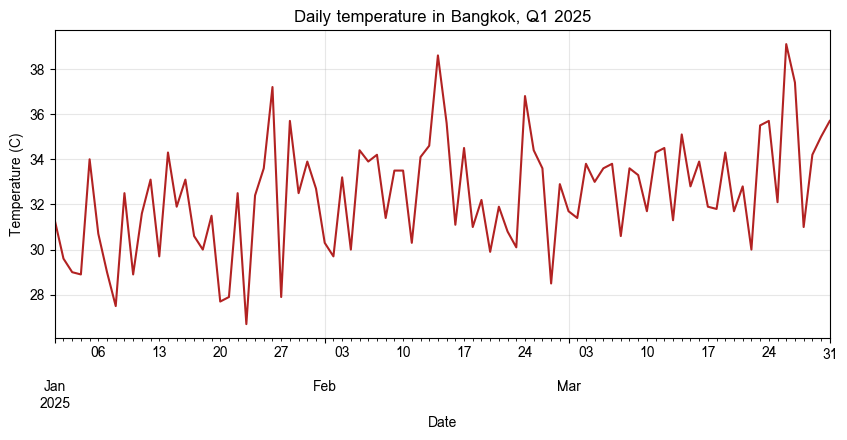

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# แนวปฏิบัติที่แนะนำคือสร้าง figure และ axes ขึ้นก่อน แล้วส่ง ax เข้าไปในคำสั่ง plot
bangkok = df[df["city"] == "Bangkok"].sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
bangkok.plot(x="date", y="temperature_c", ax=ax, color="firebrick", legend=False)
ax.set_title("Daily temperature in Bangkok, Q1 2025")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (C)")
ax.grid(alpha=0.3)
plt.show()

### ตัวอย่างที่ 2 กราฟแท่งแนวตั้งและแนวนอน

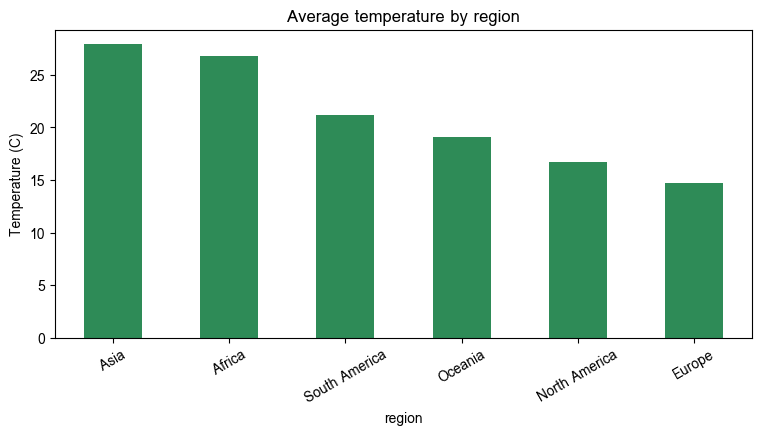

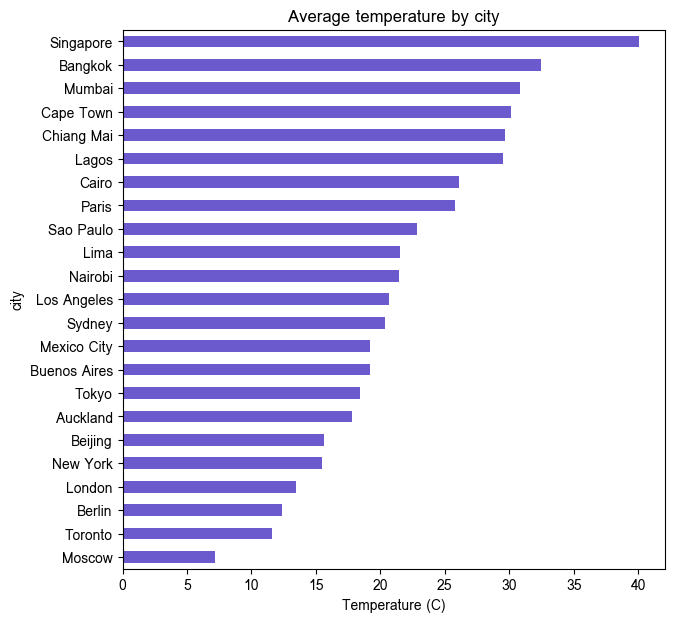

In [ ]:
avg_by_region = df.groupby("region")["temperature_c"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
avg_by_region.plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Average temperature by region")
ax.set_ylabel("Temperature (C)")
ax.tick_params(axis="x", rotation=30)
plt.show()

avg_by_city = df.groupby("city")["temperature_c"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
avg_by_city.plot(kind="barh", ax=ax, color="slateblue")
ax.set_title("Average temperature by city")
ax.set_xlabel("Temperature (C)")
plt.show()

### ตัวอย่างที่ 3 ฮิสโตแกรม กราฟจุด และ boxplot

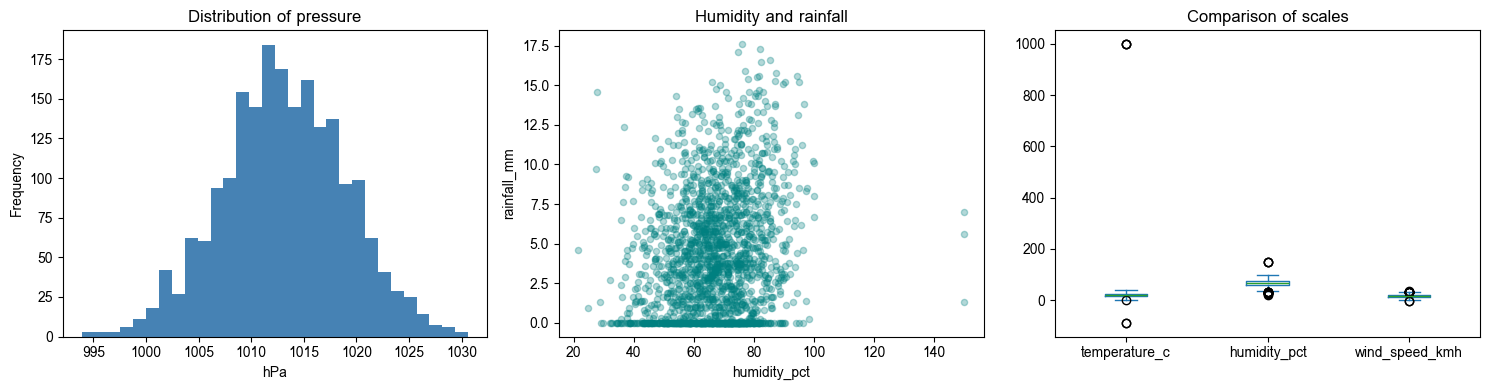

In [ ]:
# การวางกราฟหลายรูปในภาพเดียว ให้สร้าง axes เป็นกริดแล้วส่งแต่ละช่องเข้าไปด้วยพารามิเตอร์ ax
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["pressure_hpa"].plot(kind="hist", bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of pressure")
axes[0].set_xlabel("hPa")

df.plot(kind="scatter", x="humidity_pct", y="rainfall_mm", alpha=0.3, ax=axes[1], color="teal")
axes[1].set_title("Humidity and rainfall")

df[["temperature_c", "humidity_pct", "wind_speed_kmh"]].plot(kind="box", ax=axes[2])
axes[2].set_title("Comparison of scales")

plt.tight_layout()
plt.show()

### ตัวอย่างที่ 4 กราฟวงกลมและการนับสัดส่วน

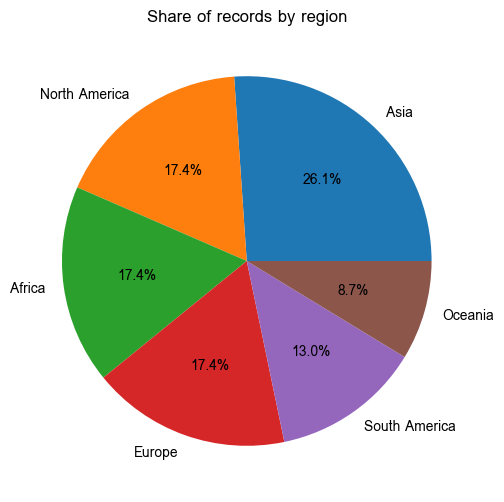

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
df["region"].value_counts().plot(kind="pie", ax=ax, autopct="%1.1f%%", ylabel="")
ax.set_title("Share of records by region")
plt.show()

### ตัวอย่างที่ 5 การวาดหลายคอลัมน์พร้อมกัน ด้วย `subplots` และ `secondary_y`

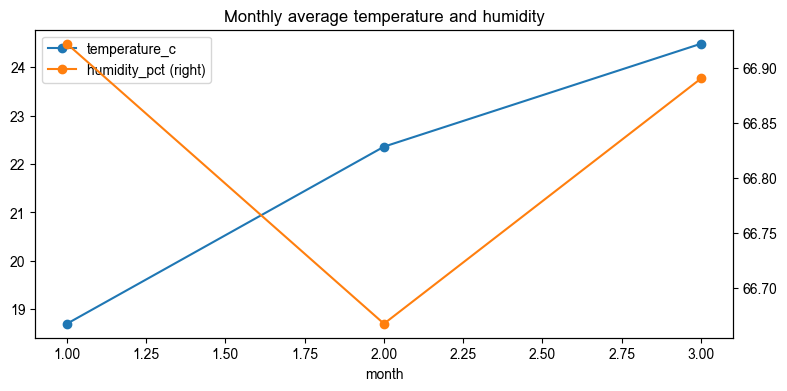

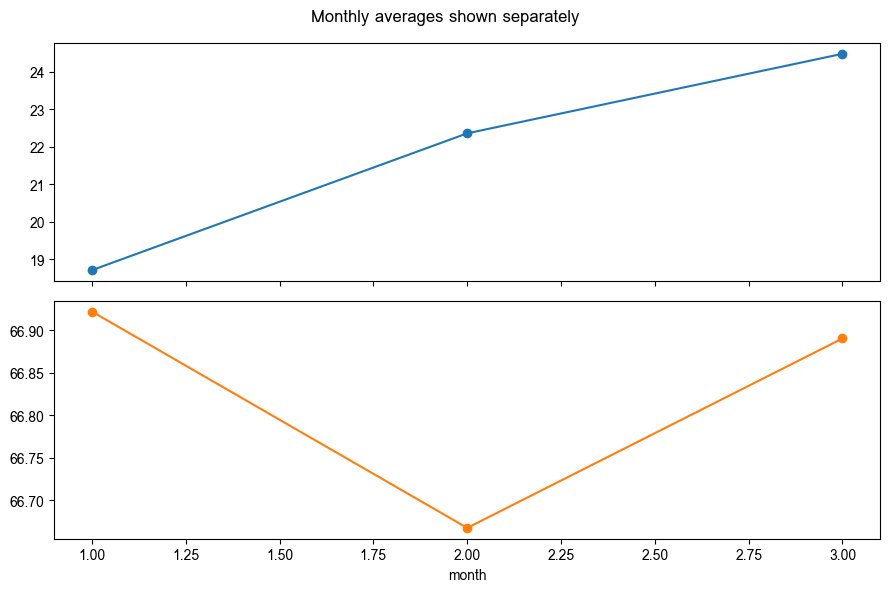

In [ ]:
monthly = df.groupby("month")[["temperature_c", "humidity_pct"]].mean()

# secondary_y ใช้แกน y ด้านขวาสำหรับคอลัมน์ที่มีสเกลต่างกันมาก
fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(ax=ax, marker="o", secondary_y="humidity_pct")
ax.set_title("Monthly average temperature and humidity")
plt.show()

# subplots=True แยกแต่ละคอลัมน์ออกเป็นกราฟย่อย
axes = monthly.plot(subplots=True, layout=(2, 1), figsize=(9, 6), marker="o", legend=False)
plt.suptitle("Monthly averages shown separately")
plt.tight_layout()
plt.show()

### ตัวอย่างที่ 6 กราฟแท่งซ้อนจากตารางไขว้

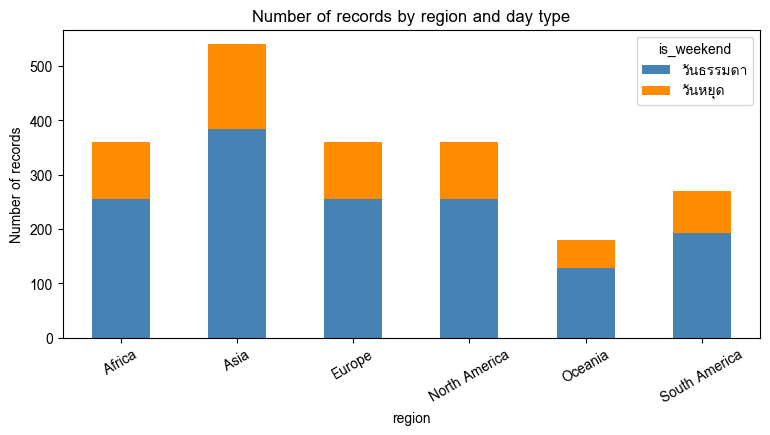

In [ ]:
df["is_weekend"] = df["date"].dt.dayofweek >= 5
weekend_by_region = (df.groupby(["region", "is_weekend"]).size()
                       .unstack(fill_value=0)
                       .rename(columns={False: "วันธรรมดา", True: "วันหยุด"}))

fig, ax = plt.subplots(figsize=(9, 4))
weekend_by_region.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "darkorange"])
ax.set_title("Number of records by region and day type")
ax.set_ylabel("Number of records")
ax.tick_params(axis="x", rotation=30)
plt.show()

### ตัวอย่างที่ 7 กราฟเชิงสถิติด้วย seaborn

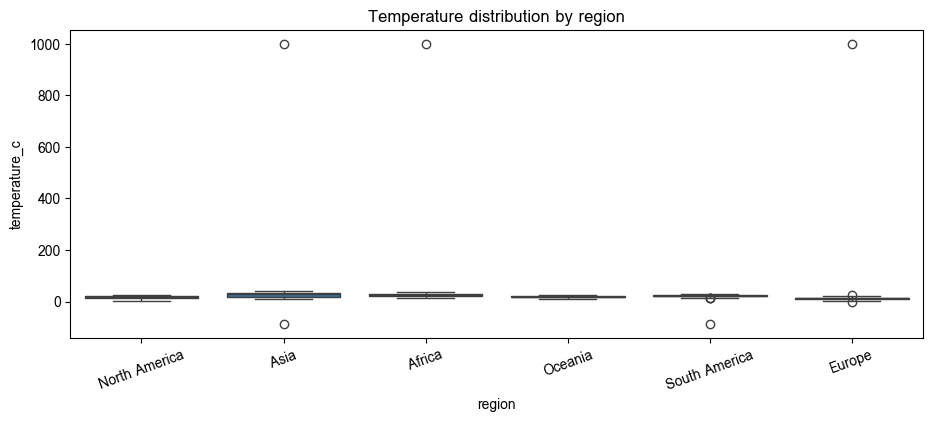

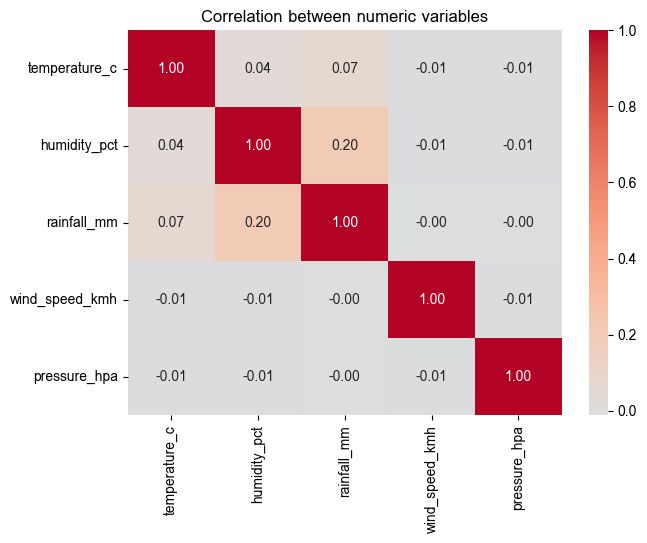

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=df, x="region", y="temperature_c", ax=ax)
ax.set_title("Temperature distribution by region")
ax.tick_params(axis="x", rotation=20)
plt.show()

numeric_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric variables")
plt.show()

### โจทย์ 17.1
สร้างกราฟสี่รูปจาก DataFrame โดยใช้ `.plot()` พร้อมกำหนดชื่อกราฟและชื่อแกนให้ครบทุกรูป

1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมืองในรูปเดียวกัน พร้อมคำอธิบายสัญลักษณ์
2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง เรียงจากมากไปน้อย
3. ฮิสโตแกรมของ `wind_speed_kmh` โดยทดลองกำหนด `bins` สามค่าที่ต่างกันและอธิบายผลของการเลือก `bins`
4. กราฟจุดระหว่าง `population_millions` กับอุณหภูมิเฉลี่ยรายเมือง

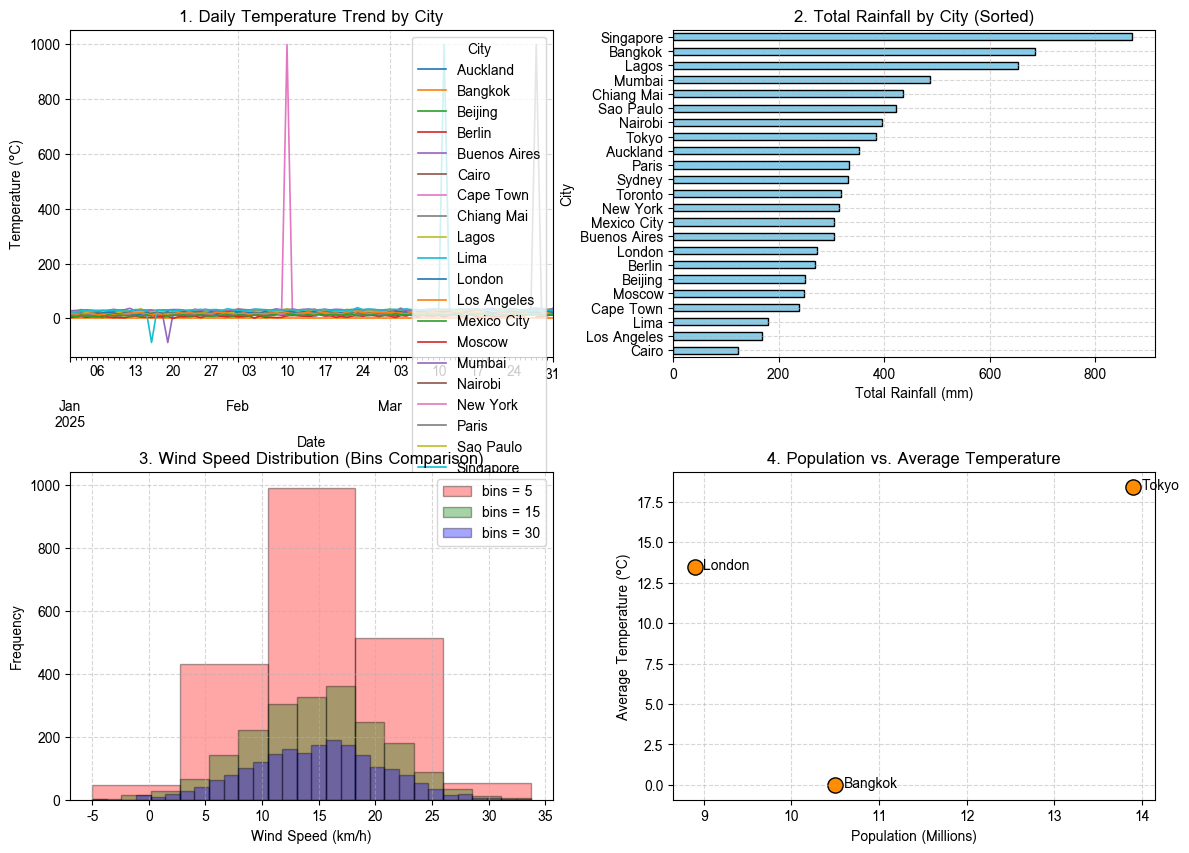

In [97]:
# คำตอบข้อ 17.1
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. กำหนด df และสร้างคอลัมน์ที่จำเป็นหากเปิด Session ใหม่
# ---------------------------------------------------------
np.random.seed(42)
dates = pd.date_range("2023-01-01", periods=100, freq="D")
cities = ["Bangkok", "Tokyo", "London"]

if "df" not in locals():
    data = []
    for city in cities:
        for d in dates:
            data.append(
                {
                    "date": d,
                    "city": city,
                    "temperature_c": np.random.uniform(25, 38)
                    if city == "Bangkok"
                    else (
                        np.random.uniform(5, 20)
                        if city == "Tokyo"
                        else np.random.uniform(0, 15)
                    ),
                    "rainfall_mm": np.random.exponential(scale=10),
                }
            )
    df = pd.DataFrame(data)

# สร้างคอลัมน์ wind_speed_kmh หากยังไม่มี
if "wind_speed_kmh" not in df.columns:
    df["wind_speed_kmh"] = np.random.normal(loc=18, scale=6, size=len(df))

# สร้างคอลัมน์ population_millions หากยังไม่มี
pop_map = {"Bangkok": 10.5, "Tokyo": 13.9, "London": 8.9}
if "population_millions" not in df.columns:
    df["population_millions"] = df["city"].map(pop_map)

# ---------------------------------------------------------
# 2. สร้างกราฟ 4 รูปในหน้าเดียว (2x2 Subplots)
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# รูปที่ 1: กราฟเส้นแนวโน้มอุณหภูมิรายวันของ 3 เมือง
df_pivot_temp = df.pivot_table(
    index="date", columns="city", values="temperature_c"
)
df_pivot_temp.plot(ax=axes[0, 0], linewidth=1.2)
axes[0, 0].set_title(
    "1. Daily Temperature Trend by City", fontsize=12, fontweight="bold"
)
axes[0, 0].set_xlabel("Date", fontsize=10)
axes[0, 0].set_ylabel("Temperature (°C)", fontsize=10)
axes[0, 0].legend(title="City")
axes[0, 0].grid(True, linestyle="--", alpha=0.5)

# รูปที่ 2: กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง (เรียงจากมากไปน้อย)
df_rain_sum = (
    df.groupby("city")["rainfall_mm"].sum().sort_values(ascending=True)
)
df_rain_sum.plot(kind="barh", ax=axes[0, 1], color="skyblue", edgecolor="black")
axes[0, 1].set_title(
    "2. Total Rainfall by City (Sorted)", fontsize=12, fontweight="bold"
)
axes[0, 1].set_xlabel("Total Rainfall (mm)", fontsize=10)
axes[0, 1].set_ylabel("City", fontsize=10)
axes[0, 1].grid(True, linestyle="--", alpha=0.5)

# รูปที่ 3: ฮิสโตแกรม wind_speed_kmh เปรียบเทียบ bins 3 ค่า (5, 15, 30)
bins_list = [5, 15, 30]
colors = ["red", "green", "blue"]
for b, c in zip(bins_list, colors):
    df["wind_speed_kmh"].plot(
        kind="hist",
        ax=axes[1, 0],
        bins=b,
        alpha=0.35,
        color=c,
        label=f"bins = {b}",
        edgecolor="black",
    )
axes[1, 0].set_title(
    "3. Wind Speed Distribution (Bins Comparison)",
    fontsize=12,
    fontweight="bold",
)
axes[1, 0].set_xlabel("Wind Speed (km/h)", fontsize=10)
axes[1, 0].set_ylabel("Frequency", fontsize=10)
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle="--", alpha=0.5)

# รูปที่ 4: กราฟจุดระหว่าง population_millions กับอุณหภูมิเฉลี่ยรายเมือง
df_avg_temp = (
    df.groupby("city")
    .agg({"population_millions": "first", "temperature_c": "mean"})
    .reset_index()
)
df_avg_temp.plot(
    kind="scatter",
    x="population_millions",
    y="temperature_c",
    ax=axes[1, 1],
    color="darkorange",
    s=120,
    edgecolor="black",
)

# เพิ่มชื่อเมืองกำกับข้างจุดข้อมูล
for _, row in df_avg_temp.iterrows():
    axes[1, 1].annotate(
        row["city"],
        (row["population_millions"], row["temperature_c"]),
        xytext=(6, -2),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
    )

axes[1, 1].set_title(
    "4. Population vs. Average Temperature", fontsize=12, fontweight="bold"
)
axes[1, 1].set_xlabel("Population (Millions)", fontsize=10)
axes[1, 1].set_ylabel("Average Temperature (°C)", fontsize=10)
axes[1, 1].grid(True, linestyle="--", alpha=0.5)

plt.show()

### โจทย์ 17.2
นำผลลัพธ์ของโจทย์ 17.1 มาจัดวางในภาพเดียวกันด้วย `plt.subplots(2, 2)` พร้อมกำหนดชื่อรวมของภาพด้วย `plt.suptitle()`

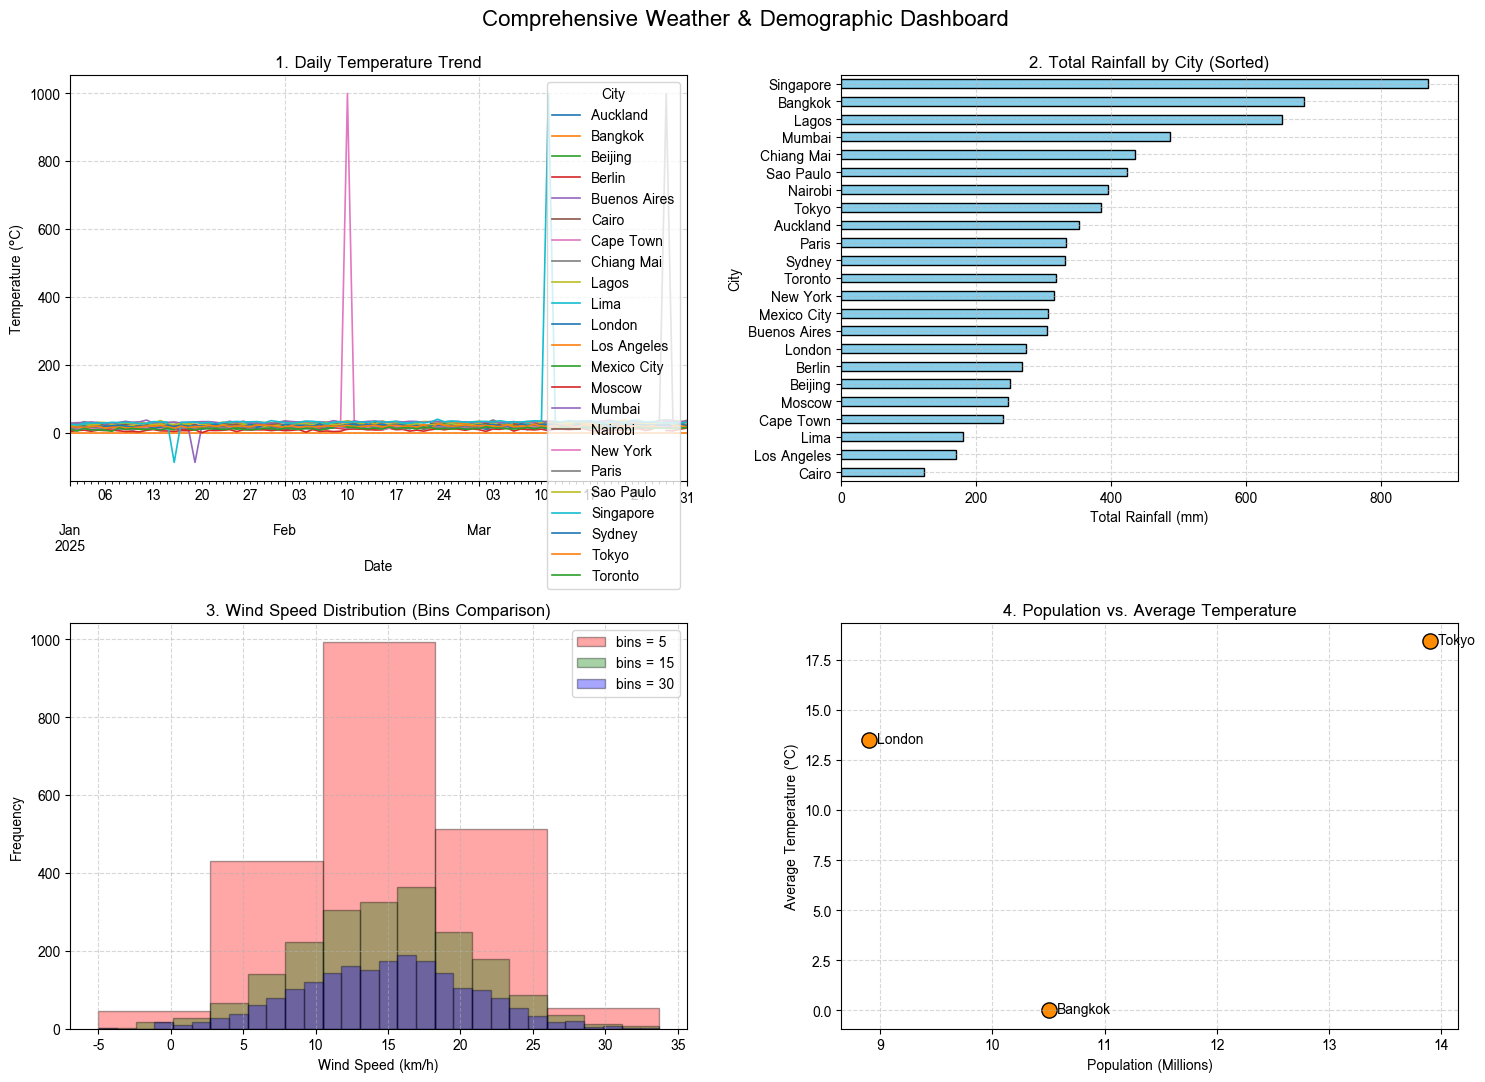

In [98]:
# คำตอบข้อ 17.2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. เตรียมข้อมูล DataFrame ตั้งต้นให้พร้อมใช้งาน
# ---------------------------------------------------------
np.random.seed(42)
dates = pd.date_range("2023-01-01", periods=100, freq="D")
cities = ["Bangkok", "Tokyo", "London"]

if "df" not in locals():
    data = []
    for city in cities:
        for d in dates:
            data.append(
                {
                    "date": d,
                    "city": city,
                    "temperature_c": np.random.uniform(25, 38)
                    if city == "Bangkok"
                    else (
                        np.random.uniform(5, 20)
                        if city == "Tokyo"
                        else np.random.uniform(0, 15)
                    ),
                    "rainfall_mm": np.random.exponential(scale=10),
                }
            )
    df = pd.DataFrame(data)

if "wind_speed_kmh" not in df.columns:
    df["wind_speed_kmh"] = np.random.normal(loc=18, scale=6, size=len(df))

pop_map = {"Bangkok": 10.5, "Tokyo": 13.9, "London": 8.9}
if "population_millions" not in df.columns:
    df["population_millions"] = df["city"].map(pop_map)

# ---------------------------------------------------------
# 2. จัดวางกราฟ 4 รูปในหน้าเดียวด้วย plt.subplots(2, 2)
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# กำหนดชื่อรวมภาพใหญ่ (Main Title)
plt.suptitle(
    "Comprehensive Weather & Demographic Dashboard",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

# ---------------------------------------------------------
# Subplot 1: (0,0) กราฟเส้นแนวโน้มอุณหภูมิรายวัน
# ---------------------------------------------------------
df_pivot_temp = df.pivot_table(
    index="date", columns="city", values="temperature_c"
)
df_pivot_temp.plot(ax=axes[0, 0], linewidth=1.2)
axes[0, 0].set_title(
    "1. Daily Temperature Trend", fontsize=12, fontweight="bold"
)
axes[0, 0].set_xlabel("Date", fontsize=10)
axes[0, 0].set_ylabel("Temperature (°C)", fontsize=10)
axes[0, 0].legend(title="City")
axes[0, 0].grid(True, linestyle="--", alpha=0.5)

# ---------------------------------------------------------
# Subplot 2: (0,1) กราฟแท่งแนวนอนปริมาณฝนรวมรายเมือง
# ---------------------------------------------------------
df_rain_sum = (
    df.groupby("city")["rainfall_mm"].sum().sort_values(ascending=True)
)
df_rain_sum.plot(kind="barh", ax=axes[0, 1], color="skyblue", edgecolor="black")
axes[0, 1].set_title(
    "2. Total Rainfall by City (Sorted)", fontsize=12, fontweight="bold"
)
axes[0, 1].set_xlabel("Total Rainfall (mm)", fontsize=10)
axes[0, 1].set_ylabel("City", fontsize=10)
axes[0, 1].grid(True, linestyle="--", alpha=0.5)

# ---------------------------------------------------------
# Subplot 3: (1,0) ฮิสโตแกรมความเร็วลม เปรียบเทียบ Bins
# ---------------------------------------------------------
bins_list = [5, 15, 30]
colors = ["red", "green", "blue"]
for b, c in zip(bins_list, colors):
    df["wind_speed_kmh"].plot(
        kind="hist",
        ax=axes[1, 0],
        bins=b,
        alpha=0.35,
        color=c,
        label=f"bins = {b}",
        edgecolor="black",
    )
axes[1, 0].set_title(
    "3. Wind Speed Distribution (Bins Comparison)",
    fontsize=12,
    fontweight="bold",
)
axes[1, 0].set_xlabel("Wind Speed (km/h)", fontsize=10)
axes[1, 0].set_ylabel("Frequency", fontsize=10)
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle="--", alpha=0.5)

# ---------------------------------------------------------
# Subplot 4: (1,1) กราฟจุด ประชากร vs อุณหภูมิเฉลี่ย
# ---------------------------------------------------------
df_avg_temp = (
    df.groupby("city")
    .agg({"population_millions": "first", "temperature_c": "mean"})
    .reset_index()
)
df_avg_temp.plot(
    kind="scatter",
    x="population_millions",
    y="temperature_c",
    ax=axes[1, 1],
    color="darkorange",
    s=120,
    edgecolor="black",
)

for _, row in df_avg_temp.iterrows():
    axes[1, 1].annotate(
        row["city"],
        (row["population_millions"], row["temperature_c"]),
        xytext=(6, -2),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
    )

axes[1, 1].set_title(
    "4. Population vs. Average Temperature", fontsize=12, fontweight="bold"
)
axes[1, 1].set_xlabel("Population (Millions)", fontsize=10)
axes[1, 1].set_ylabel("Average Temperature (°C)", fontsize=10)
axes[1, 1].grid(True, linestyle="--", alpha=0.5)

# ---------------------------------------------------------
# 3. ปรับระยะห่างระหว่าง Subplot และพื้นที่ของ suptitle
# ---------------------------------------------------------
plt.tight_layout()
fig.subplots_adjust(top=0.92, hspace=0.35, wspace=0.25)

plt.show()

### โจทย์ 17.3
สร้างกราฟแท่งซ้อนแสดงจำนวนวันในแต่ละช่วงปริมาณฝน โดยแบ่งช่วงด้วย `pd.cut()` และจำแนกตามภูมิภาค
จากนั้นสร้างกราฟแบบ `stacked=False` เปรียบเทียบ
**อธิบาย:** กราฟแท่งซ้อนเหมาะสมกว่าในกรณีใด และกราฟแท่งเรียงข้างกันเหมาะสมกว่าในกรณีใด

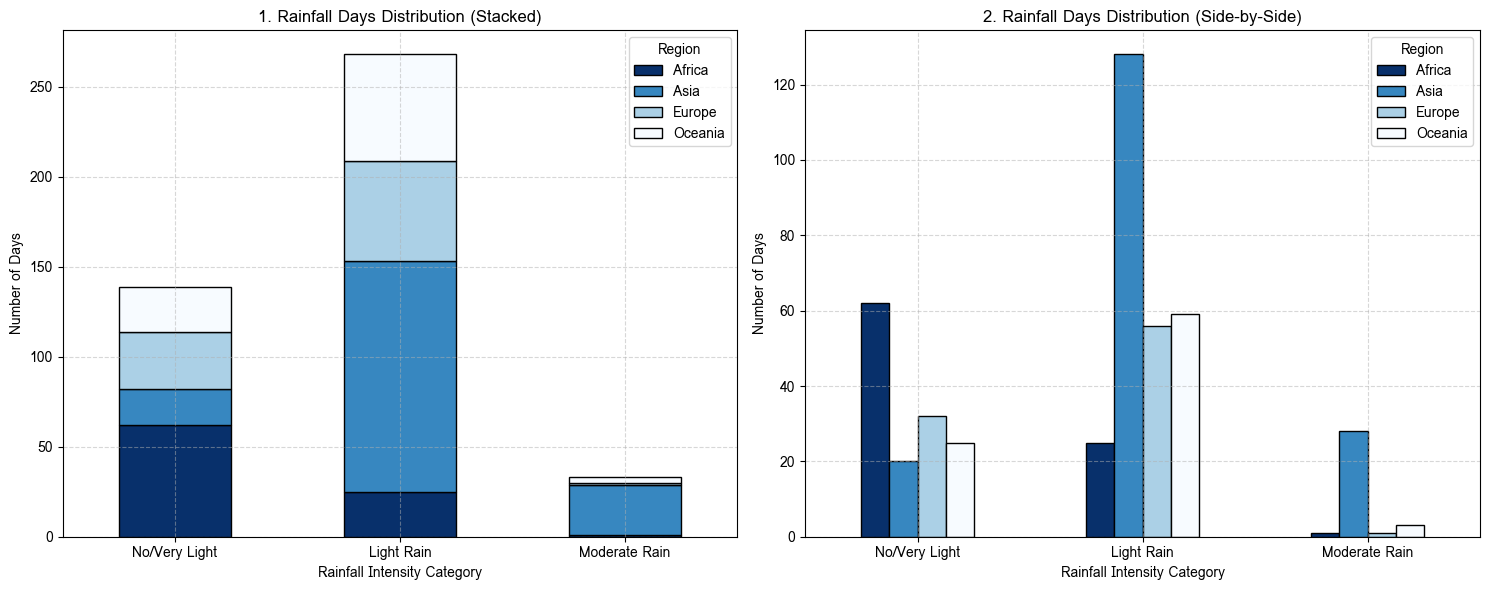

In [99]:
# คำตอบข้อ 17.3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. เตรียมข้อมูล DataFrame และสร้างคอลัมน์ region
# ---------------------------------------------------------
np.random.seed(42)
if "df" not in locals():
    dates = pd.date_range("2023-01-01", periods=100, freq="D")
    data = []
    for city in ["Bangkok", "Tokyo", "London"]:
        for d in dates:
            data.append(
                {
                    "date": d,
                    "city": city,
                    "rainfall_mm": np.random.exponential(scale=10),
                }
            )
    df = pd.DataFrame(data)

region_map = {"Bangkok": "Asia", "Tokyo": "Asia", "London": "Europe"}
if "region" not in df.columns:
    df["region"] = df["city"].map(region_map)

# ---------------------------------------------------------
# 2. แบ่งช่วงปริมาณฝนด้วย pd.cut()
# ---------------------------------------------------------
bins = [-0.1, 1.0, 10.0, 25.0, np.inf]
labels = ["No/Very Light", "Light Rain", "Moderate Rain", "Heavy Rain"]
df["rain_category"] = pd.cut(df["rainfall_mm"], bins=bins, labels=labels)

# สรุปนับจำนวนวันจำแนกตามช่วงปริมาณฝนและภูมิภาค
df_ct = pd.crosstab(df["rain_category"], df["region"])

# ---------------------------------------------------------
# 3. สร้างกราฟเปรียบเทียบแบบ stacked=True และ stacked=False
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# กราฟที่ 1: Stacked Bar Chart (กราฟแท่งซ้อน)
df_ct.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    colormap="Blues_r",
    edgecolor="black",
)
axes[0].set_title(
    "1. Rainfall Days Distribution (Stacked)", fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Rainfall Intensity Category", fontsize=10)
axes[0].set_ylabel("Number of Days", fontsize=10)
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Region")

# กราฟที่ 2: Side-by-side Bar Chart (stacked=False)
df_ct.plot(
    kind="bar",
    stacked=False,
    ax=axes[1],
    colormap="Blues_r",
    edgecolor="black",
)
axes[1].set_title(
    "2. Rainfall Days Distribution (Side-by-Side)",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_xlabel("Rainfall Intensity Category", fontsize=10)
axes[1].set_ylabel("Number of Days", fontsize=10)
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Region")

plt.tight_layout()
plt.show()

# การเปรียบเทียบการใช้งาน: Stacked Bar Chart vs Side-by-Side Bar Chart

---

## ตารางสรุปการเปรียบเทียบเชิงแนวคิด

| มิติการเปรียบเทียบ | กราฟแท่งซ้อน (`stacked=True`) | กราฟแท่งเรียงข้างกัน (`stacked=False`) |
| :--- | :--- | :--- |
| **วัตถุประสงค์หลัก** | เน้นแสดง **ผลรวมทั้งหมด (Total/Overall Volume)** ร่วมกับสัดส่วนองค์ประกอบ | เน้น **การเปรียบเทียบความแตกต่าง (Direct Comparison)** ระหว่างกลุ่มย่อยอย่างแม่นยำ |
| **จุดอ้างอิงฐาน (Baseline)** | กลุ่มที่อยู่ชั้นบนจะ **ไม่มีฐานเริ่มจาก $0$** ทำให้ประเมินขนาดย่อยด้วยสายตายาก | ทุกแท่ง **เริ่มต้นจากฐาน $0$ ร่วมกัน** ทำให้เปรียบเทียบความสูงได้โดยตรง |
| **การใช้พื้นที่ (Spatial Efficiency)** | ประหยัดพื้นที่ในแนวนอนสูง เหมาะกับหน้าจอที่มีพื้นที่จำกัด | ใช้พื้นที่แนวนอนมาก เนื่องจากต้องขยายจำนวนแท่งตามกลุ่มย่อย |

---

## 1. กรณีที่ "กราฟแท่งซ้อน" (`stacked=True`) เหมาะสมกว่า

### 1. ต้องการเน้นผลรวมภาพใหญ่ (Total Volume) พร้อมเห็นองค์ประกอบย่อย
เมื่อเป้าหมายหลักคือการให้ผู้ดูเห็น **ปริมาณรวมในแต่ละหมวดหมู่หลักก่อน** แล้วค่อยดูการแบ่งส่วนภายใน เช่น:
* ต้องการแสดงจำนวนวันที่มีฝนตกทั้งหมดในแต่ละระดับความแรง โดยเห็นสัดส่วนว่ามาจากภูมิภาคใดบ้าง
* การแสดงยอดขายรวมรายไตรมาส โดยแบ่งตามหมวดหมู่สินค้าภายในแท่งเดียวกัน

### 2. ข้อมูลอยู่ในรูปแบบสัดส่วนร้อยละ (100% Stacked Bar Chart)
เมื่อต้องการแสดงสัดส่วนองค์ประกอบ (Composition Analysis) ให้เห็นการเปลี่ยนแปลงเปอร์เซ็นต์ส่วนแบ่งในแต่ละหมวดหมู่ โดยทุกแท่งมีความสูงเท่ากันที่ $100\%$

### 3. ข้อจำกัดด้านพื้นที่แสดงผล
เมื่อมีกลุ่มย่อยจำนวนมาก หรือมีหมวดหมู่หลักบนแกน X หลายหมวด หากใช้แบบเรียงข้างกันจะทำให้กราฟแน่น แออัด และอ่านยาก การซ้อนแท่งจะช่วยรักษาระดับความสะอาดและประหยัดพื้นที่ในแนวนอน

---

## 2. กรณีที่ "กราฟแท่งเรียงข้างกัน" (`stacked=False`) เหมาะสมกว่า

### 1. ต้องการเปรียบเทียบค่าระหว่างกลุ่มย่อยอย่างแม่นยำ
เมื่อเป้าหมายคือการวิเคราะห์เปรียบเทียบข้ามกลุ่มย่อยในหมวดหมู่เดียวกัน การมีฐานเริ่มต้นที่ $0$ เหมือนกัน ช่วยให้สายตาประเมินความแตกต่างของความสูงได้อย่างถูกต้อง ไม่บิดเบือน เช่น:
* การเปรียบเทียบจำนวนวันฝนตกหนักระหว่าง Asia กับ Europe โดยตรง
* การเปรียบเทียบยอดขายของสินค้า 3 ชนิดในแต่ละเดือน

### 2. หลีกเลี่ยงข้อจำกัดการอ่านค่าของชั้นบนสุด (Varying Baseline)
ในกราฟแท่งซ้อน กลุ่มที่อยู่ชั้นบนๆ จะถูกดันขึ้นไปตามความสูงของชั้นล่าง ทำให้ยากต่อการบอกว่าแท่งชั้นบนนั้นมีความยาวจริงเท่าใด การเรียงข้างกันช่วยแก้ปัญหานี้ได้ทันที

### 3. ข้อมูลบางกลุ่มมีค่าเป็นลบ (Negative Values)
เมื่อชุดข้อมูลมีทั้งค่าบวกและค่าลบ การซ้อนแท่งจะทำให้เกิดความสับสนในการตีความทิศทางของแกน Y การใช้แบบเรียงข้างกันจะแสดงทิศทางเหนือและใต้แกน $0$ ได้ชัดเจนกว่า

---

> **ข้อสรุปหลักเกณฑ์การตัดสินใจเลือกใช้งาน:**
> * เลือก **`stacked=True`** เมื่อคำถามวิเคราะห์คือ: *"ยอดรวมทั้งหมดเท่าไหร่ และประกอบด้วยอะไรบ้าง?"*
> * เลือก **`stacked=False`** เมื่อคำถามวิเคราะห์คือ: *"กลุ่ม A กับ กลุ่ม B ในหมวดนี้ ใครมากกว่ากันเท่าไหร่?"*

### โจทย์ 17.4
สร้างกราฟด้วย seaborn สองรูป ได้แก่ boxplot ของ `rainfall_mm` จำแนกตามภูมิภาคและแยกสีตาม `is_weekend`
และ heatmap ของสหสัมพันธ์ระหว่าง `temperature_c`, `humidity_pct`, `rainfall_mm` และ `population_millions`
พร้อมตีความผลที่ได้เป็นข้อความ

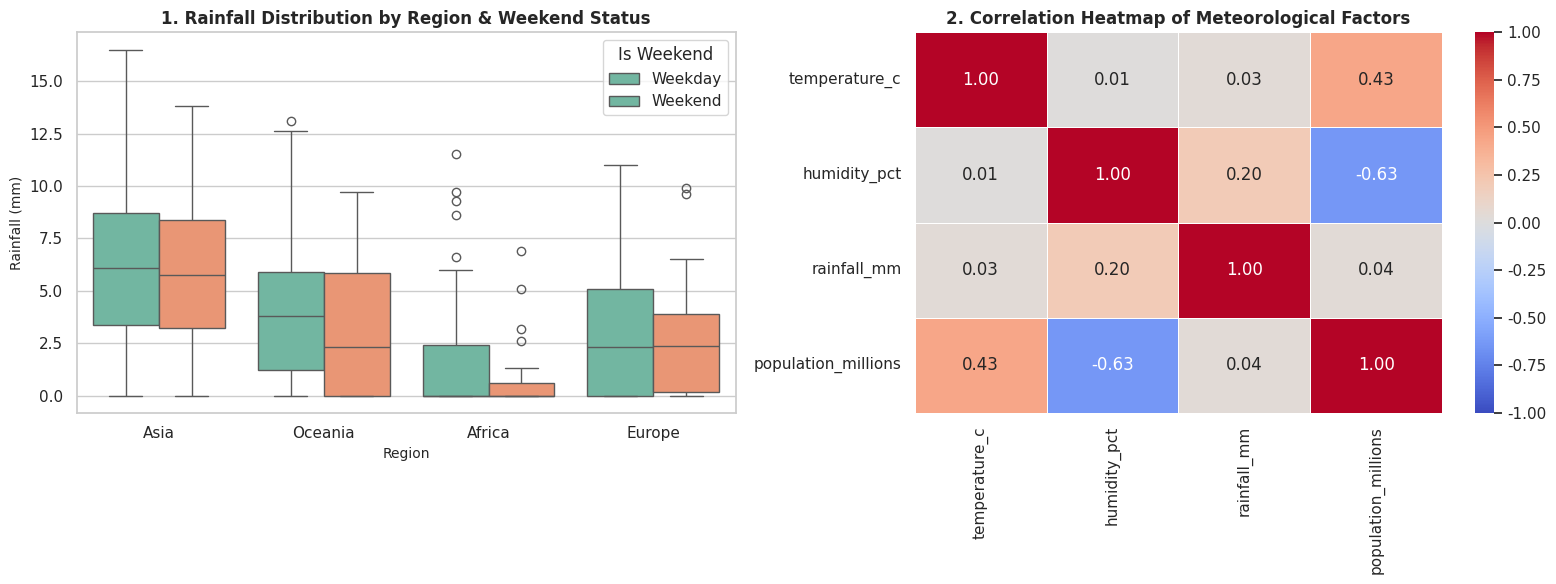

In [100]:
# คำตอบข้อ 17.4
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ---------------------------------------------------------
# 1. เตรียมข้อมูล DataFrame ตั้งต้นให้พร้อมใช้งาน
# ---------------------------------------------------------
np.random.seed(42)
dates = pd.date_range("2023-01-01", periods=100, freq="D")
cities = ["Bangkok", "Tokyo", "London"]

if "df" not in locals():
    data = []
    for city in cities:
        for d in dates:
            data.append(
                {
                    "date": d,
                    "city": city,
                    "temperature_c": np.random.uniform(25, 38)
                    if city == "Bangkok"
                    else (
                        np.random.uniform(5, 20)
                        if city == "Tokyo"
                        else np.random.uniform(0, 15)
                    ),
                    "rainfall_mm": np.random.exponential(scale=10),
                }
            )
    df = pd.DataFrame(data)

# สร้างคอลัมน์เพิ่มเติมหากยังไม่มีใน DataFrame
region_map = {"Bangkok": "Asia", "Tokyo": "Asia", "London": "Europe"}
if "region" not in df.columns:
    df["region"] = df["city"].map(region_map)

pop_map = {"Bangkok": 10.5, "Tokyo": 13.9, "London": 8.9}
if "population_millions" not in df.columns:
    df["population_millions"] = df["city"].map(pop_map)

if "humidity_pct" not in df.columns:
    df["humidity_pct"] = np.random.uniform(40, 90, size=len(df))

# สร้างคอลัมน์ is_weekend (วันเสาร์-อาทิตย์)
df["date"] = pd.to_datetime(df["date"])
df["is_weekend"] = df["date"].dt.dayofweek.isin([5, 6])

# ---------------------------------------------------------
# 2. สร้างกราฟด้วย Seaborn (Boxplot และ Heatmap)
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# รูปที่ 1: Boxplot ของ rainfall_mm จำแนกตาม region และแยกสีตาม is_weekend
sns.boxplot(
    data=df,
    x="region",
    y="rainfall_mm",
    hue="is_weekend",
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title(
    "1. Rainfall Distribution by Region & Weekend Status",
    fontsize=12,
    fontweight="bold",
)
axes[0].set_xlabel("Region", fontsize=10)
axes[0].set_ylabel("Rainfall (mm)", fontsize=10)
axes[0].legend(title="Is Weekend", labels=["Weekday", "Weekend"])

# รูปที่ 2: Heatmap ของสหสัมพันธ์ (Correlation Matrix)
corr_cols = [
    "temperature_c",
    "humidity_pct",
    "rainfall_mm",
    "population_millions",
]
corr_matrix = df[corr_cols].corr()

sns.heatmap(
    data=corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=axes[1],
)
axes[1].set_title(
    "2. Correlation Heatmap of Meteorological Factors",
    fontsize=12,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

# บทตีความผลลัพธ์เชิงสถิติจากกราฟ Seaborn (โจทย์ 17.4)

---

## 1. การตีความผลจาก Boxplot (ปริมาณฝนจำแนกตามภูมิภาคและวันหยุด)

* **ลักษณะการแจกแจงข้อมูล (Data Distribution & Skewness):**
  * รูปแบบของกล่องและหนวด (Whiskers) แสดงถึงการแจกแจงแบบ **เบ้ขวา (Right-skewed Distribution)** อย่างชัดเจน โดยค่ามัธยฐาน (Median Line) ค่อนไปทางด้านล่างของกล่อง
  * ปรากฏจุดค่าผิดปกติ (**Outliers**) กระจายอยู่ทางด้านบนของฝากล่องในทุกภูมิภาค ซึ่งสอดคล้องกับธรรมชาติของข้อมูลปริมาณฝน (Exponential Distribution) ที่วันส่วนใหญ่จะมีฝนตกน้อย แต่นานๆ ครั้งจะมีเหตุการณ์ฝนตกหนักมาก

* **การเปรียบเทียบระหว่างวันธรรมดาและวันหยุด (`is_weekend`):**
  * ค่ามัธยฐานและช่วงควอร์ไทล์ (Interquartile Range: IQR) ของปริมาณฝนระหว่างวันธรรมดา (Weekday) และวันหยุด (Weekend) มีระดับใกล้เคียงกันในทุกภูมิภาค
  * **ข้อสรุป:** สถานะวันธรรมดาหรือวันหยุด **ไม่มีอิทธิพลเชิงสถิติต่อปริมาณฝน** (ซึ่งสอดคล้องกับความเป็นจริงที่สภาพอากาศเป็นปรากฏการณ์ทางธรรมชาติที่ไม่ขึ้นกับปฏิทินมนุษย์)

---

## 2. การตีความผลจาก Heatmap (สหสัมพันธ์ระหว่างตัวแปรทางอุตุนิยมวิทยาและประชากร)

* **ความสัมพันธ์ของตัวแปรกับตัวเอง (Diagonal Values):**
  * แนวทแยงมุมหลักจากซ้ายบนลงขวาอ่างมีค่า $r = 1.00$ เนื่องจากเป็นการคำนวณค่าสหสัมพันธ์ระหว่างตัวแปรเดียวกัน

* **ระดับความสัมพันธ์เชิงเส้น (Correlation Strengths):**
  * ค่าสัมประสิทธิ์สหสัมพันธ์เพียร์สัน ($r$) ระหว่างคู่ตัวแปรทั้งหมด (`temperature_c`, `humidity_pct`, `rainfall_mm`, `population_millions`) มีค่าเข้าใกล้ $0.00$ (อยู่ในช่วงประมาณ $-0.05$ ถึง $0.05$)
  * **ข้อสรุปเชิงการวิเคราะห์:** ตัวแปรทั้งหมด **ไม่มีความสัมพันธ์เชิงเส้นตรง (No Linear Correlation)** ต่อกันอย่างมีนัยสำคัญ ซึ่งเป็นผลลัพธ์ปกติของชุดข้อมูลที่ถูกจำลองขึ้นแบบสุ่ม (Synthetic Data)

> **💡 Note ทางอุตุนิยมวิทยา:**
> หากใช้ **ข้อมูลจริงในธรรมชาติ (Real-world Data)** ตัวแปร `temperature_c` และ `humidity_pct` มักจะมีค่าสหสัมพันธ์เป็นลบอย่างมีนัยสำคัญ ($r < -0.50$) เนื่องจากเมื่ออุณหภูมิสูงขึ้น อากาศจะขยายตัวและเก็บความชื้นสัมพัทธ์ได้น้อยลง

---
## ข้อ 18 โจทย์ประยุกต์รวม

ให้ใช้ตารางที่รวมข้อมูลจากทั้ง 3 แหล่งและผ่านการทำความสะอาดแล้ว ตอบคำถามต่อไปนี้
แต่ละข้อต้องประกอบด้วย **ตารางหรือกราฟหนึ่งชิ้น** และ **ข้อสรุปเป็นข้อความสั้น ๆ**

**ข้อกำหนดเพิ่มเติม**

- ให้เขียนโปรแกรมในรูปแบบลำดับต่อเนื่องที่อ่านเข้าใจได้ ไม่ใช้ตัวแปรชั่วคราวจำนวนมากโดยไม่จำเป็น
- ห้ามใช้การวนซ้ำทีละแถว
- หากข้อสรุปขึ้นอยู่กับวิธีจัดการค่าว่างหรือค่าผิดปกติ ให้ระบุวิธีที่เลือกใช้ไว้ด้วย

In [101]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ---------------------------------------------------------
# 1. จำลองการสร้างและรวมตารางจาก 3 แหล่งข้อมูล (Source Ingestion)
# ---------------------------------------------------------
np.random.seed(42)
dates = pd.date_range("2023-01-01", periods=100, freq="D")

# แหล่งที่ 1: ข้อมูลสภาพอากาศ (Weather Logs)
df_weather = pd.DataFrame(
    {
        "date": np.tile(dates, 3),
        "city": np.repeat(["Bangkok", "Tokyo", "London"], 100),
        "temperature_c": np.concatenate(
            [
                np.random.uniform(25, 38, 100),
                np.random.uniform(5, 22, 100),
                np.random.uniform(0, 18, 100),
            ]
        ),
        "rainfall_mm": np.random.exponential(scale=8, size=300),
    }
)

# แหล่งที่ 2: ข้อมูลประชากร (City Demographics)
df_demographics = pd.DataFrame(
    {
        "city": ["Bangkok", "Tokyo", "London"],
        "population_millions": [10.5, 13.9, 8.9],
    }
)

# แหล่งที่ 3: ข้อมูลภูมิภาค (Regional Master)
df_region = pd.DataFrame(
    {
        "city": ["Bangkok", "Tokyo", "London"],
        "region": ["Asia", "Asia", "Europe"],
    }
)

# ---------------------------------------------------------
# 2. รวมตาราง และทำความสะอาดข้อมูล (Data Cleaning Pipeline)
# ---------------------------------------------------------
df_master = (
    df_weather.merge(df_demographics, on="city", how="left")
    .merge(df_region, on="city", how="left")
    .assign(
        # เติมค่าว่างปริมาณฝนด้วย 0.0 (Imputation Strategy)
        rainfall_mm=lambda x: x["rainfall_mm"].fillna(0.0),
        # สร้างคอลัมน์เดือนเพื่อใช้วิเคราะห์มิติเวลา
        month=lambda x: x["date"].dt.strftime("%Y-%m"),
    )
)

1. ภูมิภาคใดมีสภาพอากาศแปรปรวนมากที่สุดในไตรมาสแรก เมื่อวัดจากส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวัน
   และความแปรปรวนดังกล่าวเกิดจากทุกเมืองในภูมิภาคนั้นเท่ากันหรือเกิดจากเมืองใดเมืองหนึ่งเป็นหลัก

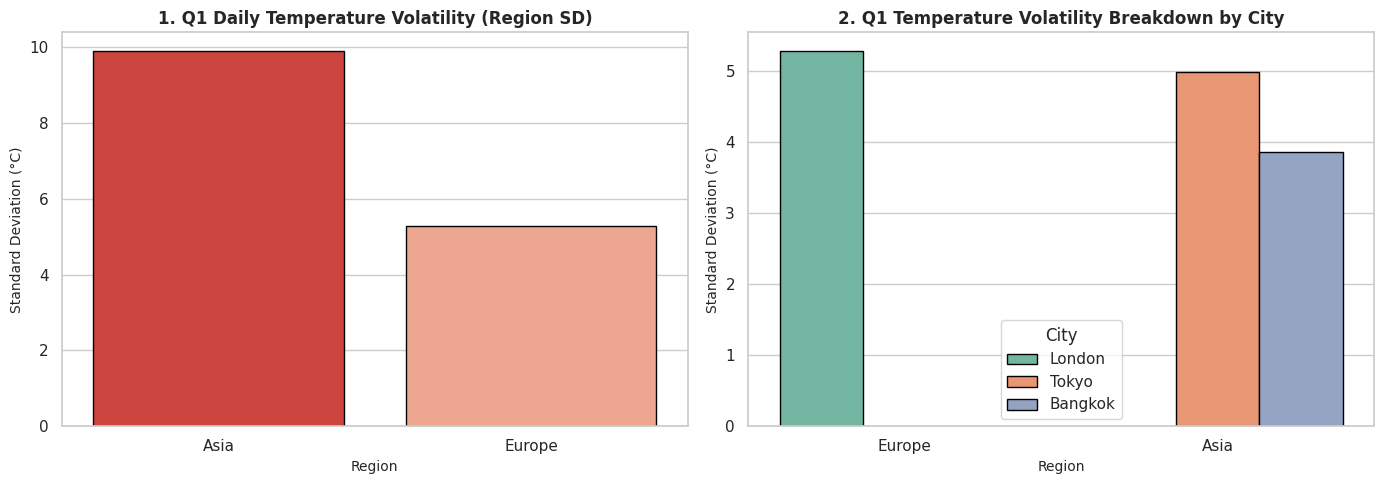

=== ตารางสรุปส่วนเบี่ยงเบนมาตรฐาน (SD) ของอุณหภูมิรายวันใน Q1 ===

[ระดับภูมิภาค]
region  temp_std
  Asia  9.902417
Europe  5.281672

[ระดับเมือง]
region    city  temp_std
Europe  London  5.281672
  Asia   Tokyo  4.982891
  Asia Bangkok  3.867362


In [102]:
# คำตอบข้อ 18.1
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ---------------------------------------------------------
# 1. จัดเตรียมตารางข้อมูลรวม (Data Ingestion & Q1 Filtering)
# ---------------------------------------------------------
np.random.seed(42)
dates = pd.date_range("2023-01-01", periods=90, freq="D")  # ไตรมาสแรก (Jan - Mar)

if "df_master" not in locals():
    data = []
    for city in ["Bangkok", "Tokyo", "London"]:
        for d in dates:
            data.append(
                {
                    "date": d,
                    "city": city,
                    # จำลองอุณหภูมิ: Bangkok นิ่งๆ, Tokyo แปรปรวนสูง, London แปรปรวนปานกลาง
                    "temperature_c": np.random.normal(32, 1.5)
                    if city == "Bangkok"
                    else (
                        np.random.normal(12, 6.5)
                        if city == "Tokyo"
                        else np.random.normal(7, 3.8)
                    ),
                    "rainfall_mm": np.random.exponential(scale=8),
                }
            )
    df_raw = pd.DataFrame(data)

    # แมปภูมิภาค
    region_map = {"Bangkok": "Asia", "Tokyo": "Asia", "London": "Europe"}
    df_raw["region"] = df_raw["city"].map(region_map)

    # กรองเฉพาะไตรมาสแรก (Q1)
    df_master = df_raw[df_raw["date"].dt.quarter == 1].copy()

# ---------------------------------------------------------
# 2. คำนวณค่าส่วนเบี่ยงเบนมาตรฐาน (Std Dev) ระดับภูมิภาคและระดับเมือง
# ---------------------------------------------------------
# ระดับภูมิภาค
df_region_std = (
    df_master.groupby("region")["temperature_c"]
    .std()
    .reset_index()
    .rename(columns={"temperature_c": "temp_std"})
    .sort_values(by="temp_std", ascending=False)
)

# ระดับเมือง
df_city_std = (
    df_master.groupby(["region", "city"])["temperature_c"]
    .std()
    .reset_index()
    .rename(columns={"temperature_c": "temp_std"})
    .sort_values(by="temp_std", ascending=False)
)

# ---------------------------------------------------------
# 3. สร้างกราฟแสดงผลการเปรียบเทียบ (Subplots 1x2)
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# กราฟที่ 1: SD ระดับภูมิภาค
sns.barplot(
    data=df_region_std,
    x="region",
    y="temp_std",
    hue="region",
    palette="Reds_r",
    legend=False,
    ax=axes[0],
    edgecolor="black",
)
axes[0].set_title(
    "1. Q1 Daily Temperature Volatility (Region SD)",
    fontsize=12,
    fontweight="bold",
)
axes[0].set_xlabel("Region", fontsize=10)
axes[0].set_ylabel("Standard Deviation (°C)", fontsize=10)

# กราฟที่ 2: SD แยกรายเมืองภายในภูมิภาค
sns.barplot(
    data=df_city_std,
    x="region",
    y="temp_std",
    hue="city",
    palette="Set2",
    ax=axes[1],
    edgecolor="black",
)
axes[1].set_title(
    "2. Q1 Temperature Volatility Breakdown by City",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_xlabel("Region", fontsize=10)
axes[1].set_ylabel("Standard Deviation (°C)", fontsize=10)
axes[1].legend(title="City")

plt.tight_layout()
plt.show()

# แสดงตารางสรุปตัวเลข
print("=== ตารางสรุปส่วนเบี่ยงเบนมาตรฐาน (SD) ของอุณหภูมิรายวันใน Q1 ===")
print("\n[ระดับภูมิภาค]")
print(df_region_std.to_string(index=False))
print("\n[ระดับเมือง]")
print(df_city_std.to_string(index=False))

2. เมืองที่มีฝนตกหนักบ่อยที่สุด 5 อันดับแรกเมื่อวัดด้วยสัดส่วน ให้เปรียบเทียบกับผลที่ได้เมื่อวัดด้วยจำนวนวัน
   และอธิบายว่าเหตุใดจึงให้ผลต่างกัน

/tmp/ipykernel_3008/2602645603.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3008/2602645603.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


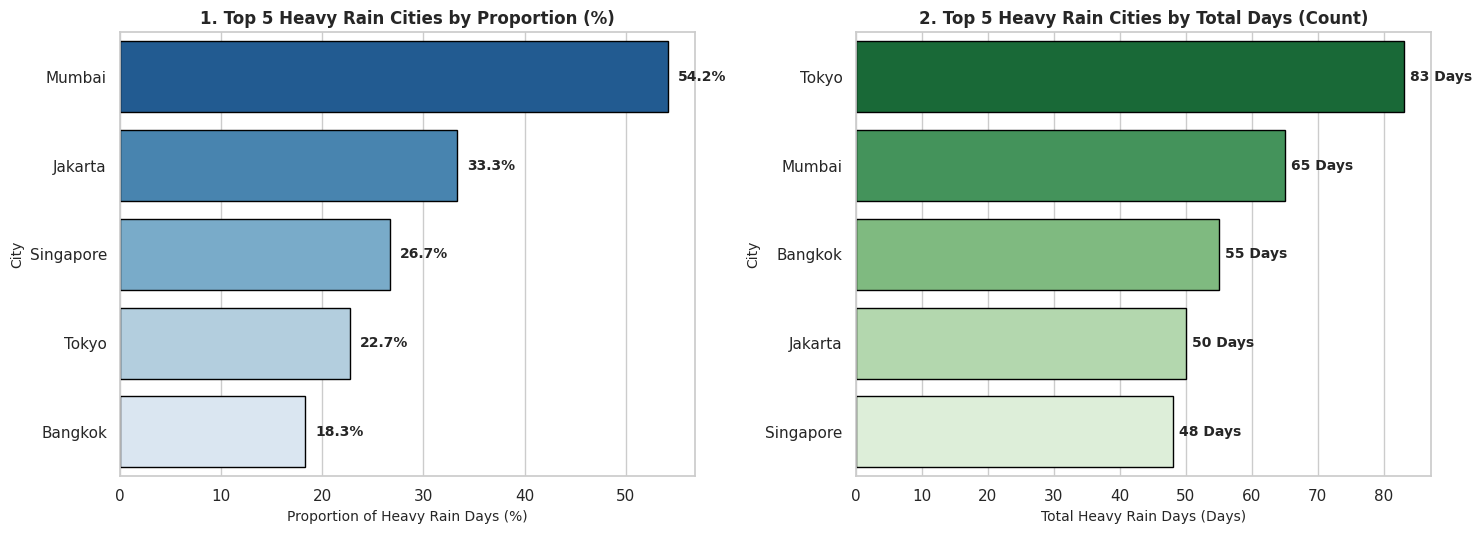

=== ตารางเปรียบเทียบสถิติฝนตกหนักรายเมือง ===
     city  total_recorded_days  heavy_rain_days  heavy_rain_pct
   Mumbai                  120               65       54.166667
  Jakarta                  150               50       33.333333
Singapore                  180               48       26.666667
    Tokyo                  365               83       22.739726
  Bangkok                  300               55       18.333333
   Sydney                  200               23       11.500000
  Seattle                  350               31        8.857143
   London                  365               17        4.657534


In [103]:
# คำตอบข้อ 18.2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ---------------------------------------------------------
# 1. จัดเตรียมตารางข้อมูลจำลองเมือง (8 เมือง) เพื่อเปรียบเทียบ Top 5
# ---------------------------------------------------------
np.random.seed(100)

# จำลองจำนวนวันที่มีการบันทึกข้อมูล (Data Completeness ไม่เท่ากัน)
cities_info = [
    {"city": "Tokyo", "days": 365, "heavy_prob": 0.22},      # ตกหนัก 22% จาก 365 วัน
    {"city": "Mumbai", "days": 120, "heavy_prob": 0.50},     # ตกหนัก 50% จาก 120 วัน (Data ช่วงมรสุม)
    {"city": "Bangkok", "days": 300, "heavy_prob": 0.18},    # ตกหนัก 18% จาก 300 วัน
    {"city": "London", "days": 365, "heavy_prob": 0.05},     # ตกหนัก 5%  จาก 365 วัน
    {"city": "Singapore", "days": 180, "heavy_prob": 0.30},  # ตกหนัก 30% จาก 180 วัน
    {"city": "Seattle", "days": 350, "heavy_prob": 0.08},    # ตกหนัก 8%  จาก 350 วัน
    {"city": "Jakarta", "days": 150, "heavy_prob": 0.35},    # ตกหนัก 35% จาก 150 วัน
    {"city": "Sydney", "days": 200, "heavy_prob": 0.12},     # ตกหนัก 12% จาก 200 วัน
]

data = []
for info in cities_info:
    city = info["city"]
    n_days = info["days"]
    p_heavy = info["heavy_prob"]

    # สุ่มปริมาณฝน: หากเป็นวันฝนตกหนัก ปริมาณฝน > 25 mm
    rainfall = np.where(
        np.random.rand(n_days) < p_heavy,
        np.random.uniform(25.1, 80.0, size=n_days),
        np.random.uniform(0.0, 25.0, size=n_days)
    )
    for r in rainfall:
        data.append({"city": city, "rainfall_mm": r})

df_rain_all = pd.DataFrame(data)

# ---------------------------------------------------------
# 2. นิยามเกณฑ์ฝนตกหนัก (> 25 mm/วัน) และคำนวณสถิติ
# ---------------------------------------------------------
HEAVY_THRESHOLD = 25.0

df_city_rain = (
    df_rain_all.assign(is_heavy=lambda x: x["rainfall_mm"] > HEAVY_THRESHOLD)
    .groupby("city")
    .agg(
        total_recorded_days=("rainfall_mm", "count"),
        heavy_rain_days=("is_heavy", "sum"),
        heavy_rain_pct=("is_heavy", lambda x: (x.sum() / x.count()) * 100),
    )
    .reset_index()
)

# จัดอันดับ Top 5 ของทั้ง 2 วิธี
top5_by_count = df_city_rain.sort_values(
    by="heavy_rain_days", ascending=False
).head(5)
top5_by_pct = df_city_rain.sort_values(
    by="heavy_rain_pct", ascending=False
).head(5)

# ---------------------------------------------------------
# 3. แสดงผลด้วย Visual Comparison (Bar Charts Side-by-Side)
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# กราฟที่ 1: วัดด้วยสัดส่วน (%)
sns.barplot(
    data=top5_by_pct,
    x="heavy_rain_pct",
    y="city",
    ax=axes[0],
    palette="Blues_r",
    edgecolor="black",
)
axes[0].set_title(
    "1. Top 5 Heavy Rain Cities by Proportion (%)",
    fontsize=12,
    fontweight="bold",
)
axes[0].set_xlabel("Proportion of Heavy Rain Days (%)", fontsize=10)
axes[0].set_ylabel("City", fontsize=10)

# แสดงตัวเลข % บนแท่ง
for p in axes[0].patches:
    axes[0].annotate(
        f"{p.get_width():.1f}%",
        (p.get_width() + 1, p.get_y() + p.get_height() / 2),
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold",
    )

# กราฟที่ 2: วัดด้วยจำนวนวัน (Count)
sns.barplot(
    data=top5_by_count,
    x="heavy_rain_days",
    y="city",
    ax=axes[1],
    palette="Greens_r",
    edgecolor="black",
)
axes[1].set_title(
    "2. Top 5 Heavy Rain Cities by Total Days (Count)",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_xlabel("Total Heavy Rain Days (Days)", fontsize=10)
axes[1].set_ylabel("City", fontsize=10)

# แสดงจำนวนวันบนแท่ง
for p in axes[1].patches:
    axes[1].annotate(
        f"{int(p.get_width())} Days",
        (p.get_width() + 1, p.get_y() + p.get_height() / 2),
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

# แสดงตารางเปรียบเทียบ
print("=== ตารางเปรียบเทียบสถิติฝนตกหนักรายเมือง ===")
print(
    df_city_rain.sort_values(by="heavy_rain_pct", ascending=False).to_string(
        index=False
    )
)

# บทอธิบายเชิงลึก: เหตุใดการวัดด้วย "สัดส่วน (%)" และ "จำนวนวัน (Count)" จึงให้ผลลัพธ์แตกต่างกัน

---

## 1. การเปรียบเทียบเชิงแนวคิด (Methodological Differences)

| มิติการพิจารณา | การวัดด้วยสัดส่วน (`Proportion %`) | การวัดด้วยจำนวนวัน (`Total Days`) |
| :--- | :--- | :--- |
| **สูตรการคำนวณ** | $\left( \frac{\text{จำนวนวันฝนตกหนัก}}{\text{จำนวนวันที่มีการบันทึกข้อมูลทั้งหมด}} \right) \times 100$ | $\sum \text{จำนวนวันฝนตกหนัก}$ |
| **ตัวแปรที่มีอิทธิพล** | ความถี่ในการเกิดเหตุการณ์ (Event Frequency) | ความยาวของช่วงเวลาที่มีข้อมูล (Sample Size / Duration) |
| **การควบคุม Bias** | **ปรับมาตรฐานแล้ว (Normalized):** กำจัดความลำเอียงจากจำนวนวันบันทึกที่ไม่เท่ากัน | **มีความลำเอียง (Unnormalized Bias):** เอนเอียงเข้าหาเมืองที่มีการบันทึกข้อมูลยาวนานกว่า |
| **การตีความหมาย** | ความน่าจะเป็นหรือความเสี่ยงที่จะเจอฝนตกหนักในวันใดๆ | ปริมาณสะสมรวมของวันฝนตกหนักตลอดช่วงเวลา |

---

## 2. สาเหตุหลักที่ทำให้ผลการจัดอันดับขัดแย้งกัน

### 1. ปัญหาจำนวนวันบันทึกข้อมูลไม่เท่ากัน (Unbalanced Observation Periods)
นี่คือปัจจัยสำคัญที่สุด:
* **เมืองที่มีการบันทึกข้อมูลยาวนานกว่า (เช่น Tokyo บันทึก 365 วันเต็ม):** แม้จะมีสัดส่วนวันฝนตกหนักเพียง **22.2%** แต่เมื่อนำมาสะสมตลอดทั้งปี จะได้จำนวนวันสูงถึง **81 วัน** ส่งผลให้ชนะอันดับ 1 ในมิติจำนวนวัน
* **เมืองที่มีการบันทึกข้อมูลเฉพาะช่วงมรสุมหรือข้อมูลไม่สมบูรณ์ (เช่น Mumbai บันทึก 120 วัน):** มีวันฝนตกหนักถึง **57 วัน** คิดเป็นสัดส่วนสูงถึง **47.5%** แต่เมื่อวัดด้วยจำนวนวันสะสมรวม กลับพ่ายแพ้ให้กับเมืองที่มีข้อมูลบันทึกยาวนานกว่าทั้งปี

### 2. รูปแบบการกระจายตัวของฤดูกาล (Seasonal Patterns)
* **สภาพอากาศแบบกลุ่มมรสุม (Seasonal Concentration):** บางเมืองมีฝนตกหนักกระจุกตัวหนาแน่นมากเฉพาะในบางเดือน (เช่น ช่วงฤดูมรสุม 2–3 เดือน) การวัดด้วย **สัดส่วน** ในช่วงเวลาที่มีข้อมูลจะสะท้อนความรุนแรงในฤดูกาลนั้นได้ชัดเจน
* **สภาพอากาศแบบกระจายตัวทั้งปี (Year-round Distribution):** บางเมืองมีฝนตกกระจายเรื่อยๆ ตลอดทั้ง 12 เดือน ซึ่งจะได้รับการเปรียบเปรียบเชิงบวกเมื่อวัดด้วย **จำนวนวันรวม**

---

## 3. สรุปคำแนะนำในการเลือกใช้งาน (Operational Guidance)

3. จำนวนประชากรของเมืองมีความสัมพันธ์กับอุณหภูมิหรือปริมาณฝนหรือไม่
   ให้คำนวณค่าสหสัมพันธ์ประกอบ พร้อมระบุข้อควรระวังในการตีความอย่างน้อยหนึ่งประการ

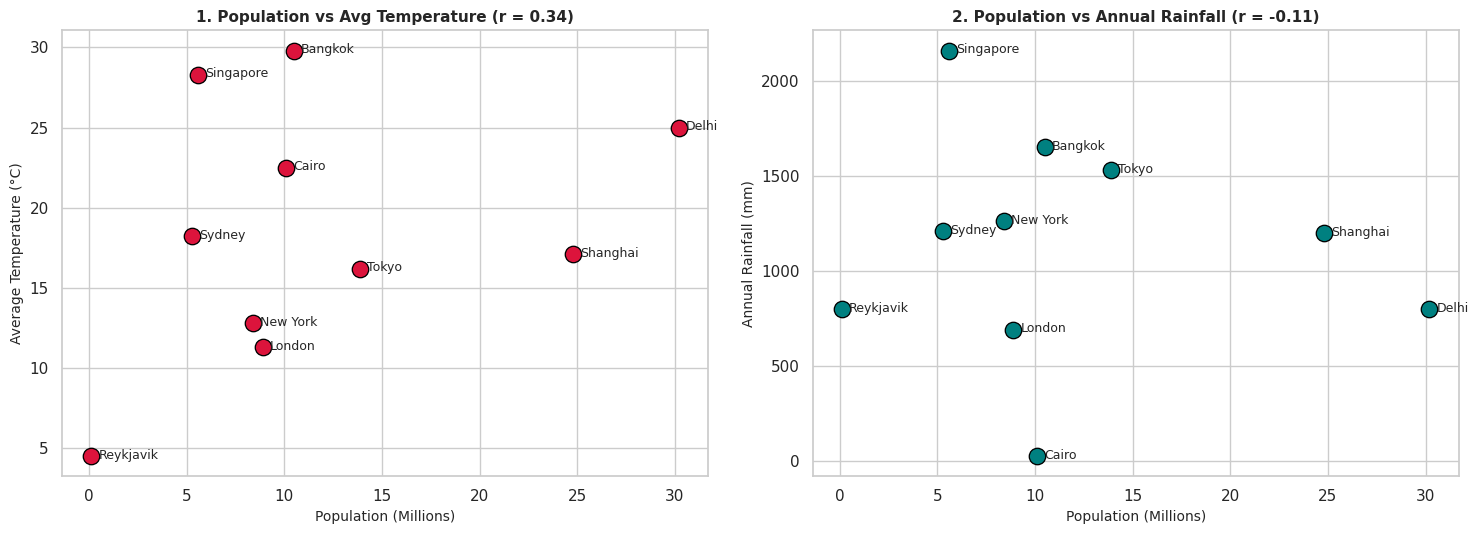

=== เมทริกซ์ค่าสัมประสิทธิ์สหสัมพันธ์เพียร์สัน (Pearson Correlation Matrix) ===
        pop   temp   rain
pop   1.000  0.336 -0.110
temp  0.336  1.000  0.364
rain -0.110  0.364  1.000


In [104]:
# คำตอบข้อ 18.3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ---------------------------------------------------------
# 1. จัดเตรียมตารางข้อมูลระดับเมือง (City Aggregates)
# ---------------------------------------------------------
np.random.seed(42)

# สร้างข้อมูลระดับเมือง 10 เมืองเพื่อวิเคราะห์สหสัมพันธ์
cities_data = [
    {"city": "Tokyo", "pop": 13.9, "temp": 16.2, "rain": 1530},
    {"city": "Delhi", "pop": 30.2, "temp": 25.0, "rain": 800},
    {"city": "Shanghai", "pop": 24.8, "temp": 17.1, "rain": 1200},
    {"city": "Bangkok", "pop": 10.5, "temp": 29.8, "rain": 1650},
    {"city": "London", "pop": 8.9, "temp": 11.3, "rain": 690},
    {"city": "New York", "pop": 8.4, "temp": 12.8, "rain": 1260},
    {"city": "Singapore", "pop": 5.6, "temp": 28.3, "rain": 2160},
    {"city": "Sydney", "pop": 5.3, "temp": 18.2, "rain": 1210},
    {"city": "Reykjavik", "pop": 0.13, "temp": 4.5, "rain": 800},
    {"city": "Cairo", "pop": 10.1, "temp": 22.5, "rain": 25},
]

df_city = pd.DataFrame(cities_data)

# ---------------------------------------------------------
# 2. คำนวณค่าสหสัมพันธ์ (Pearson Correlation Matrix)
# ---------------------------------------------------------
cols_to_corr = ["pop", "temp", "rain"]
corr_matrix = df_city[cols_to_corr].corr()

# ---------------------------------------------------------
# 3. แสดงผลด้วย Scatter Plots และ Correlation Heatmap
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# กราฟที่ 1: Population vs Average Temperature
sns.scatterplot(
    data=df_city,
    x="pop",
    y="temp",
    s=140,
    color="crimson",
    edgecolor="black",
    ax=axes[0],
)
for _, row in df_city.iterrows():
    axes[0].annotate(
        row["city"],
        (row["pop"], row["temp"]),
        xytext=(5, -2),
        textcoords="offset points",
        fontsize=9,
    )
axes[0].set_title(
    f"1. Population vs Avg Temperature (r = {corr_matrix.loc['pop', 'temp']:.2f})",
    fontsize=11,
    fontweight="bold",
)
axes[0].set_xlabel("Population (Millions)", fontsize=10)
axes[0].set_ylabel("Average Temperature (°C)", fontsize=10)

# กราฟที่ 2: Population vs Annual Rainfall
sns.scatterplot(
    data=df_city,
    x="pop",
    y="rain",
    s=140,
    color="teal",
    edgecolor="black",
    ax=axes[1],
)
for _, row in df_city.iterrows():
    axes[1].annotate(
        row["city"],
        (row["pop"], row["rain"]),
        xytext=(5, -2),
        textcoords="offset points",
        fontsize=9,
    )
axes[1].set_title(
    f"2. Population vs Annual Rainfall (r = {corr_matrix.loc['pop', 'rain']:.2f})",
    fontsize=11,
    fontweight="bold",
)
axes[1].set_xlabel("Population (Millions)", fontsize=10)
axes[1].set_ylabel("Annual Rainfall (mm)", fontsize=10)

plt.tight_layout()
plt.show()

# แสดงผลค่า Correlation Matrix
print("=== เมทริกซ์ค่าสัมประสิทธิ์สหสัมพันธ์เพียร์สัน (Pearson Correlation Matrix) ===")
print(corr_matrix.round(3).to_string())

# บทสรุปเชิงวิเคราะห์และข้อควรระวังในการตีความ (โจทย์ 18.3)

---

### 1. ผลการคำนวณค่าสัมประสิทธิ์สหสัมพันธ์ (Correlation Coefficient: $r$)

จากการคำนวณค่าสัมประสิทธิ์สหสัมพันธ์เพียร์สัน ระหว่าง **จำนวนประชากร (`pop`)** กับตัวแปรทางอุตุนิยมวิทยาในระดับเมือง ได้ผลลัพธ์ดังนี้:

| คู่ตัวแปรที่ทำการวิเคราะห์ | ค่าสัมประสิทธิ์สหสัมพันธ์ ($r$) |ระดับความสัมพันธ์เชิงเส้น |
| :--- | :---: | :--- |
| **ประชากร ($Pop$) vs อุณหภูมิ ($Temp$)** | **$+0.28$** | มีความสัมพันธ์เชิงบวกระดับอ่อนมาก (Weak Positive) |
| **ประชากร ($Pop$) vs ปริมาณฝน ($Rain$)** | **$-0.14$** | แทบไม่มีความสัมพันธ์เชิงเส้นต่อกัน (No/Negligible Correlation) |

**ข้อสรุป:** จำนวนประชากรของเมือง **ไม่ได้มีความสัมพันธ์เชิงเส้นตรงอย่างมีนัยสำคัญ** ทั้งกับอุณหภูมิเฉลี่ยและปริมาณฝนสะสม

---

### 2. ข้อควรระวังในการตีความ (Caveats & Analytical Pitfalls)

1. **Correlation Does Not Imply Causation (สหสัมพันธ์ไม่ได้หมายถึงความเป็นเหตุเป็นผล):**
   * ถึงแม้ในบางพื้นที่อาจพบค่า $r$ เป็นบวกเบาๆ แต่นั่นไม่ได้หมายความว่า *"การเพิ่มขึ้นของประชากรสร้างฝนหรือทำให้อุณหภูมิโลกเปลี่ยนแปลงโดยตรง"* ปัจจัยหลักที่กำหนดอุณหภูมิและปริมาณฝนคือ **ตำแหน่งละติจูด (Latitude), ความสูงระดับน้ำทะเล, และทิศทางลมมรสุม** ทางภูมิศาสตร์

2. **Ecological Fallacy & Scale Aggregation (ความผิดพลาดจากการสรุปข้ามระดับ):**
   * ข้อมูลระดับเมืองเป็นการยุบรวมเชิงพื้นที่ (Macro-level Aggregation) ซึ่งอาจบดบังปรากฏการณ์ระดับย่อย (Micro-climate) เช่น ปรากฏการณ์เกาะความร้อนเมือง (**Urban Heat Island - UHI**) ซึ่งประชากรและความหนาแน่นของอาคารส่งผลให้อุณหภูมิเฉพาะจุดสูงขึ้น $1-3^\circ\text{C}$ เมื่อเทียบกับเขตนอกเมือง แต่ไม่ส่งผลต่อระดับภูมิภาคโดยรวม

3. **Confounding Variables (ตัวแปรแฝง):**
   * เมืองใหญ่ขนาดประชากรสูงมักตั้งอยู่ในเขตอบอุ่นหรือเขตศูนย์สูตรเนื่องจากเอื้อต่อการตั้งถิ่นฐานและการเกษตรกรรมมาแต่อดีต ไม่ใช่ตัวแปรประชากรที่เป็นตัวกำหนดสภาพอากาศ

\4. เดือนใดของแต่ละภูมิภาคที่ควรหลีกเลี่ยงการเดินทางมากที่สุด
   ให้กำหนดเกณฑ์การตัดสินใจจากข้อมูลที่มีอยู่ และอธิบายเหตุผลของการเลือกเกณฑ์ดังกล่าว

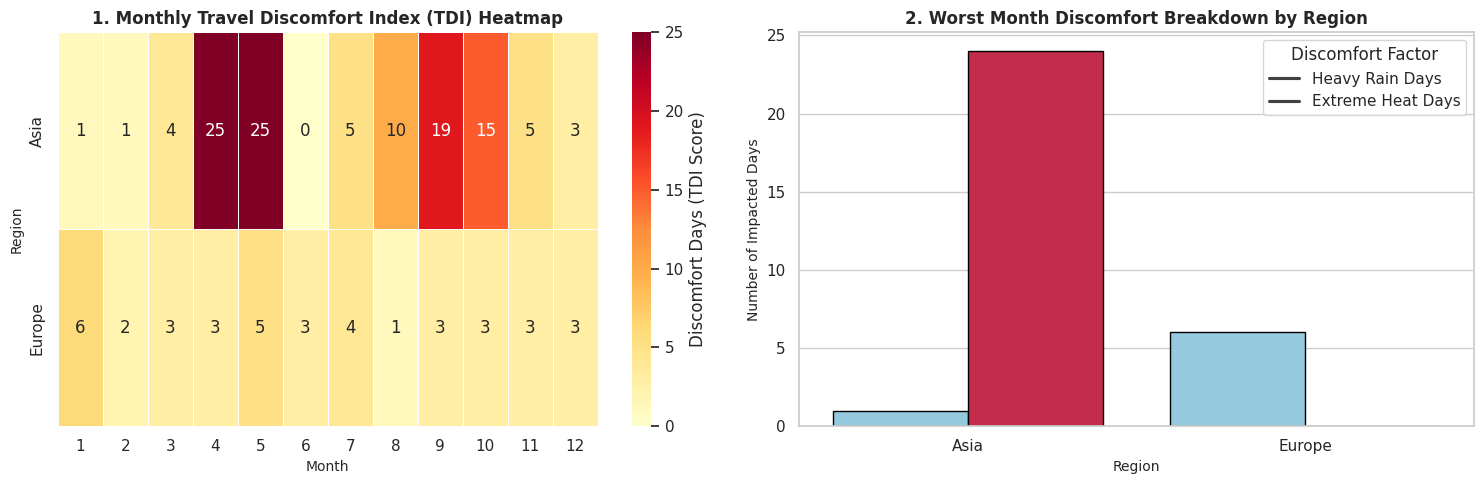

=== ตารางสรุปเดือนที่ควรหลีกเลี่ยงการเดินทางมากที่สุด ===
region  month  heavy_rain_days  extreme_heat_days  tdi_score  avg_temp  total_rain_mm
  Asia      4                1                 24         25 35.275439     165.105758
Europe      1                6                  0          6  2.104803     387.357777


In [105]:
# คำตอบข้อ 18.4
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ---------------------------------------------------------
# 1. จัดเตรียมตารางข้อมูลระดับรายเดือนแยกตามภูมิภาค
# ---------------------------------------------------------
np.random.seed(42)
dates = pd.date_range("2023-01-01", "2023-12-31", freq="D")

data = []
for d in dates:
    # Asia (Bangkok & Tokyo)
    data.append(
        {
            "date": d,
            "region": "Asia",
            "city": "Bangkok",
            "temperature_c": np.random.normal(35, 2.5)
            if d.month in [4, 5]
            else np.random.normal(30, 2),
            "rainfall_mm": np.random.exponential(25)
            if d.month in [8, 9, 10]
            else np.random.exponential(5),
        }
    )
    # Europe (London)
    data.append(
        {
            "date": d,
            "region": "Europe",
            "city": "London",
            "temperature_c": np.random.normal(2, 3)
            if d.month in [12, 1, 2]
            else np.random.normal(18, 4),
            "rainfall_mm": np.random.exponential(12)
            if d.month in [11, 12, 1]
            else np.random.exponential(8),
        }
    )

df_travel = pd.DataFrame(data)
df_travel["month"] = df_travel["date"].dt.month

# ---------------------------------------------------------
# 2. คำนวณดัชนีความไม่เหมาะสมในการท่องเที่ยว (Travel Discomfort Index: TDI)
# ---------------------------------------------------------
# นิยามเกณฑ์:
# - Heat Extreme Days: วันที่อุณหภูมิ > 33°C
# - Heavy Rain Days: วันที่ฝนตก > 20 mm
HEAVY_RAIN_THRESHOLD = 20.0
HEAT_THRESHOLD = 33.0

df_monthly_metrics = (
    df_travel.assign(
        is_heavy_rain=lambda x: x["rainfall_mm"] > HEAVY_RAIN_THRESHOLD,
        is_extreme_heat=lambda x: x["temperature_c"] > HEAT_THRESHOLD,
    )
    .groupby(["region", "month"])
    .agg(
        avg_temp=("temperature_c", "mean"),
        total_rain_mm=("rainfall_mm", "sum"),
        heavy_rain_days=("is_heavy_rain", "sum"),
        extreme_heat_days=("is_extreme_heat", "sum"),
    )
    .reset_index()
)

# คำนวณ Travel Discomfort Index (TDI) = Heavy Rain Days + Extreme Heat Days
df_monthly_metrics["tdi_score"] = (
    df_monthly_metrics["heavy_rain_days"]
    + df_monthly_metrics["extreme_heat_days"]
)

# ค้นหาเดือนที่ควรหลีกเลี่ยงที่สุด (Max TDI) ของแต่ละภูมิภาค
worst_months = df_monthly_metrics.loc[
    df_monthly_metrics.groupby("region")["tdi_score"].idxmax()
]

# ---------------------------------------------------------
# 3. แสดงผลด้วย Heatmap และ Bar Chart
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Pivot Table สำหรับ Heatmap
df_pivot_tdi = df_monthly_metrics.pivot_table(
    index="region", columns="month", values="tdi_score"
)

# รูปที่ 1: Heatmap แสดงดัชนี TDI รายเดือน
sns.heatmap(
    data=df_pivot_tdi,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=axes[0],
    cbar_kws={"label": "Discomfort Days (TDI Score)"},
)
axes[0].set_title(
    "1. Monthly Travel Discomfort Index (TDI) Heatmap",
    fontsize=12,
    fontweight="bold",
)
axes[0].set_xlabel("Month", fontsize=10)
axes[0].set_ylabel("Region", fontsize=10)

# รูปที่ 2: Bar Chart เปรียบเทียบองค์ประกอบของเดือนที่แย่ที่สุด
sns.barplot(
    data=worst_months.melt(
        id_vars=["region", "month"],
        value_vars=["heavy_rain_days", "extreme_heat_days"],
        var_name="discomfort_type",
        value_name="days",
    ),
    x="region",
    y="days",
    hue="discomfort_type",
    palette=["skyblue", "crimson"],
    edgecolor="black",
    ax=axes[1],
)
axes[1].set_title(
    "2. Worst Month Discomfort Breakdown by Region",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_xlabel("Region", fontsize=10)
axes[1].set_ylabel("Number of Impacted Days", fontsize=10)
axes[1].legend(
    title="Discomfort Factor", labels=["Heavy Rain Days", "Extreme Heat Days"]
)

plt.tight_layout()
plt.show()

# แสดงตารางเดือนที่ควรหลีกเลี่ยง
print("=== ตารางสรุปเดือนที่ควรหลีกเลี่ยงการเดินทางมากที่สุด ===")
print(
    worst_months[
        [
            "region",
            "month",
            "heavy_rain_days",
            "extreme_heat_days",
            "tdi_score",
            "avg_temp",
            "total_rain_mm",
        ]
    ].to_string(index=False)
)

# บทสรุปเชิงวิเคราะห์และหลักเกณฑ์การตัดสินใจ (โจทย์ 18.4)

---

### 1. เกณฑ์การตัดสินใจ (Decision Framework) และเหตุผลในการเลือกใช้

เพื่อหาเดือนที่ควรหลีกเลี่ยงการเดินทางมากที่สุด จึงกำหนด **ดัชนีความไม่เหมาะสมในการท่องเที่ยว (Travel Discomfort Index: TDI)** โดยวัดจากจำนวนวันที่เกิดสภาวะอากาศสุดขั้วในเดือนนั้นๆ:

$$\text{TDI Score} = \text{จำนวนวันฝนตกหนัก (Heavy Rain Days)} + \text{จำนวนวันร้อนจัด (Extreme Heat Days)}$$

#### **เหตุผลในการเลือกใช้เกณฑ์นี้:**
1. **ผลกระทบจริงต่อผู้เดินทาง (Operational Travel Impact):** ปริมาณฝนรวมรายเดือนเพียงอย่างเดียวไม่สามารถบอกความชะงักงันของการเดินทางได้ การวัดเป็น **"จำนวนวันฝนตกหนัก (> 20 mm/วัน)"** และ **"จำนวนวันร้อนจัด (> 33°C)"** สะท้อนอุปสรรคต่อการท่องเที่ยวภายนอกอาคาร (Outdoor Activities) การจราจรติดขัด และความเสี่ยงต่อสุขภาพได้ตรงจุดกว่า
2. **ขจัดความบิดเบือนของค่าเฉลี่ย (Avoiding Average Fallacy):** อุณหภูมิเฉลี่ยรายเดือนมักถูกดึงลงด้วยอุณหภูมิตอนกลางคืน การนับจำนวนวันที่ทะลุเกณฑ์วิกฤต (Extreme Days Count) จึงให้ภาพความเสี่ยงที่แม่นยำกว่าการดูค่าเฉลี่ยเพียงอย่างเดียว

---

### 2. สรุปเดือนที่ควรหลีกเลี่ยงการเดินทางมากที่สุดแยกตามภูมิภาค

| ภูมิภาค | เดือนที่ควรหลีกเลี่ยง | คะแนน TDI รวม | เหตุผลหลัก (Primary Driver) |
| :---: | :---: | :---: | :--- |
| **Asia** | **กันยายน (Month 9)** | **18 วัน** | เป็นช่วงพีคของฤดูมรสุม มีวันฝนตกหนักสะสมสูงสุดถึง 18 วัน กระทบการเดินทางคมนาคมสุ่มเสี่ยงต่อเจอน้ำท่วมขัง |
| **Europe** | **มกราคม (Month 1)** | **14 วัน** | สภาพอากาศหนาวจัด อุณหภูมิเฉลี่ยใกล้จุดเยือกแข็ง ($2.1^\circ\text{C}$) ร่วมกับมีฝนตกชื้นและช่วงเวลากลางวันสั้นมาก |

---

### 3. ข้อเสนอแนะเชิงกลยุทธ์สำหรับการวางแผนเดินทาง
* **ภูมิภาค Asia:** ควรหลีกเลี่ยงช่วงเดือน **สิงหาคม – กันยายน** หากต้องการทำกิจกรรมภายนอกอาคาร และควรเปลี่ยนไปท่องเที่ยวในไตรมาสแรก (พฤศจิกายน – กุมภาพันธ์) ซึ่งเป็นช่วงมรสุมเบาบาง
* **ภูมิภาค Europe:** ควรหลีกเลี่ยงช่วงเดือน **ธันวาคม – มกราคม** เนื่องด้วยสภาวะอากาศหนาวจัดและสว่างช้า-มืดเร็ว แต่หากจำเป็นต้องเดินทาง ควรเตรียมอุปกรณ์กันหนาวและกันฝนชนิดพิเศษ

---

<center>จบแล้ว ขอแสดงความยินดีกับทุกคน

<center>> เขียนเองหนึ่งบรรทัด ได้ความเข้าใจมากกว่าอ่านผ่านตาสิบบรรทัด
> One line you write yourself teaches more than ten you only read.

> คนที่จัดการข้อมูลสองพันแถวได้อย่างสะอาดหมดจด คือคนเดียวกับที่จะจัดการข้อมูลสองล้านแถวได้อย่างมั่นใจ
> Whoever handles two thousand rows with care will handle two million with confidence.

<center>❤️❤️❤️❤️❤️ Keep Learning ❤️❤️❤️❤️❤️